# Biotech

**Gator Quant Hacks 2026 · Massive challenge · "Trade the 8-K"**

A small-cap biotech is usually one or two drug programs. A clinical readout re-prices the whole company, and the
8-K (Item 7.01/8.01 with the press release as EX-99.1) is where it is formally disclosed. This notebook asks one
question in two layers: **does the text of a `clinical_trial_results` 8-K, read by a language model (Jev), tell you
anything about the stock after the close of the session in which the 8-K became public — and if so, what does it cost
to hedge the trade with the option chain that same evening?**

## The pre-registered strategy (STRATEGY_PLAN.md, committed before any result was looked at)

| | |
|---|---|
| **Category** | `clinical_trial_results` (headline); `regulatory_decision` added as a combined-category sensitivity row |
| **Universe** | every SIC 2834/2836 filer by CIK (`biotech_universe.csv`, 1,499 names incl. acquired, delisted and bankrupt, so no survivorship bias) |
| **Classifier** | Jev (`jev-1.13.0`, pinned) reads the masked press release: is it a *new human readout*, how positive on a 0–4 scale, primary endpoint met, safety signal, what the company does next, phase, lead asset, big-pharma partner, announcement date |
| **Signal** | `sentiment = (score − 2)/2`; `expected = BETA × sentiment × implied move` (BETA fitted in-sample, then frozen); trade only when the day-0 move `r0` is short of `0.5 × expected` (**under-reaction**) |
| **Strategies** | positive readout → **long stock + protective put** (library #3); negative readout → **short stock + long call** (#1 as the hedge); collar (#4) as a financed sensitivity. Hedge 10% OTM, 1-month expiry (biotech chains rarely have liquid 3–6-month strikes) |
| **Entry / exit** | close of `t_0`, the first session at whose close the 8-K was on EDGAR (acceptance time from the submission header); exit at a pre-registered time stop `H*` chosen in-sample, or earlier if the gap closes or the filer files again |
| **Two layers** | *Signal layer*: the bare stock, every gated event (larger n, tests the information thesis). *Trade layer*: stock + hedge, events with a priced option (tests the tradeable strategy) |
| **Controls** | placebo (same names, random non-event days, random direction) · sign-shuffle · momentum baseline (follow `r0`, no Jev) · stale readouts (data previously announced) · out-of-sample 2026 · the judges' sealed window |

**What the data say** (details in sections 9–14 and the write-up): Jev reads the readout well — its sentiment lines up
with the day-0 move monotonically and strongly — but by the close of the 8-K session the move is done. The
pre-registered under-reaction rule picks the events where the market *disagreed* with the text, and the market was right:
the rule shows no edge over placebo at any horizon, in-sample or out-of-sample. The option side of the thesis does hold:
implied volatility collapses once the result is out, so the protection is far cheaper after the event than before, and it
cuts the worst decile of the long book roughly in half. A clear null with a working hedge is what we report.

## How to run

1. `./setup.sh`, put `MASSIVE_API_KEY` (and, to label filings not already in `jev_cache/`, `TYPESAFE_API_KEY`) in `.env`.
2. Run all cells. A cold run is roughly 25,000 cached API calls (EDGAR text, stock and option bars, quotes), about 35
   minutes; a warm run takes a few minutes. Every Massive response is cached in `.massive_cache/`, every Jev answer in
   `jev_cache/` (committed, so in-sample and out-of-sample labels are reproducible without a TypeSafe key).
3. **Judges:** set `RUN_HOLDOUT = True` and `HOLDOUT_START/END` in section 2 (and the `TYPESAFE_API_KEY` you were
   given) and run all cells; section 16 runs the entire chain on your window with `run_study(start, end)`.

## Data

| Dataset | Endpoint | Used for |
|---|---|---|
| Filings & Disclosures | `/stocks/filings/8-K/vX/disclosures` | the events (one per accession), the filer's later 8-Ks (information exit) |
| EDGAR submission file | `filing_url` on sec.gov | acceptance time, items, the press release (EX-99.1) that Jev reads |
| Stock aggregates | `/v2/aggs/ticker/{T}/range/1/day`, `/1/minute` | real spot (adjusted for returns, unadjusted next to the strikes), day-0 reaction, minute path around acceptance |
| Reference | `/v3/reference/tickers/{T}?date=` | point-in-time market cap (size buckets) |
| Options contracts / aggregates / quotes | `/v3/reference/options/contracts`, `/v2/aggs/ticker/O:…`, `/v3/quotes/O:…` | the chain as of `t_pre` and `t_0`, leg marks, closing NBBO for the implied move, hedge cost, spreads and the liquidity gate |
| Jev (TypeSafe) | `system_one` | typed judgments about each filing |

## Vocabulary used below

| Term | Meaning here |
|---|---|
| `t_news` | the session of the announcement date Jev read in the filing (the press release usually precedes the 8-K by 0–1 sessions) |
| `t_pre` | the session before `t_news`: the last close that could not know the result. The implied move and `S_pre` are read here |
| `t_0` | the first session at whose **close** the 8-K was public. Entry is this close (`ENTRY = "post"`) |
| `r0` | `S_0 / S_pre − 1`, the move already realized at entry |
| **IM** | implied move: the 1-month ATM straddle on `t_pre` ÷ `S_pre`, read as "the move the market priced for the event" (not rescaled to one day, since a straddle a few weeks before a known readout is dominated by that readout) |
| `expected` | `BETA × sentiment × IM`, the move the readout "deserves"; `gap = expected − r0` |
| **signal layer** | bare stock, every gated event with stock bars (micro-caps without options included) |
| **trade layer** | stock + option hedge, events whose hedge leg is listed and quoted on `t_0` |
| `hedged` / `unhedged` | book P&L per $1 of stock at entry: long stock + put / short stock + call, versus the bare directional stock |
| **placebo** | the same tickers on random non-event sessions, each given a random direction with the book's long/short mix |

## What you submit

1. **This notebook, or one built on it**, that runs from a clean kernel with only an API key. Your
   pipeline must take a start date and an end date as inputs; judges will call it on a window
   you have not seen.
2. **A write-up of at most two pages** with five parts: the hypothesis (which categories, which
   strategy, why the market should misprice it), the method, the result with uncertainty at
   every fixed horizon in-sample and out-of-sample, what would make it break, and how you would
   trade it.
3. **A parameter-sensitivity check**: the result across the neighbouring choices you could have
   made (expiry bucket, OTM distance, entry session, horizon, category definition), using the
   organizers' overfitting library or your own grid.

| Criterion | Weight | Full marks look like |
|---|---|---|
| Hypothesis and novelty | 30 | A non-obvious, economically motivated category-to-strategy link. "Guidance up, buy a call" is the floor. |
| Analytical rigor | 30 | All fixed horizons reported, a placebo or baseline, an out-of-sample window, uncertainty shown, sensitivity examined. |
| Sealed-window replication | 20 | The finding holds on the judges' window, or you predicted its fragility and were right. |
| Trade realism | 10 | Entry timing that respects the filing lag, costs and liquidity from the data, stated capacity. |
| Communication | 10 | A write-up a portfolio manager could act on; a notebook that runs. |

### Where this submission addresses each criterion

| Criterion | Where it is addressed |
|---|---|
| Hypothesis and novelty | sections 0, 11, 12: a text-read readout as a *directional* signal, hedged with the option that the event itself just made cheap; the concentration mechanism tested through disclosure behaviour and the partner's reaction |
| Analytical rigor | 9 (placebo, bootstrap CIs, sign-shuffle, momentum baseline, stale-readout arm), 6b (classifier validation), 13 (out-of-sample), 14 (sensitivity) |
| Sealed-window replication | 16 (`run_study`), with the prediction written down before the window is run |
| Trade realism | 4 (acceptance time), 7 (real quotes, liquidity gate), 15 (cost waterfall from quotes, capacity, borrow grid, short-side risks) |
| Communication | this notebook and `writeup.pdf`; figures saved to `figures/` |

## Requirements and setup

Python 3.10+, `pandas`, `numpy`, `requests`, `matplotlib`, `typesafe-sdk` (see `requirements.txt`). `./setup.sh` (or
`setup.ps1`) creates `.venv`, installs everything, registers the kernel **Python (Gator Quant Hacks .venv)** and creates
`.env` from `.env.example`. Put `MASSIVE_API_KEY=...` in `.env` (and `TYPESAFE_API_KEY=...` for Jev calls that are not
cached). Keys are read from the environment first, then `.env`; nothing is pasted into a cell.

## 1 · API client

Plain `requests` against the REST API. `api_get` caches every response on disk by URL and retries rate limits and
server errors; `api_get_all` follows `next_url` pagination; `parallel_map` runs bulk fetches (stock bars, chains,
quotes, EDGAR) on a small thread pool with one session per thread. The cache never expires: delete `.massive_cache/`
to refetch recent data.

In [1]:
import os, json, time, hashlib, re, html, threading
from math import log, sqrt, exp, erf
from concurrent.futures import ThreadPoolExecutor
from dataclasses import dataclass, field
from pathlib import Path
from getpass import getpass

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from pandas.tseries.holiday import (AbstractHolidayCalendar, Holiday, nearest_workday, USMartinLutherKingJr,
                                    USPresidentsDay, GoodFriday, USMemorialDay, USLaborDay, USThanksgivingDay)
from pandas.tseries.offsets import CustomBusinessDay

BASE_URL = "https://api.massive.com"


def load_api_key(name: str = "MASSIVE_API_KEY") -> str:
    """Environment first, then a `.env` file beside the notebook, then a prompt. Never paste a key into a cell."""
    key = (os.environ.get(name) or "").strip()
    env_file = Path(".env")
    if not key and env_file.exists():
        for line in env_file.read_text().splitlines():
            if line.strip().startswith(f"{name}="):
                key = line.split("=", 1)[1].strip().strip('"').strip("'")
    if not key:
        key = getpass(f"{name} (https://massive.com/dashboard/keys): ").strip()
    return key


API_KEY = load_api_key()
_LOCAL = threading.local()          # one requests.Session per worker thread


def _session() -> requests.Session:
    s = getattr(_LOCAL, "session", None)
    if s is None:
        s = requests.Session()
        s.headers["Authorization"] = f"Bearer {API_KEY}"
        _LOCAL.session = s
    return s


CACHE_DIR = Path(".massive_cache")
CACHE_DIR.mkdir(exist_ok=True)
API_WORKERS = 6                     # thread-pool width for bulk fetches (bars, chains, quotes)


def api_get(path_or_url: str, params: dict | None = None) -> dict:
    """GET one page from the Massive REST API. Cached on disk by the full URL, so reruns are free. Thread-safe."""
    url = path_or_url if path_or_url.startswith("http") else BASE_URL + path_or_url
    full_url = requests.Request("GET", url, params=params).prepare().url
    cache_file = CACHE_DIR / (hashlib.sha1(full_url.encode()).hexdigest() + ".json")
    if cache_file.exists():
        try:
            return json.loads(cache_file.read_text())
        except json.JSONDecodeError:          # a half-written file from an interrupted run
            cache_file.unlink()
    resp = None
    for attempt in range(10):
        resp = _session().get(full_url, timeout=60)
        if resp.status_code in (429, 500, 502, 503, 504):   # rate-limited or a transient server error
            retry_after = resp.headers.get("Retry-After", "")
            time.sleep(float(retry_after) if retry_after.isdigit() else min(2 ** attempt, 20))
            continue
        break
    resp.raise_for_status()
    payload = resp.json()
    tmp = cache_file.with_suffix(f".{threading.get_ident()}.tmp")
    tmp.write_text(json.dumps(payload))
    tmp.replace(cache_file)
    return payload


def api_get_all(path: str, params: dict | None = None, max_pages: int = 500) -> list[dict]:
    """Follow `next_url` pagination and return every result row."""
    payload = api_get(path, params)
    rows = list(payload.get("results") or [])
    pages = 1
    while payload.get("next_url") and pages < max_pages:
        payload = api_get(payload["next_url"])
        rows.extend(payload.get("results") or [])
        pages += 1
    return rows


def parallel_map(fn, items, workers: int = API_WORKERS, label: str = "", every: int = 100) -> list:
    """Run `fn` over `items` on a thread pool, preserving order, with a progress line every `every` items."""
    out, t0 = [None] * len(items), time.time()
    with ThreadPoolExecutor(max_workers=workers) as ex:
        for n, (i, r) in enumerate(zip(range(len(items)), ex.map(fn, items)), 1):
            out[i] = r
            if label and n % every == 0:
                print(f"  {label}: {n}/{len(items)}, {time.time() - t0:.0f}s", flush=True)
    return out


print(f"API key loaded (ends {API_KEY[-4:]}); cache at {CACHE_DIR.resolve()}")

API key loaded (ends jNOD); cache at /Users/nxli/Competitions/gqh-8k/.massive_cache


### 1b · Jev client (TypeSafe)

Jev reads each 8-K and returns typed judgments (Noul = probability of yes, Score = position on ordered levels, Choice =
one of a set). `jev_ask` sends one state with all its questions in a single request and caches the answer on disk by a
hash of (model, state, questions), so a rerun costs nothing. The cache lives in `jev_cache/` and **is committed**, so
in-sample and out-of-sample labels are reproducible without re-calling Jev. The sealed window calls Jev live, so
`TYPESAFE_API_KEY` must be set for that run. The model is pinned to `jev-1.13.0` (not `jev-latest`) so labels cannot
shift underneath the analysis; changing a threshold never re-calls Jev because thresholds are applied in code to the
saved answers.

In [2]:
from typesafe_sdk import TypeSafeClient, Noul, Score, Choice, RetryPolicy

JEV_MODEL = "jev-1.13.0"                 # pinned: an alias can move and silently change the labels
JEV_CACHE_DIR = Path("jev_cache")
JEV_CACHE_DIR.mkdir(exist_ok=True)
JEV_WORKERS = 4


def _optional_key(name: str) -> str | None:
    """Environment, then `.env`. No prompt: a missing key means cache-only mode, not an error."""
    key = (os.environ.get(name) or "").strip()
    if not key and Path(".env").exists():
        for line in Path(".env").read_text().splitlines():
            if line.strip().startswith(f"{name}="):
                key = line.split("=", 1)[1].strip().strip('"').strip("'")
    return key if key and key != "your-key-here" else None


TYPESAFE_API_KEY = _optional_key("TYPESAFE_API_KEY")
JEV = TypeSafeClient(api_key=TYPESAFE_API_KEY, model=JEV_MODEL, retry=RetryPolicy(max_retries=6), timeout=120) if TYPESAFE_API_KEY else None


def _question_payload(q) -> dict:
    return q.model_dump(mode="json") if hasattr(q, "model_dump") else q


def jev_ask(state, questions: dict) -> dict:
    """Ask Jev every question about one state in one request. Returns {question_id: answer dict}.

    Noul answers carry `noul` (P(yes)); Score answers carry `score`, `confidence`, `probabilities`;
    Choice answers carry `choice`, `confidence`, `probabilities`. Cached on disk; raises if the
    answer is not cached and no TYPESAFE_API_KEY is set.
    """
    qs = {k: _question_payload(v) for k, v in questions.items()}
    blob = json.dumps({"model": JEV_MODEL, "state": state, "questions": qs}, sort_keys=True)
    cache_file = JEV_CACHE_DIR / (hashlib.sha1(blob.encode()).hexdigest() + ".json")
    if cache_file.exists():
        return json.loads(cache_file.read_text())
    if JEV is None:
        raise RuntimeError("Jev answer not cached and TYPESAFE_API_KEY is not set. Judges: put the TYPESAFE_API_KEY you were "
                           "given in .env (or the environment) and restart the kernel.")
    resp = JEV.system_one(state=state, questions=questions)
    answers = {k: v.model_dump(mode="json") for k, v in resp.answers.items()}
    tmp = cache_file.with_suffix(f".{threading.get_ident()}.tmp")
    tmp.write_text(json.dumps(answers))
    tmp.replace(cache_file)
    return answers


print(f"Jev: {'key loaded (ends ' + TYPESAFE_API_KEY[-4:] + ')' if TYPESAFE_API_KEY else 'no key, cache-only mode'}; "
      f"model {JEV_MODEL}; {len(list(JEV_CACHE_DIR.glob('*.json')))} cached answers in {JEV_CACHE_DIR}/")

_t = jev_ask({"filing_excerpt": "The Phase 3 trial met its primary endpoint with a statistically significant reduction in seizures (p<0.001)."},
             {"met_primary": Noul(instructions="Does the excerpt report that a clinical trial met its primary endpoint?")})
print(f"Smoke test, P(met primary endpoint) = {_t['met_primary']['noul']:.2f}")

Jev: key loaded (ends 4796); model jev-1.13.0; 2098 cached answers in jev_cache/
Smoke test, P(met primary endpoint) = 0.99


## 2 · Configuration

Everything a team is allowed to change lives in this cell. The horizons are **fixed for every team**.

- **`EVENT_TAGS`** is the headline category; `SENSITIVITY_TAGS` adds `regulatory_decision` for the combined-category row.
- **Three windows.** In-sample 2024–2025 is where BETA, the implied-move proxy and `H*` are fitted. Out-of-sample is
  2026-01..08, run in section 13 with everything frozen; horizons that have not resolved for the latest events are absent.
  The sealed window is the judges' (`RUN_HOLDOUT`, section 16).
- **Universe** is `biotech_universe.csv` (CIK-matched); **size buckets** come from point-in-time market cap on `t_pre`.
- **Jev gates and the rule**: `READOUT_GATE`, `NEW_GATE`, `SENT_THRESHOLD`, `SAFETY_VETO`, `ALREADY_MOVED`.
- **`BASELINE_BUCKET = "1m"`**: biotech chains rarely have liquid 3–6-month strikes; `2m` and `3-6m` are sensitivity rows.
- **`OTM_PCT = 0.10`** for the hedge leg (put below spot for the long book, call above spot for the short book); `OTM_GRID` is the neighbourhood.
- **`ENTRY = "post"`** (the tradeable rule). `"pre"` is computed as a pricing diagnostic only.
- **Borrow**: no borrow data on this key, so a grid (`BORROW_GRID`) with a 25% headline; small-cap biotech after bad news is often hard to borrow.
- **Liquidity gate** for the trade layer (spread, hedge-leg volume, stock dollar volume) as pre-registered; section 15 also shows relaxed tiers.
- **`SEC_USER_AGENT`** is the contact the SEC requires; **`MASK_FOR_JEV`** hides company, ticker and drug codes from Jev.

In [3]:
# ---- The 8-K events. Headline tag plus the combined-category sensitivity tag. -----------------------
EVENT_TAGS = ["clinical_trial_results"]          # headline category
SENSITIVITY_TAGS = ["clinical_trial_results", "regulatory_decision"]   # combined-category row in the sensitivity grid

# ---- Windows. In-sample is what we research on; out-of-sample is 2026 to date; the sealed window is the judges'.
STUDY_START, STUDY_END = "2024-01-01", "2025-12-31"      # in-sample
OOS_START, OOS_END = "2026-01-01", "2026-08-31"          # out-of-sample, run in this notebook
HOLDOUT_START, HOLDOUT_END = "2023-06-01", "2023-08-31"  # sealed: judges change these and flip RUN_HOLDOUT

# ---- Universe: every SIC 2834/2836 filer by CIK, including acquired, delisted and bankrupt names. --------
UNIVERSE_CSV = "biotech_universe.csv"
SIZE_BUCKETS = {"micro": (0, 300e6), "small": (300e6, 2e9), "mid+": (2e9, np.inf)}   # point-in-time market cap on t_pre

# ---- Jev gates and the trade rule -------------------------------------------------------------------
READOUT_GATE = 0.70         # P(filing discloses new human efficacy/safety results) at least this
NEW_GATE = 0.60             # P(first public disclosure of these results) at least this; stale ones are a placebo arm
SENT_THRESHOLD = 0.50       # |sentiment| = |(outcome score - 2) / 2| at least this to take a direction
SAFETY_VETO = 0.50          # P(serious safety signal) at or above this vetoes a long
ALREADY_MOVED = 0.50        # trade only if the day-0 move is less than this fraction of the move the readout "deserves"; None = off
MIN_IM, MAX_IM = 0.05, 1.50 # implied-move sanity bounds for the signal; outside -> use the size-bucket median

# ---- Expiry buckets: name -> (min, max, target) calendar days to expiry from the pre-event session.
EXPIRY_BUCKETS = {
    "1m":   (21, 45, 30),
    "2m":   (46, 80, 60),
    "3-6m": (90, 180, 120),
}
BASELINE_BUCKET = "1m"      # biotech chains rarely have liquid 3-6 month strikes; 2m and 3-6m are sensitivity rows

# ---- Fixed horizons (sessions after the filing session). Fixed for every team. Do not change. -----
HORIZONS = [1, 2, 3, 5, 10, 21, 42, 63]

# ---- Strategy parameters -----------------------------------------------------------------------
OTM_PCT = 0.10              # hedge leg: put 10% below spot (long book), call 10% above spot (short book)
OTM_GRID = [0.05, 0.10, 0.20]   # neighbours for the parameter-sensitivity check; OTM_PCT must be one of them
ENTRY = "post"              # "post": close of t_0 (the tradeable rule). "pre": close of t_pre (hypothetical pricing diagnostic)
RISK_FREE = 0.04            # flat carry rate: put-call-parity cross-check and Black-Scholes IV
BORROW_GRID = [0.05, 0.25, 0.75]   # annualised stock-borrow fee scenarios for the short book (no borrow data on this key)
BORROW_FEE = 0.25           # headline borrow assumption

# ---- Liquidity gate (trade layer) ---------------------------------------------------------------
MAX_REL_SPREAD = 0.25       # hedge-leg quoted spread on t_0 at most this fraction of mid ...
MAX_ABS_SPREAD = 0.10       # ... or at most this many dollars
MIN_HEDGE_VOLUME = 10       # contracts traded in the hedge leg on t_0
MIN_STOCK_DOLLAR_VOL = 1e6  # stock dollar volume on t_0

# ---- Mechanics -----------------------------------------------------------------------------------
STRIKE_WINDOW = 0.35        # keep strikes within +/-35% of spot (small caps have coarse strike grids)
MAX_STALE_SESSIONS = 3      # a leg's last trade may be at most this many sessions old to count as a mark
MAX_EVENTS = None           # e.g. 40 for a smoke test; None = all events
PRESS_RELEASE_CHARS = 12000 # how much of the (masked) EX-99.1 goes to Jev

# ---- Stretch toggles -----------------------------------------------------------------------------
RUN_PLACEBO = True          # the same measurement on ordinary days for the same names
N_PLACEBO = 150
PLACEBO_GAP_DAYS = 30
SEC_USER_AGENT = "GatorQuantHacks nathan.nxli@gmail.com"   # the SEC requires a contact in the User-Agent
SEC_MAX_RPS = 8             # sec.gov asks for at most 10 requests per second
RUN_HOLDOUT = False         # judges flip this
MASK_FOR_JEV = True         # mask company, ticker and drug codes before sending text to Jev (look-ahead hygiene)
N_MASK_ABLATION = 100       # events re-labelled unmasked, to measure the label shift

assert OTM_PCT in OTM_GRID and BASELINE_BUCKET in EXPIRY_BUCKETS and ENTRY in ("pre", "post")

# ---- Catch impossible dates (e.g. "2024-06-31") here rather than deep in the pipeline -----------
for _name in ("STUDY_START", "STUDY_END", "OOS_START", "OOS_END", "HOLDOUT_START", "HOLDOUT_END"):
    try:
        pd.Timestamp(globals()[_name])
    except ValueError:
        raise ValueError(f"{_name} = {globals()[_name]!r} is not a real date (check the day of the month)") from None
assert STUDY_START < STUDY_END and OOS_START < OOS_END and HOLDOUT_START < HOLDOUT_END, "each window's start must be before its end"

### The disclosure taxonomy

One request returns the full three-level taxonomy (119 tertiary tags). The cell shows the two tags this notebook uses.

In [4]:
taxonomy = pd.DataFrame(api_get_all("/stocks/taxonomies/vX/disclosures", {"limit": 1000}))
print(f"{len(taxonomy)} tertiary tags, {taxonomy.secondary_category.nunique()} secondary, "
      f"{taxonomy.primary_category.nunique()} primary")
with pd.option_context("display.max_colwidth", 120):
    display(taxonomy[taxonomy.tertiary_category.isin(SENSITIVITY_TAGS)]
            [["primary_category", "secondary_category", "tertiary_category", "description"]].reset_index(drop=True))

119 tertiary tags, 29 secondary, 8 primary


,primary_category,secondary_category,tertiary_category,description
0,operations_and_strategy,business_developments,clinical_trial_results,"Clinical trial data for pharma, biotech, or medical devices including efficacy and safety findings."
1,operations_and_strategy,business_developments,regulatory_decision,"Regulatory approvals, rejections, complete response letters, or information requests from FDA, EPA, or other agencies."


## 3 · Trading calendar

Every horizon is counted in sessions. The calendar is weekdays minus NYSE full-day closures (Good Friday closed,
Columbus and Veterans Day open, the special closure for President Carter on 9 January 2025). It is cross-checked against
the days stocks actually traded in section 5. `LAST_SESSION` is the last completed session, so unresolved horizons are
absent rather than guessed.

In [5]:
class NYSEHolidays(AbstractHolidayCalendar):
    """NYSE full-day closures. Differs from the federal calendar: Good Friday closed, Columbus and
    Veterans Day open, no observance when New Year's Day falls on a Saturday."""
    rules = [
        Holiday("New Year's Day", month=1, day=1,
                observance=lambda d: d + pd.Timedelta(days=1) if d.weekday() == 6 else d),
        USMartinLutherKingJr, USPresidentsDay, GoodFriday, USMemorialDay,
        Holiday("Juneteenth", month=6, day=19, start_date="2022-01-01", observance=nearest_workday),
        Holiday("Independence Day", month=7, day=4, observance=nearest_workday),
        USLaborDay, USThanksgivingDay,
        Holiday("Christmas Day", month=12, day=25, observance=nearest_workday),
        Holiday("National day of mourning, President Carter", year=2025, month=1, day=9),
    ]


def trading_sessions(start, end) -> pd.DatetimeIndex:
    holidays = NYSEHolidays().holidays(pd.Timestamp(start) - pd.Timedelta(days=7), pd.Timestamp(end) + pd.Timedelta(days=7))
    return pd.bdate_range(start, end, freq=CustomBusinessDay(holidays=holidays))


CAL = trading_sessions("2021-06-01", "2027-12-31")
TODAY = pd.Timestamp.today().normalize()
LAST_SESSION = CAL[CAL.searchsorted(TODAY, side="right") - 1]
if LAST_SESSION == TODAY:                       # today's close is not in the daily bars until the session ends
    LAST_SESSION = CAL[CAL.get_loc(TODAY) - 1]


def session_on_or_after(day) -> pd.Timestamp:
    return CAL[CAL.searchsorted(pd.Timestamp(day), side="left")]


def session_before(day) -> pd.Timestamp:
    return CAL[CAL.searchsorted(pd.Timestamp(day), side="left") - 1]


def session_after(day) -> pd.Timestamp:
    return CAL[CAL.searchsorted(pd.Timestamp(day), side="right")]


def sessions_between(a, b) -> int:
    """Number of sessions strictly after `a` up to and including `b`."""
    return int(CAL.searchsorted(pd.Timestamp(b), side="right") - CAL.searchsorted(pd.Timestamp(a), side="right"))


def shift_session(day, n: int) -> pd.Timestamp:
    return CAL[CAL.get_loc(pd.Timestamp(day)) + n]


print(f"{len(CAL)} sessions in the calendar; last completed session {LAST_SESSION.date()}. "
      f"Sessions per year: " + ", ".join(f"{y}: {((CAL.year == y)).sum()}" for y in range(2022, 2027)))

1655 sessions in the calendar; last completed session 2026-10-02. Sessions per year: 2022: 251, 2023: 250, 2024: 252, 2025: 250, 2026: 251


### Helpers: bootstrap intervals and chart style

`bootstrap_ci` is the 95% percentile interval of the mean (2,000 resamples) used by every scoreboard. The plotting
helpers keep every figure in one style and save them to `figures/` for the write-up.

In [6]:
def bootstrap_ci(x, n_boot: int = 2000, seed: int = 0) -> tuple[float, float]:
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < 5:
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    means = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    return tuple(np.percentile(means, [2.5, 97.5]).tolist())



INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
SERIES = {"events": "#2a78d6", "placebo": "#eb6834", "oos": "#1baf7a", "in-sample": "#2a78d6", "long": "#2a78d6", "short": "#b5342c",
          "combined": "#0b0b0b", "positive": "#1baf7a", "negative": "#b5342c", "mixed": "#898781", "sealed": "#8a4fd6", "stale": "#c9a227"}
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)


def style(ax, title: str, xlabel: str = "", ylabel: str = ""):
    ax.figure.set_facecolor(SURFACE)
    ax.set_facecolor(SURFACE)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(AXIS)
        ax.spines[s].set_linewidth(0.8)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=INK2, labelsize=9, length=0)
    ax.set_title(title, loc="left", color=INK, fontsize=11, fontweight="bold", pad=10)
    ax.set_xlabel(xlabel, color=INK2, fontsize=9)
    ax.set_ylabel(ylabel, color=INK2, fontsize=9)


def finish(fig, name: str | None = None):
    plt.tight_layout()
    if name:
        fig.savefig(FIG_DIR / f"{name}.png", dpi=160, facecolor=SURFACE)
    plt.show()

## 4 · Events: one filing, one event

The disclosure feed returns one row per tagged *passage*; a filing with three result paragraphs appears three times. We
collapse to **one event per accession number** (one filing), concatenate the passages into `supporting_text`, match the
filer to the universe on **CIK** (zero-padded, from the CSV read as strings) and take the ticker from the disclosure
(falling back to the universe's ticker on record).

Then, for every filing, one request to sec.gov fetches the full submission file, which gives:

- `<ACCEPTANCE-DATETIME>`: the minute the 8-K became public. **`t_0`** is the first session at whose close it was
  public (accepted before 16:00 ET → that day; after → the next session). The starter did this *after* pricing; here it
  happens first, so nothing downstream looks ahead.
- the `ITEM INFORMATION` lines (7.01 Reg FD / 8.01 Other Events / 9.01 Exhibits, typically),
- the press release (`EX-99.1`, else the longest EX-99, else the 8-K body), HTML stripped, which is what Jev reads
  (`supporting_text` is a few hundred characters; the press release is ~11,000).

**Look-ahead hygiene.** Jev may know how famous 2024–25 readouts played out. Before anything is sent, the company's
current and former names, its ticker and drug code names (`XX-123` patterns) are replaced by `COMPANY`, `TICKER`,
`DRUG_A`, … Section 6b measures how much the labels change when the mask is removed.

Point-in-time **market cap** on `t_pre` gives the size bucket (`micro` < $300M, `small` $300M–2B, `mid+` ≥ $2B).

In [7]:
# ---- Universe: SIC 2834/2836 filers by CIK --------------------------------------------------------
UNIVERSE = pd.read_csv(UNIVERSE_CSV, dtype=str).fillna("")
UNIVERSE["cik"] = UNIVERSE["cik"].str.zfill(10)
UNIVERSE_CIKS = frozenset(UNIVERSE["cik"])
CIK_TICKER = {r.cik: r.tickers.split("|")[0].strip() for r in UNIVERSE.itertuples() if r.tickers.strip()}


def _former_names(s: str) -> list[str]:
    return [re.sub(r"\s*\(until [^)]*\)", "", part).strip() for part in s.split(";") if part.strip()]


CIK_NAMES = {r.cik: [r.name] + _former_names(r.former_names) for r in UNIVERSE.itertuples()}
print(f"Universe: {len(UNIVERSE):,} filers by CIK ({UNIVERSE.status.value_counts().to_dict()}); "
      f"{len(CIK_TICKER):,} have a ticker on record")


def normalize_ticker(t) -> str | None:
    """Filings write share classes as BRK/B or BRK.B; Massive's stock and option feeds use BRK.B."""
    if not isinstance(t, str) or not t.strip():
        return None
    return t.strip().upper().replace("/", ".")


def fetch_disclosures(tag: str, start: str, end: str) -> pd.DataFrame:
    rows = api_get_all("/stocks/filings/8-K/vX/disclosures", {
        "tertiary_category": tag, "filing_date.gte": start, "filing_date.lte": end,
        "limit": 1000, "sort": "filing_date.asc",
    })
    df = pd.DataFrame(rows)
    if not df.empty:
        df["filing_date"] = pd.to_datetime(df["filing_date"])
    return df


def _first_ticker(lists) -> str | None:
    for l in lists:
        if isinstance(l, list):
            for t in l:
                if normalize_ticker(t):
                    return normalize_ticker(t)
    return None


def build_events(tags: list[str], start: str, end: str, ciks=UNIVERSE_CIKS) -> pd.DataFrame:
    """One row per **accession** (one filing) from a filer in the CIK universe, with every tagged
    passage concatenated into `supporting_text`. Dates (`t_0`, `t_pre`) are set by `enrich_events`."""
    raw = pd.concat([fetch_disclosures(t, start, end) for t in tags], ignore_index=True)
    print(f"{len(raw):,} tagged passages ({', '.join(tags)}) across all filers, {start}..{end}; "
          f"{raw.accession_number.nunique():,} filings")
    raw["cik"] = raw["cik"].astype(str).str.zfill(10)
    raw = raw[raw["cik"].isin(ciks)]
    ev = (raw.sort_values(["filing_date", "accession_number"])
             .groupby("accession_number", as_index=False)
             .agg(cik=("cik", "first"), filing_date=("filing_date", "first"), filing_url=("filing_url", "first"),
                  tickers=("tickers", list), tags=("tertiary_category", lambda s: "|".join(sorted(set(s)))),
                  supporting_text=("supporting_text", lambda s: " ".join(dict.fromkeys(x.strip() for x in s if isinstance(x, str))))))
    ev["ticker"] = [_first_ticker(l) or CIK_TICKER.get(c) for l, c in zip(ev["tickers"], ev["cik"])]
    n_no_ticker = ev["ticker"].isna().sum()
    ev = ev.dropna(subset=["ticker"]).drop(columns="tickers").sort_values(["filing_date", "cik"]).reset_index(drop=True)
    print(f"{len(ev):,} filings from {ev.cik.nunique():,} universe filers ({n_no_ticker} dropped: no ticker on record)")
    return ev


# ---- EDGAR: the full submission file gives the acceptance time, the items and the press release ----
_SEC_LOCK, _SEC_LAST = threading.Lock(), [0.0]


def sec_get(url: str) -> str:
    """Polite GET from sec.gov: a declared contact and at most SEC_MAX_RPS requests per second across threads."""
    for attempt in range(6):
        with _SEC_LOCK:
            wait = _SEC_LAST[0] + 1.0 / SEC_MAX_RPS - time.time()
            if wait > 0:
                time.sleep(wait)
            _SEC_LAST[0] = time.time()
        resp = requests.get(url, headers={"User-Agent": SEC_USER_AGENT, "Accept-Encoding": "gzip, deflate"}, timeout=60)
        if resp.status_code in (403, 429, 503):
            time.sleep(min(5 * 2 ** attempt, 60))
            continue
        resp.raise_for_status()
        return resp.text
    resp.raise_for_status()


def strip_html(s: str) -> str:
    s = re.sub(r"(?is)<(script|style|ix:header).*?</\1>", " ", s)
    s = re.sub(r"(?i)<\s*(br|/p|/div|/tr|/li|/h\d|/td)\b[^>]*>", "\n", s)
    s = re.sub(r"<[^>]+>", " ", s)
    s = html.unescape(s).replace("\xa0", " ")
    s = re.sub(r"[ \t\r\f\v]+", " ", s)
    s = re.sub(r"\s*\n\s*", "\n", s)
    return s.strip()


def parse_submission(txt: str) -> dict:
    """Header fields plus the text of the 8-K body and every EX-99 exhibit of an EDGAR submission .txt file."""
    head = txt.split("<DOCUMENT>", 1)[0]
    m = re.search(r"<ACCEPTANCE-DATETIME>(\d{14})", head)
    out = {"accepted_at": m.group(1) if m else None,
           "items": "; ".join(re.findall(r"ITEM INFORMATION:\s*(.+)", head)),
           "company_name": (re.search(r"COMPANY CONFORMED NAME:\s*(.+)", head) or [None, ""])[1].strip() if "COMPANY CONFORMED NAME" in head else "",
           "body_8k": "", "exhibits": []}
    for doc in txt.split("<DOCUMENT>")[1:]:
        typ = (re.search(r"<TYPE>([^\n<]+)", doc) or [None, ""])[1].strip()
        if typ == "8-K" or typ.startswith("EX-99"):
            body = doc.split("<TEXT>", 1)[-1]
            if re.search(r"(?i)<PDF>|^begin \d{3} ", body[:2000]):
                continue                                   # uuencoded PDF or graphic: no text to read
            text = strip_html(body)
            if typ == "8-K":
                out["body_8k"] = text
            else:
                out["exhibits"].append((typ, text))
    return out


def fetch_filing(filing_url: str) -> dict:
    """Parsed submission, cached as .massive_cache/sec_full_<sha1>.json (one sec.gov request per filing, ever)."""
    key = CACHE_DIR / ("sec_full_" + hashlib.sha1(filing_url.encode()).hexdigest() + ".json")
    if key.exists():
        return json.loads(key.read_text())
    try:
        parsed = parse_submission(sec_get(filing_url))
    except requests.HTTPError as e:
        parsed = {"accepted_at": None, "items": "", "company_name": "", "body_8k": "", "exhibits": [], "error": str(e)}
    tmp = key.with_suffix(f".{threading.get_ident()}.tmp")
    tmp.write_text(json.dumps(parsed))
    tmp.replace(key)
    return parsed


def press_release_text(parsed: dict) -> tuple[str, str]:
    """The EX-99.1 if it has real text, else the longest EX-99, else the 8-K body. Returns (text, source)."""
    ex = sorted(parsed["exhibits"], key=lambda d: (d[0] != "EX-99.1", -len(d[1])))
    for typ, text in ex:
        if len(text) >= 400:
            return text, typ
    return parsed["body_8k"], "8-K body"


# ---- Masking: Jev may remember how famous readouts played out. Hide who is talking. ---------------
_GENERIC = {"inc", "inc.", "corp", "corp.", "corporation", "co", "co.", "ltd", "ltd.", "limited", "plc", "llc", "n.v.", "nv", "s.a.",
            "sa", "ag", "holdings", "holding", "group", "company", "the", "&", "and"}
_LEAD_STOP = {"bio", "biotech", "biotechnology", "biopharma", "biopharmaceutical", "biopharmaceuticals", "pharma", "pharmaceutical",
              "pharmaceuticals", "therapeutics", "therapeutic", "sciences", "science", "biosciences", "bioscience", "medical", "medicine",
              "medicines", "oncology", "health", "healthcare", "genetics", "genomics", "labs", "laboratories", "biologics", "biomedical",
              "biomedica", "life", "international", "technologies", "technology", "diagnostics", "systems", "global", "american", "united",
              "national", "general", "advanced", "applied", "clinical", "precision", "capital", "partners", "first", "new", "day", "one"}
_CODE_STOP = {"COVID", "SARS", "EX", "FY", "CY", "HIV", "ICD", "NCT", "ISO", "USD", "US", "UK", "EU", "PD", "PDL", "CD", "IL", "HLA", "TNF",
              "IGG", "HER", "HBV", "HCV", "HPV", "RSV", "CAR", "GLP", "GIP", "MC", "FGF", "TGF", "VEGF", "EGFR", "KRAS", "BRAF", "ALK", "ROS",
              "MET", "RET", "NTRK", "BCMA", "CTLA", "LAG", "TIM", "TIGIT", "CXCR", "CCR", "APOE", "SOD", "TDP", "HTT", "SMN", "DMD", "CFTR",
              "ADC", "MRI", "CT", "PET", "ECOG", "NYHA", "FEV", "HBA", "LDL", "HDL", "BMI", "GFR", "EGFR", "NIH", "BLA", "NDA", "IND", "CRL", "PDUFA",
              "ITEM", "ITEMS", "FORM", "PR", "QT", "PK", "PD", "AE", "SAE", "TEAE", "ORR", "PFS", "OS", "DOR", "CR", "PR", "SD", "MRD", "VGPR", "WHO"}


def _name_variants(names: list[str]) -> list[str]:
    out = []
    for raw in names:
        if not raw:
            continue
        toks = [t for t in re.split(r"[\s,]+", raw.strip()) if t]
        core = [t for t in toks if t.lower().strip(".,") not in _GENERIC]
        if core:
            out.append(" ".join(core))
        lead = []
        for t in core:
            if t.lower().strip(".,") in _LEAD_STOP:
                break
            lead.append(t)
        if lead and (len(lead) >= 2 or len(lead[0]) >= 4) and " ".join(lead) != " ".join(core):
            out.append(" ".join(lead))
    return sorted(set(out), key=len, reverse=True)


def mask_text(text: str, names: list[str], ticker: str | None) -> tuple[str, dict]:
    """Replace company names with COMPANY, the ticker with TICKER and drug code names with DRUG_A, DRUG_B, ...
    Returns the masked text and the code -> placeholder map."""
    for v in _name_variants(names):
        text = re.sub(r"(?i)\b" + re.escape(v).replace(r"\ ", r"[\s,]+") + r"(?:'s|’s)?\b", "COMPANY", text)
    text = re.sub(r"\((?:NASDAQ|NYSE|Nasdaq|NYSE American|OTCQB|OTC|TSX)[^)]{0,30}\)", "(EXCHANGE: TICKER)", text)
    if ticker and len(ticker) >= 3:
        text = re.sub(r"\b" + re.escape(ticker) + r"\b", "TICKER", text)
    codes, mapping = {}, {}

    def _sub(m):
        code = m.group(0)
        if re.match(r"[A-Z]+", code).group(0) in _CODE_STOP:
            return code
        if code not in codes:
            codes[code] = f"DRUG_{chr(65 + len(codes))}" if len(codes) < 26 else f"DRUG_{len(codes)}"
            mapping[code] = codes[code]
        return codes[code]
    text = re.sub(r"\b[A-Z]{2,5}-?\d{2,5}\b", _sub, text)
    return text, mapping


def enrich_events(ev: pd.DataFrame, label: str = "events") -> pd.DataFrame:
    """Acceptance time, items, press-release text (raw and masked), the true filing session and point-in-time market cap.

    `t_0` is the first session at whose **close** the 8-K was public: accepted before 16:00 ET -> that day's
    session (or the next session if it was not one); accepted at or after 16:00 ET -> the next session.
    """
    ev = ev.copy()
    parsed = parallel_map(fetch_filing, list(ev["filing_url"]), workers=4, label=f"{label}: EDGAR", every=200)
    ev["accepted_at"] = pd.to_datetime([p["accepted_at"] for p in parsed], format="%Y%m%d%H%M%S", errors="coerce")
    ev["items"] = [p["items"] for p in parsed]
    pr = [press_release_text(p) for p in parsed]
    ev["press_release"] = [t[:PRESS_RELEASE_CHARS * 2] for t, _ in pr]
    ev["text_source"] = [s for _, s in pr]
    masked = [mask_text(t[:PRESS_RELEASE_CHARS * 2], CIK_NAMES.get(c, []) + [p["company_name"]], tk)
              for (t, _), c, tk, p in zip(pr, ev["cik"], ev["ticker"], parsed)]
    ev["press_release_masked"] = [m[0][:PRESS_RELEASE_CHARS] for m in masked]
    ev["drug_codes"] = [json.dumps(m[1]) for m in masked]
    ev["supporting_text_masked"] = [mask_text(s, CIK_NAMES.get(c, []) + [p["company_name"]], tk)[0]
                                    for s, c, tk, p in zip(ev["supporting_text"], ev["cik"], ev["ticker"], parsed)]
    # the filing session
    acc = ev["accepted_at"]
    day = acc.dt.normalize().where(acc.notna(), ev["filing_date"])
    t0 = [session_on_or_after(d) if (pd.isna(a) or a.hour < 16) else session_after(d) for d, a in zip(day, acc)]
    ev["t_0"] = pd.DatetimeIndex(t0)
    ev["t_pre"] = ev["t_0"].map(session_before)
    ev["event_date"] = ev["filing_date"]
    ev["accept_slot"] = np.select([acc.isna(), acc.dt.hour < 9, (acc.dt.hour == 9) & (acc.dt.minute < 30), acc.dt.hour < 16],
                                  ["unknown", "pre-market", "pre-market", "intraday"], "after-close")
    # point-in-time size
    def _mcap(args):
        t, d = args
        try:
            r = api_get(f"/v3/reference/tickers/{t}", {"date": d.strftime("%Y-%m-%d")}).get("results") or {}
        except requests.HTTPError:
            return np.nan
        return float(r.get("market_cap") or np.nan)
    ev["market_cap"] = parallel_map(_mcap, list(zip(ev["ticker"], ev["t_pre"])), label=f"{label}: market cap", every=300)
    ev["size"] = pd.cut(ev["market_cap"], [0] + [hi for _, hi in SIZE_BUCKETS.values()], labels=list(SIZE_BUCKETS), right=False).astype(object)
    ev["size"] = ev["size"].where(ev["market_cap"].notna(), "unknown")
    ev["days_since_prev_event"] = ev.groupby("cik")["filing_date"].diff().dt.days
    ev["event_id"] = ev["accession_number"]
    return ev


events = build_events(EVENT_TAGS, STUDY_START, STUDY_END)
if MAX_EVENTS:
    events = events.head(MAX_EVENTS).copy()
events = enrich_events(events, "in-sample")
print(f"{len(events)} in-sample filings, {events.ticker.nunique()} tickers. Press-release source: {events.text_source.value_counts().to_dict()}. "
      f"Masked text median {events.press_release_masked.str.len().median():,.0f} chars (supporting_text median {events.supporting_text.str.len().median():,.0f}).")
print(f"Acceptance slot: {events.accept_slot.value_counts().to_dict()}; {(events.t_0 != events.filing_date.map(session_on_or_after)).sum()} events "
      f"moved to the next session because the 8-K was accepted after the close.")
display(pd.crosstab(events.filing_date.dt.year, events["size"], margins=True))
with pd.option_context("display.max_colwidth", 90):
    display(events[["ticker", "filing_date", "accepted_at", "t_0", "size", "items", "supporting_text_masked"]].sample(4, random_state=1))
print("--- one masked press release, first 900 chars ---")
print(events.press_release_masked.iloc[0][:900])

Universe: 1,499 filers by CIK ({'active': 783, 'acquired': 319, 'delisted_or_deregistered': 220, 'stopped_filing': 99, 'bankrupt': 78}); 1,069 have a ticker on record
1,494 tagged passages (clinical_trial_results) across all filers, 2024-01-01..2025-12-31; 1,225 filings


1,140 filings from 413 universe filers (0 dropped: no ticker on record)


  in-sample: EDGAR: 200/1140, 0s


  in-sample: EDGAR: 400/1140, 0s


  in-sample: EDGAR: 600/1140, 0s


...

  in-sample: market cap: 900/1140, 0s


1140 in-sample filings, 415 tickers. Press-release source: {'EX-99.1': 874, '8-K body': 229, 'EX-99.01': 15, 'EX-99.2': 6, 'EX-99.02': 6, 'EX-99': 5, 'EX-99.3': 3, 'EX-99.1 CHARTER': 1, 'EX-99.4': 1}. Masked text median 11,216 chars (supporting_text median 384).
Acceptance slot: {'pre-market': 786, 'after-close': 310, 'intraday': 44}; 277 events moved to the next session because the 8-K was accepted after the close.


size,micro,mid+,small,unknown,All
filing_date,,,,,
2024,288,87,160,6,541
2025,326,86,165,22,599
All,614,173,325,28,1140


,ticker,filing_date,accepted_at,t_0,size,items,supporting_text_masked
314,VCNX,2024-08-20,2024-08-20 06:04:00,2024-08-20,micro,Other Events,the Company to call the warrants for cancellation following the announcement of a stat...
588,CGEM,2025-01-29,2025-01-29 07:00:08,2025-01-29,small,Regulation FD Disclosure; Other Events; Financial Statements and Exhibits,"The REZILIENT1 trial, a Phase 1/2 clinical trial of zipalertinib monotherapy in patien..."
635,IMCR,2025-03-10,2025-03-10 16:17:36,2025-03-11,small,Regulation FD Disclosure; Financial Statements and Exhibits,"The Company presented data which shows that, as of the completion of the third cohort ..."
957,ENTA,2025-09-29,2025-09-29 08:20:18,2025-09-29,micro,Regulation FD Disclosure; Financial Statements and Exhibits,"On September 29, 2025, COMPANY, Inc. announced positive topline data from its Phase 2b..."


--- one masked press release, first 900 chars ---
EX-99.1
Exhibit 99.1
COMPANY Announces Positive Topline Data from the PACIFIC Study, a Phase 1b/2a Clinical Trial, for Bexicaserin (DRUG_A) in Participants with Developmental and Epileptic Encephalopathies (DEEs)
• Bexicaserin achieved a median seizure reduction of 53.3% in countable motor seizures compared to 20.8% in the placebo group across the DEE study population
• A median seizure reduction of 72.1% in Dravet Syndrome (DS), 48.1% in Lennox-Gastaut Syndrome (LGS) and 61.2% in DEE Other was achieved
• Favorable safety and tolerability results
• COMPANY is rapidly moving forward with preparations for its global Phase 3 program
• Conference call and webcast to be held today at 8:30am ET
LA JOLLA, Calif., January 2, 2024 – COMPANY, Inc. (EXCHANGE: TICKER), a clinical-stage biopharmaceutical company focused on developing novel, transformative medicines for neurological diseases, today an


## 5 · Stock bars

The starter assumed no stock feed; this key has daily and minute aggregates, so spot is **observed, not inferred**.
Two versions are kept per ticker: `adjusted=true` (split-adjusted; right for returns, because reverse splits are common
in small-cap biotech) and `adjusted=false` (what the unadjusted option strikes refer to on the same date). Every
option-to-stock ratio is computed on one date from the unadjusted series; returns use the adjusted series; an event
with a split inside its 63-session window is flagged and kept out of the trade layer. The put-call-parity synthetic spot
is kept as a cross-check column (`spot_gap`), not as the price.

`stock_returns` builds the signal-layer table: `r0 = S_0/S_pre − 1` and `r_h = S_h/S_0 − 1` at every fixed horizon,
plus day-0 dollar volume. If a name stops trading (acquired, delisted) its last close is carried, so a delisting after a
failed trial is a real loss, not a missing value.

In [8]:
STOCK_BARS: dict[tuple[str, bool], pd.DataFrame] = {}


def _bars_frame(rows: list[dict]) -> pd.DataFrame:
    if not rows:
        return pd.DataFrame(columns=["open", "high", "low", "close", "volume", "vwap"], index=pd.DatetimeIndex([], name="session"))
    idx = pd.to_datetime([r["t"] for r in rows], unit="ms", utc=True).tz_convert("America/New_York").normalize().tz_localize(None)
    df = pd.DataFrame({"open": [r.get("o") for r in rows], "high": [r.get("h") for r in rows], "low": [r.get("l") for r in rows],
                       "close": [r["c"] for r in rows], "volume": [r.get("v") or 0 for r in rows], "vwap": [r.get("vw") for r in rows]},
                      index=pd.DatetimeIndex(idx, name="session")).astype(float)
    return df[~df.index.duplicated()]


def stock_bars(ticker: str, start, end, adjusted: bool = True) -> pd.DataFrame:
    """Daily stock bars (one request; cached). `adjusted=True` is split-adjusted and right for returns across a
    reverse split; `adjusted=False` is what the (unadjusted) option strikes refer to on the same date."""
    rows = api_get_all(f"/v2/aggs/ticker/{ticker}/range/1/day/{pd.Timestamp(start):%Y-%m-%d}/{pd.Timestamp(end):%Y-%m-%d}",
                       {"adjusted": str(adjusted).lower(), "sort": "asc", "limit": 50000})
    return _bars_frame(rows)


def minute_bars(ticker: str, day) -> pd.DataFrame:
    """Minute bars for one session including pre- and post-market (one request; cached). Index in ET, tz-naive."""
    d = pd.Timestamp(day).strftime("%Y-%m-%d")
    rows = api_get_all(f"/v2/aggs/ticker/{ticker}/range/1/minute/{d}/{d}", {"adjusted": "true", "sort": "asc", "limit": 50000})
    if not rows:
        return pd.DataFrame(columns=["open", "high", "low", "close", "volume", "vwap"])
    idx = pd.to_datetime([r["t"] for r in rows], unit="ms", utc=True).tz_convert("America/New_York").tz_localize(None)
    return pd.DataFrame({"open": [r.get("o") for r in rows], "high": [r.get("h") for r in rows], "low": [r.get("l") for r in rows],
                         "close": [r["c"] for r in rows], "volume": [r.get("v") or 0 for r in rows], "vwap": [r.get("vw") for r in rows]},
                        index=idx).astype(float)


def load_stock_bars(ev: pd.DataFrame, label: str = "events", pad_after: int = 70) -> None:
    """Fetch adjusted and unadjusted daily bars for every ticker in `ev`, covering t_pre - 15 sessions to t_0 + pad_after sessions."""
    spans = ev.groupby("ticker").agg(lo=("t_pre", "min"), hi=("t_0", "max"))
    jobs = []
    for t, r in spans.iterrows():
        lo = CAL[max(CAL.get_loc(r.lo) - 15, 0)]
        hi = CAL[min(CAL.get_loc(r.hi) + pad_after, len(CAL) - 1)]
        hi = min(hi, TODAY)
        for adj in (True, False):
            jobs.append((t, lo, hi, adj))

    def _one(job):
        t, lo, hi, adj = job
        try:
            STOCK_BARS[(t, adj)] = pd.concat([STOCK_BARS.get((t, adj), pd.DataFrame()), stock_bars(t, lo, hi, adj)]).sort_index()
            STOCK_BARS[(t, adj)] = STOCK_BARS[(t, adj)][~STOCK_BARS[(t, adj)].index.duplicated()]
        except requests.HTTPError:
            STOCK_BARS.setdefault((t, adj), _bars_frame([]))
    parallel_map(_one, jobs, label=f"{label}: stock bars", every=200)


def stock_close(ticker: str, day, adjusted: bool = True) -> float:
    b = STOCK_BARS.get((ticker, adjusted))
    if b is None or pd.Timestamp(day) not in b.index:
        return np.nan
    return float(b.loc[pd.Timestamp(day), "close"])


def stock_field(ticker: str, day, field: str, adjusted: bool = False) -> float:
    b = STOCK_BARS.get((ticker, adjusted))
    if b is None or pd.Timestamp(day) not in b.index:
        return np.nan
    return float(b.loc[pd.Timestamp(day), field])


def stock_returns(ev: pd.DataFrame) -> pd.DataFrame:
    """Signal-layer table: one row per event with r0 = S_0/S_pre - 1 and r_h = S_h/S_0 - 1 for every fixed horizon
    (adjusted closes, so a reverse split inside the window does not break the return), plus liquidity on t_0."""
    rows = []
    for r in ev.itertuples(index=False):
        b = STOCK_BARS.get((r.ticker, True))
        bu = STOCK_BARS.get((r.ticker, False))
        row = {"event_id": r.event_id, "ticker": r.ticker, "t_pre": r.t_pre, "t_0": r.t_0}
        if b is None or r.t_pre not in b.index or r.t_0 not in b.index:
            row.update(has_stock=False)
            rows.append(row)
            continue
        S_pre, S_0 = b.loc[r.t_pre, "close"], b.loc[r.t_0, "close"]
        row.update(has_stock=True, S_pre_adj=S_pre, S_0_adj=S_0, r0=S_0 / S_pre - 1,
                   S_pre=bu.loc[r.t_pre, "close"] if bu is not None and r.t_pre in bu.index else np.nan,
                   S_0=bu.loc[r.t_0, "close"] if bu is not None and r.t_0 in bu.index else np.nan,
                   dollar_volume_0=float(bu.loc[r.t_0, "close"] * bu.loc[r.t_0, "volume"]) if bu is not None and r.t_0 in bu.index else np.nan,   # unadjusted x unadjusted
                   gap_open_0=b.loc[r.t_0, "open"] / S_pre - 1)
        i0 = CAL.get_loc(r.t_0)
        ratio0 = (bu.loc[r.t_0, "close"] / S_0) if bu is not None and r.t_0 in bu.index else np.nan
        split = False
        for h in HORIZONS:
            if i0 + h >= len(CAL) or CAL[i0 + h] > LAST_SESSION:
                break
            d = CAL[i0 + h]
            if d in b.index:
                row[f"r_{h}"] = b.loc[d, "close"] / S_0 - 1
                if bu is not None and d in bu.index and ratio0 and abs(bu.loc[d, "close"] / b.loc[d, "close"] / ratio0 - 1) > 0.005:
                    split = True
            else:                                        # delisted / halted: carry the last available close
                last = b.loc[:d, "close"]
                row[f"r_{h}"] = last.iloc[-1] / S_0 - 1 if len(last) else np.nan
        row["split_in_window"] = split
        rows.append(row)
    return pd.DataFrame(rows)


load_stock_bars(events, "in-sample")
print(f"Daily bars loaded for {len({k[0] for k in STOCK_BARS})} tickers (adjusted and unadjusted).")

  in-sample: stock bars: 200/830, 0s


  in-sample: stock bars: 400/830, 0s


  in-sample: stock bars: 600/830, 1s


  in-sample: stock bars: 800/830, 1s


Daily bars loaded for 415 tickers (adjusted and unadjusted).


## 6 · Jev labels

One request per filing, all questions together over the same state (`filing_date`, `items`, masked `supporting_text`,
masked `press_release`). The questions, with the full meaning in `instructions` and the answers described in `criteria`:

| id | type | use |
|---|---|---|
| `is_readout` | Noul: new efficacy/safety results from a *human* trial (not initiation, enrollment, design, regulatory, preclinical) | gate ≥ 0.7 |
| `is_new` | Noul: first public disclosure (not a re-presentation, publication or recap) | gate ≥ 0.6; the stale ones are a control arm |
| `outcome` | Score, five levels from "clear failure" to "strongly positive in a pivotal trial" | `sentiment = (score − 2)/2 ∈ [−1, 1]`; probabilities and confidence kept |
| `met_primary` | Noul | direction cross-check |
| `safety_signal` | Noul: deaths, clinical hold, toxicity forcing dose/protocol changes | veto on longs |
| `program_action` | Choice: advance / continue / discontinue / not stated | feature |
| `phase` | Choice: 1 / 2 / 3-or-pivotal / other | splits |
| `lead_asset` | Noul: lead, most advanced or only program | concentration dose-response (one filing is weak evidence of this; said so) |
| `big_pharma_partner` | Choice among the big-pharma names *actually found in the text* + none (TypeSafe pre-parsed extraction) | partner-reaction test, section 11 |
| `announce_date` | Choice among the dates found in the text + none | the press-release date → `t_news`, `t_pre` (section 4) |

"How positive" is a **Score**, not a Noul: a Noul is P(yes), so 0.5 means "unsure", not "neutral". One row per filing is
persisted to `jev_labels.csv`; every threshold is applied in code to that table.

**Press release before the 8-K.** The 8-K may be filed up to four business days after the press release. When Jev's
announcement date is 1–5 sessions before `t_0`, `t_pre` moves to the session before the announcement, so `S_pre` and
the implied move are read before the market saw the news. An after-close 8-K with no usable date in the text is treated
the same way (the press release could have come out any time that day, so that day's close may already know the news).
Entry stays at the close of `t_0`: this is a study of the 8-K session, and `r0` then measures the whole reaction the
8-K trader has already missed.

In [9]:
OUTCOME_LEVELS = [
    "Clear failure: the primary endpoint was missed, or the program was discontinued or halted on these results",
    "Mostly negative: the primary endpoint was missed but some secondary or subgroup signals are claimed, or a material safety concern dominates the news",
    "Mixed or ambiguous: mixed endpoints, early or small-sample data with no clear efficacy conclusion, or results that are hard to read as good or bad",
    "Positive: the primary endpoint was met or there is a clear efficacy signal, with no major safety issue",
    "Strongly positive: the primary endpoint was met with a large, highly significant effect in a registrational, pivotal or Phase 3 trial",
]

QUESTIONS_BASE = {
    "is_readout": Noul(
        instructions="Does this 8-K filing disclose new efficacy or safety results observed in human participants of a clinical trial (topline, interim or final data)?",
        criteria={"true": "Reports human clinical data: endpoint results, response rates, biomarker changes, p-values, adverse-event rates.",
                  "false": "Trial initiation, enrollment, first patient dosed, trial design or protocol, regulatory filings or meetings, preclinical or animal data, or no data at all."}),
    "is_new": Noul(
        instructions="Is this filing the first public disclosure of these clinical results?",
        criteria={"true": "The results are announced here for the first time (for example 'today announced topline results').",
                  "false": "The filing says the data were previously announced or reported, re-presents already-known topline data at a medical conference or in a publication, or recaps earlier results inside a corporate update or financing document."}),
    "outcome": Score(
        instructions="How positive are the clinical results disclosed in this filing for the drug program? Judge from the stated endpoints, effect sizes, statistical significance, safety and the company's own characterisation, discounting promotional language.",
        criteria=OUTCOME_LEVELS),
    "met_primary": Noul(instructions="Does the filing state that the trial met (achieved) its primary endpoint?"),
    "safety_signal": Noul(
        instructions="Does the filing report a serious safety concern for this program: patient deaths attributed or possibly related to treatment, a clinical hold, a trial pause for safety, or toxicity that forced dose reductions or protocol changes?"),
    "program_action": Choice(
        instructions="What does the company say it will do next with this program on the basis of these results?",
        criteria={"advance": "Start a pivotal or registrational trial, file a BLA/NDA/MAA, meet regulators to discuss approval, or move to the next phase",
                  "continue": "Continue the trial or program as planned, complete enrollment, or conduct further analysis before deciding",
                  "discontinue": "Stop, pause or deprioritize the program, explore strategic alternatives, or cut headcount because of these results",
                  "not_stated": "The filing does not say what happens next"}),
    "phase": Choice(
        instructions="Which clinical phase produced the results in this filing?",
        criteria={"phase_1": "Phase 1 or Phase 1a/1b, first-in-human, dose-escalation or healthy-volunteer study",
                  "phase_2": "Phase 2, Phase 2a/2b or Phase 1/2 study without registrational intent",
                  "phase_3_or_pivotal": "Phase 3, Phase 2/3, pivotal or registrational study",
                  "other_or_unclear": "An investigator-sponsored, observational, real-world or long-term extension study, or the phase is not stated"}),
    "lead_asset": Noul(
        instructions="Is the program with these results described as the company's lead, most advanced, flagship or only clinical-stage program?"),
}

BIG_PHARMA = {   # partner ticker -> pattern in the text; options for the partner question are built only from names actually present
    "LLY": r"Eli Lilly|\bLilly\b", "JNJ": r"Johnson\s*&\s*Johnson|Janssen|\bJ&J\b", "MRK": r"\bMerck\b(?![\s,]*KGaA)|\bMSD\b", "PFE": r"Pfizer",
    "ABBV": r"AbbVie", "AMGN": r"\bAmgen\b", "BMY": r"Bristol[- ]Myers|\bBMS\b", "GILD": r"\bGilead\b", "REGN": r"Regeneron",
    "VRTX": r"Vertex Pharmaceuticals|\bVertex\b", "AZN": r"AstraZeneca", "NVS": r"Novartis", "GSK": r"GlaxoSmithKline|\bGSK\b",
    "SNY": r"\bSanofi\b", "NVO": r"Novo Nordisk", "RHHBY": r"\bRoche\b|Genentech", "TAK": r"\bTakeda\b", "BAYRY": r"\bBayer\b",
    "BIIB": r"\bBiogen\b", "MRNA": r"\bModerna\b", "ABT": r"Abbott Laboratories|\bAbbott\b", "AZN2": None,
}
BIG_PHARMA = {k: v for k, v in BIG_PHARMA.items() if v}

_MONTHS = "January|February|March|April|May|June|July|August|September|October|November|December|Jan|Feb|Mar|Apr|Jun|Jul|Aug|Sep|Sept|Oct|Nov|Dec"
_DATE_RE = re.compile(rf"\b((?:{_MONTHS})\.? \d{{1,2}}, \d{{4}}|\d{{1,2}} (?:{_MONTHS})\.? \d{{4}}|\d{{4}}-\d{{2}}-\d{{2}}|\d{{1,2}}/\d{{1,2}}/\d{{4}})\b")


def date_candidates(text: str, max_n: int = 12) -> list[str]:
    """ISO dates mentioned in the text, in order of first appearance (the press-release dateline is usually first)."""
    out = []
    for m in _DATE_RE.findall(text[:6000]):
        d = pd.to_datetime(m.replace("Sept", "Sep"), errors="coerce")
        if pd.notna(d) and d.strftime("%Y-%m-%d") not in out:
            out.append(d.strftime("%Y-%m-%d"))
        if len(out) >= max_n:
            break
    return out


def partner_candidates(text: str) -> list[str]:
    return [k for k, pat in BIG_PHARMA.items() if re.search(pat, text)]


def jev_questions_for(text: str) -> dict:
    qs = dict(QUESTIONS_BASE)
    dates = date_candidates(text)
    if dates:
        qs["announce_date"] = Choice(
            instructions="On which date were these clinical results first announced publicly (the press-release dateline or the date the company says it 'today announced' the results)? Pick none_of_these if that date is not among the options.",
            criteria={**{d: None for d in dates}, "none_of_these": "The announcement date is not listed"})
    partners = partner_candidates(text)
    if partners:
        qs["big_pharma_partner"] = Choice(
            instructions="Which large pharmaceutical company, if any, is named as a partner, collaborator or licensee of the drug program whose results are disclosed? A company mentioned only as a comparator, prior employer or supplier does not count.",
            criteria={**{p: BIG_PHARMA_NAME[p] for p in partners}, "none": "No listed company is a partner on this program"})
    return qs


BIG_PHARMA_NAME = {"LLY": "Eli Lilly", "JNJ": "Johnson & Johnson / Janssen", "MRK": "Merck & Co (MSD)", "PFE": "Pfizer", "ABBV": "AbbVie", "AMGN": "Amgen",
                   "BMY": "Bristol Myers Squibb", "GILD": "Gilead", "REGN": "Regeneron", "VRTX": "Vertex", "AZN": "AstraZeneca", "NVS": "Novartis",
                   "GSK": "GSK", "SNY": "Sanofi", "NVO": "Novo Nordisk", "RHHBY": "Roche / Genentech", "TAK": "Takeda", "BAYRY": "Bayer", "BIIB": "Biogen",
                   "MRNA": "Moderna", "ABT": "Abbott"}


def jev_state(row, masked: bool = True) -> dict:
    return {"filing_date": row.filing_date.strftime("%Y-%m-%d"),
            "items": row.items,
            "supporting_text": row.supporting_text_masked if masked else row.supporting_text,
            "press_release": row.press_release_masked if masked else row.press_release[:PRESS_RELEASE_CHARS]}


def flatten_answers(a: dict) -> dict:
    o = a.get("outcome", {})
    probs = o.get("probabilities", {})
    return {"is_readout": a.get("is_readout", {}).get("noul", np.nan), "is_new": a.get("is_new", {}).get("noul", np.nan),
            "outcome_score": o.get("score", np.nan), "outcome_conf": o.get("confidence", np.nan),
            **{f"p_outcome_{k}": probs.get(str(k), np.nan) for k in range(5)},
            "met_primary": a.get("met_primary", {}).get("noul", np.nan), "safety_signal": a.get("safety_signal", {}).get("noul", np.nan),
            "program_action": a.get("program_action", {}).get("choice"), "program_action_conf": a.get("program_action", {}).get("confidence", np.nan),
            "phase": a.get("phase", {}).get("choice"), "phase_conf": a.get("phase", {}).get("confidence", np.nan),
            "lead_asset": a.get("lead_asset", {}).get("noul", np.nan),
            "big_pharma_partner": a.get("big_pharma_partner", {}).get("choice", "none"), "partner_conf": a.get("big_pharma_partner", {}).get("confidence", np.nan),
            "announce_date": a.get("announce_date", {}).get("choice")}


def label_events(ev: pd.DataFrame, label: str = "events", masked: bool = MASK_FOR_JEV, persist: str | None = "jev_labels.csv") -> pd.DataFrame:
    """One Jev request per filing (all questions together). Answers are cached in jev_cache/, so this is free on a rerun."""
    rows = list(ev.itertuples(index=False))

    def _one(r):
        text = (r.press_release_masked if masked else r.press_release) + " " + (r.supporting_text_masked if masked else r.supporting_text)
        return flatten_answers(jev_ask(jev_state(r, masked), jev_questions_for(text)))
    t0 = time.time()
    out = parallel_map(_one, rows, workers=JEV_WORKERS, label=f"{label}: Jev", every=100)
    lab = pd.DataFrame(out)
    lab.insert(0, "event_id", ev["event_id"].to_numpy())
    lab.insert(1, "ticker", ev["ticker"].to_numpy())
    lab.insert(2, "filing_date", ev["filing_date"].dt.strftime("%Y-%m-%d").to_numpy())
    lab["sentiment"] = (lab["outcome_score"] - 2) / 2
    lab["model"] = JEV_MODEL
    lab["masked"] = masked
    print(f"{label}: {len(lab)} filings labelled by {JEV_MODEL} in {time.time() - t0:.0f}s")
    if persist:
        p = Path(persist)
        old = pd.read_csv(p, dtype={"event_id": str}) if p.exists() else pd.DataFrame()
        pd.concat([old[~old.event_id.isin(lab.event_id)] if len(old) else old, lab]).to_csv(p, index=False)
    return lab


def align_to_press_release(ev: pd.DataFrame, max_lag_sessions: int = 5) -> pd.DataFrame:
    """The 8-K may be filed up to four business days after the press release. `t_news` is the session of the announcement
    date Jev picked out of the text (when it is 0..max_lag sessions before t_0); `t_pre` becomes the session before
    `t_news`, so S_pre and the implied move are read before the market saw the news. Entry stays at the close of t_0."""
    ev = ev.copy()
    ann = pd.to_datetime(ev["announce_date"], errors="coerce")
    t_news = ev["t_0"].copy()
    ok = ann.notna()
    cand = pd.Series([session_on_or_after(d) if pd.notna(d) else pd.NaT for d in ann], index=ev.index)
    lag = pd.Series([sessions_between(c, t) if pd.notna(c) else np.nan for c, t in zip(cand, ev["t_0"])], index=ev.index)
    use = ok & (lag >= 0) & (lag <= max_lag_sessions)
    t_news[use] = cand[use]
    # after-close acceptance with no usable date in the text: the PR may have come out any time that day, so treat the
    # acceptance day as the news session (its close is contaminated) rather than assuming the news arrived after the bell
    acc_day = pd.Series([session_on_or_after(a.normalize()) if pd.notna(a) else pd.NaT for a in ev["accepted_at"]], index=ev.index)
    fallback = ~use & (ev["accept_slot"] == "after-close") & acc_day.notna()
    t_news[fallback] = acc_day[fallback]
    ev["t_news"] = pd.DatetimeIndex(t_news)
    ev["pr_lag_sessions"] = pd.Series([sessions_between(n, t) for n, t in zip(ev["t_news"], ev["t_0"])], index=ev.index).astype(int)
    ev["announce_date_used"] = np.where(use, "Jev announce_date", np.where(fallback, "acceptance day (after-close, no date)", "filing session"))
    ev["t_pre"] = ev["t_news"].map(session_before)
    return ev


labels_is = label_events(events, "in-sample")
ev_is = align_to_press_release(events.merge(labels_is.drop(columns=["ticker", "filing_date"]), on="event_id"))
print(f"News session before the 8-K session: {(ev_is.pr_lag_sessions > 0).sum()} of {len(ev_is)} filings "
      f"(lag in sessions: {ev_is.pr_lag_sessions.value_counts().sort_index().to_dict()}; source: {ev_is.announce_date_used.value_counts().to_dict()}); "
      "their t_pre is the session before the news.")
stock_is = stock_returns(ev_is)
ev_is = ev_is.merge(stock_is.drop(columns=["ticker", "t_pre", "t_0"]), on="event_id")
print(f"{stock_is.has_stock.sum()} of {len(ev_is)} events have a stock close on both t_pre and t_0; "
      f"{stock_is.split_in_window.sum()} have a split inside the 63-session window.")
print(f"Day-0 move |r0| (t_pre close to t_0 close): median {stock_is.r0.abs().median():.1%}, 90th pct {stock_is.r0.abs().quantile(.9):.1%}; "
      f"share with |r0| > 20%: {(stock_is.r0.abs() > .2).mean():.0%}")

print(f"P(readout) >= {READOUT_GATE}: {(ev_is.is_readout >= READOUT_GATE).mean():.0%} of filings; of those, P(new) >= {NEW_GATE}: "
      f"{(ev_is.is_new[ev_is.is_readout >= READOUT_GATE] >= NEW_GATE).mean():.0%}")
display(pd.crosstab(ev_is.outcome_score.round().astype(int).rename("outcome level (rounded)"), ev_is.program_action, margins=True))
display(ev_is.groupby("phase")[["sentiment", "outcome_conf", "met_primary", "safety_signal", "lead_asset"]].mean().round(2)
        .join(ev_is.phase.value_counts().rename("n")))
print(f"Big-pharma partner named on the program: {(ev_is.big_pharma_partner != 'none').sum()} filings "
      f"({ev_is.big_pharma_partner[ev_is.big_pharma_partner != 'none'].value_counts().head(8).to_dict()})")

  in-sample: Jev: 100/1140, 0s


  in-sample: Jev: 200/1140, 1s


  in-sample: Jev: 300/1140, 1s


  in-sample: Jev: 400/1140, 1s


  in-sample: Jev: 500/1140, 2s


...

in-sample: 1140 filings labelled by jev-1.13.0 in 3s
News session before the 8-K session: 362 of 1140 filings (lag in sessions: {0: 778, 1: 319, 2: 17, 3: 18, 4: 5, 5: 3}; source: {'Jev announce_date': 938, 'filing session': 145, 'acceptance day (after-close, no date)': 57}); their t_pre is the session before the news.


1121 of 1140 events have a stock close on both t_pre and t_0; 45 have a split inside the 63-session window.
Day-0 move |r0| (t_pre close to t_0 close): median 9.1%, 90th pct 53.2%; share with |r0| > 20%: 29%
P(readout) >= 0.7: 84% of filings; of those, P(new) >= 0.6: 62%


program_action,advance,continue,discontinue,not_stated,All
outcome level (rounded),,,,,
0,1,12,56,7,76
1,21,14,6,3,44
2,165,197,8,53,423
3,288,129,1,64,482
4,94,9,1,11,115
All,569,361,72,138,1140


,sentiment,outcome_conf,met_primary,safety_signal,lead_asset,n
phase,,,,,,
other_or_unclear,0.18,0.79,0.14,0.06,0.28,97
phase_1,0.18,0.79,0.13,0.08,0.39,305
phase_2,0.16,0.81,0.27,0.08,0.38,496
phase_3_or_pivotal,0.45,0.83,0.56,0.06,0.34,242


Big-pharma partner named on the program: 98 filings ({'RHHBY': 13, 'GILD': 13, 'MRK': 11, 'PFE': 11, 'AZN': 7, 'SNY': 6, 'TAK': 6, 'GSK': 6})


### 6b · Is Jev reading the filings correctly?

Three checks. **The market as labeller**: Spearman and R² of sentiment against the day-0 return; a classifier that reads
"clear failure" should sit on stocks that fell. **Confidence**: the same correlation above and below the median
`outcome.confidence`. **Hand labels**: `hand_labels.csv` holds 60 filings (20 per sentiment tercile) labelled from the
unmasked text by a second reader blind to Jev's answers; the cell reports gate agreement, Spearman on the 0–4 scale and
a reliability table for `met_primary`. If the file is absent, a template is written instead. **Masking ablation**: 100
filings re-labelled with company, ticker and drug codes visible, to measure the label shift the mask prevents.

Sentiment vs day-0 return, new readouts (n=586): Spearman rho = 0.38 (p < 1e-10), OLS slope = 0.34, R² = 0.10.
Mean r0 by outcome level: 0: -31.7%, 1: -26.5%, 2: +2.6%, 3: +12.1%, 4: +26.1%
Sign agreement (sign of r0 = sign of sentiment) among directional readouts: 71%


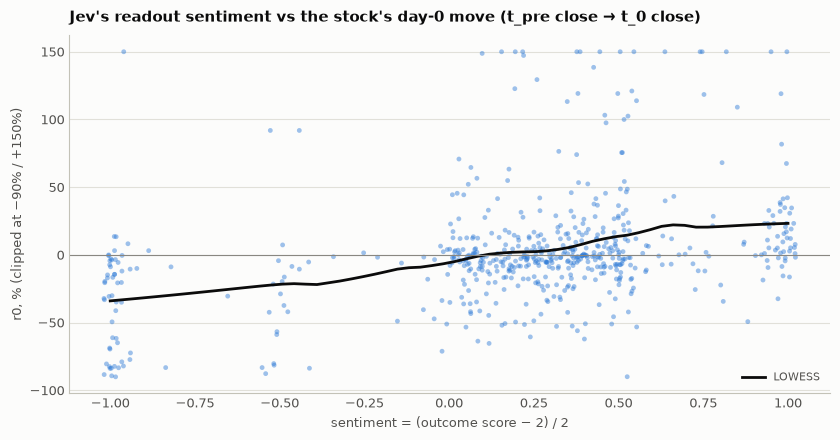

  confidence > median (0.85): n=282, Spearman(sentiment, r0) = 0.52
  confidence <= median (0.85): n=304, Spearman(sentiment, r0) = 0.19
Hand labels (n=60, labelled from the unmasked filing text, blind to Jev; drawn from gated readouts, so the gate number is precision only): readout-gate agreement 100%; outcome Spearman 0.75 (p=0.0e+00); exact level agreement 73%, within one level 98%.
Reliability of met_primary (Jev probability bin -> share of hand labels saying 'met'):


,n,jev_mean,hand_rate
met_primary,,,
"(-0.001, 0.2]",7,0.02,0.0
"(0.2, 0.5]",2,0.34,1.0
"(0.8, 1.0]",13,0.97,1.0


  masking ablation (unmasked): Jev: 100/100, 0s


masking ablation (unmasked): 100 filings labelled by jev-1.13.0 in 0s
Masking ablation (n=100): mean |Δ sentiment| masked vs unmasked = 0.011, Spearman = 1.00; trade direction (at |s| >= 0.5) changes for 1% of filings; mean Δ P(readout) = +0.001, mean Δ P(new) = +0.000.


In [10]:
def spearman(x, y) -> tuple[float, float, int]:
    """Spearman rho, a t-approximation p-value and n (no scipy dependency)."""
    d = pd.DataFrame({"x": x, "y": y}).dropna()
    n = len(d)
    if n < 5:
        return np.nan, np.nan, n
    rho = np.corrcoef(d.x.rank(), d.y.rank())[0, 1]
    t = rho * np.sqrt((n - 2) / max(1 - rho ** 2, 1e-12))
    p = 2 * (1 - 0.5 * (1 + erf(abs(t) / np.sqrt(2))))         # normal approximation to the t distribution (n is large here)
    return float(rho), float(p), n


def lowess(x, y, frac: float = 0.4, grid: int = 60) -> tuple[np.ndarray, np.ndarray]:
    """Local-linear LOWESS with a tricube kernel, evaluated on a grid (no statsmodels dependency)."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    ok = ~(np.isnan(x) | np.isnan(y))
    x, y = x[ok], y[ok]
    xs = np.linspace(x.min(), x.max(), grid)
    k = max(int(frac * len(x)), 5)
    out = []
    for x0 in xs:
        dist = np.abs(x - x0)
        h = np.sort(dist)[min(k, len(x) - 1)] or 1e-9
        w = np.clip(1 - (dist / h) ** 3, 0, 1) ** 3
        W = np.sum(w)
        xm, ym = np.sum(w * x) / W, np.sum(w * y) / W
        b = np.sum(w * (x - xm) * (y - ym)) / max(np.sum(w * (x - xm) ** 2), 1e-12)
        out.append(ym + b * (x0 - xm))
    return xs, np.array(out)


readouts_new = ev_is[(ev_is.is_readout >= READOUT_GATE) & (ev_is.is_new >= NEW_GATE) & ev_is.has_stock]

# 1 · The market as labeller: does Jev's sentiment line up with the day-0 reaction?
rho, p, n = spearman(readouts_new.sentiment, readouts_new.r0)
_d = readouts_new.dropna(subset=["r0", "sentiment"])
_b = np.polyfit(_d.sentiment, _d.r0, 1)
_r2 = 1 - np.sum((_d.r0 - np.polyval(_b, _d.sentiment)) ** 2) / np.sum((_d.r0 - _d.r0.mean()) ** 2)
print(f"Sentiment vs day-0 return, new readouts (n={n}): Spearman rho = {rho:.2f} (p {'< 1e-10' if p < 1e-10 else f'= {p:.1e}'}), OLS slope = {_b[0]:.2f}, R² = {_r2:.2f}.")
print("Mean r0 by outcome level: " + ", ".join(f"{int(k)}: {v:+.1%}" for k, v in readouts_new.groupby(readouts_new.outcome_score.round())["r0"].mean().items()))
print("Sign agreement (sign of r0 = sign of sentiment) among directional readouts: "
      f"{(np.sign(readouts_new.r0[readouts_new.sentiment.abs() >= SENT_THRESHOLD]) == np.sign(readouts_new.sentiment[readouts_new.sentiment.abs() >= SENT_THRESHOLD])).mean():.0%}")

fig, ax = plt.subplots(figsize=(8.5, 4.5))
rng = np.random.default_rng(0)
ax.scatter(readouts_new.sentiment + rng.normal(0, 0.012, len(readouts_new)), readouts_new.r0.clip(-0.9, 1.5) * 100, s=12, alpha=0.45,
           color=SERIES["events"], edgecolor="none")
xs, ys = lowess(readouts_new.sentiment, readouts_new.r0.clip(-0.9, 1.5))
ax.plot(xs, ys * 100, color=INK, linewidth=2, label="LOWESS")
ax.axhline(0, color=MUTED, linewidth=0.8)
style(ax, "Jev's readout sentiment vs the stock's day-0 move (t_pre close → t_0 close)", "sentiment = (outcome score − 2) / 2", "r0, % (clipped at −90% / +150%)")
ax.legend(frameon=False, labelcolor=INK2, fontsize=8)
finish(fig, "sentiment_vs_r0")

# 2 · Confidence: results above and below the median outcome confidence
med_conf = readouts_new.outcome_conf.median()
for lab, g in [("confidence > median", readouts_new[readouts_new.outcome_conf > med_conf]), ("confidence <= median", readouts_new[readouts_new.outcome_conf <= med_conf])]:
    r_, p_, n_ = spearman(g.sentiment, g.r0)
    print(f"  {lab} ({med_conf:.2f}): n={n_}, Spearman(sentiment, r0) = {r_:.2f}")

# 3 · Hand labels: a stratified set of 60 filings, labelled blind from the unmasked text, in hand_labels.csv
HAND_FILE = Path("hand_labels.csv")
_strat = readouts_new.assign(tercile=pd.qcut(readouts_new.sentiment.rank(method="first"), 3, labels=["neg", "mid", "pos"]))
hand_sample = _strat.groupby("tercile", observed=True, group_keys=False).apply(lambda g: g.sample(20, random_state=5))
if not HAND_FILE.exists():
    tmpl = hand_sample[["event_id", "ticker", "filing_date", "items", "supporting_text"]].copy()
    tmpl["press_release_excerpt"] = hand_sample.press_release.str[:2500]
    tmpl["hand_is_readout"] = ""        # 1 / 0
    tmpl["hand_met_primary"] = ""       # 1 / 0 / blank if not applicable
    tmpl["hand_outcome"] = ""           # 0..4 on the OUTCOME_LEVELS scale
    tmpl.to_csv("hand_labels_template.csv", index=False)
    print("No hand_labels.csv yet: wrote hand_labels_template.csv (60 filings, 20 per sentiment tercile) for blind labelling.")
else:
    hand = pd.read_csv(HAND_FILE, dtype={"event_id": str})
    hv = hand.merge(ev_is[["event_id", "is_readout", "met_primary", "outcome_score", "sentiment"]], on="event_id")
    acc_gate = ((hv.is_readout >= READOUT_GATE).astype(int) == hv.hand_is_readout.astype(int)).mean()
    rho_h, p_h, n_h = spearman(hv.outcome_score, hv.hand_outcome)
    exact = (hv.outcome_score.round() == hv.hand_outcome).mean()
    within1 = ((hv.outcome_score.round() - hv.hand_outcome).abs() <= 1).mean()
    print(f"Hand labels (n={len(hv)}, labelled from the unmasked filing text, blind to Jev; drawn from gated readouts, so the gate number is precision only): "
          f"readout-gate agreement {acc_gate:.0%}; "
          f"outcome Spearman {rho_h:.2f} (p={p_h:.1e}); exact level agreement {exact:.0%}, within one level {within1:.0%}.")
    mp = hv.dropna(subset=["hand_met_primary"])
    if len(mp) >= 10:
        bins = pd.cut(mp.met_primary, [0, 0.2, 0.5, 0.8, 1.0], include_lowest=True)
        rel = mp.groupby(bins, observed=True).agg(n=("hand_met_primary", "size"), jev_mean=("met_primary", "mean"), hand_rate=("hand_met_primary", "mean"))
        print("Reliability of met_primary (Jev probability bin -> share of hand labels saying 'met'):")
        display(rel.round(2))

# 4 · Masking ablation: re-label a random subset with the company, ticker and drug codes visible
if N_MASK_ABLATION and (TYPESAFE_API_KEY or True):
    abl_ev = readouts_new.sample(min(N_MASK_ABLATION, len(readouts_new)), random_state=9)
    try:
        abl = label_events(abl_ev, "masking ablation (unmasked)", masked=False, persist=None).set_index("event_id")
        cmp_ = abl_ev.set_index("event_id")[["sentiment", "is_readout", "is_new"]].join(abl[["sentiment", "is_readout", "is_new"]], rsuffix="_unmasked")
        flips = (np.sign(cmp_.sentiment.where(cmp_.sentiment.abs() >= SENT_THRESHOLD, 0)) != np.sign(cmp_.sentiment_unmasked.where(cmp_.sentiment_unmasked.abs() >= SENT_THRESHOLD, 0))).mean()
        print(f"Masking ablation (n={len(cmp_)}): mean |Δ sentiment| masked vs unmasked = {(cmp_.sentiment - cmp_.sentiment_unmasked).abs().mean():.3f}, "
              f"Spearman = {spearman(cmp_.sentiment, cmp_.sentiment_unmasked)[0]:.2f}; trade direction (at |s| >= {SENT_THRESHOLD}) changes for {flips:.0%} of filings; "
              f"mean Δ P(readout) = {(cmp_.is_readout - cmp_.is_readout_unmasked).mean():+.3f}, mean Δ P(new) = {(cmp_.is_new - cmp_.is_new_unmasked).mean():+.3f}.")
    except RuntimeError as e:
        print(f"Masking ablation skipped: {e}")

## 7 · The option chain, quotes and the hedge legs

For every readout with a direction worth testing (|sentiment| ≥ 0.25, so the sensitivity rows exist), two chain requests:
the contracts as of `t_pre` (the **ATM pair** nearest `S_pre`, whose closing quotes or last trades give the implied move
and the pre-news IV) and as of `t_0` (the **hedge legs** around the post-event spot `S_0`: put at or below
`S_0 × (1 − OTM)`, call at or above `S_0 × (1 + OTM)`, for each OTM level in the baseline bucket; strikes listed on the
morning of `t_0` after a big gap are included). Each bucket's expiry is the listed expiry nearest its target that has a
real chain.

Marks: the closing NBBO **mid** where a two-sided quote was fetched (entry sessions, and every exit session for the
headline legs), else the last trade if at most `MAX_STALE_SESSIONS` old, else intrinsic value once the contract has
expired. Quotes also give the bid-ask spread that section 15 charges, and the **liquidity gate**: hedge-leg spread
≤ 25% of mid or ≤ $0.10, at least 10 contracts traded on `t_0`, stock dollar volume ≥ $1M.

Black-Scholes inversion on the straddle (`straddle_iv`) gives the ATM implied volatility on `t_pre`, `t_0` and `t_0 + 5`
for section 12.

In [11]:
def option_bars(opt_ticker: str, start, end) -> pd.DataFrame:
    """Daily bars for one contract: index = session, columns close and volume. Only sessions where it traded."""
    rows = api_get_all(f"/v2/aggs/ticker/{opt_ticker}/range/1/day/{pd.Timestamp(start):%Y-%m-%d}/{pd.Timestamp(end):%Y-%m-%d}",
                       {"adjusted": "false", "sort": "asc", "limit": 50000})
    if not rows:
        return pd.DataFrame(columns=["close", "volume"], index=pd.DatetimeIndex([], name="session"))
    idx = (pd.to_datetime([r["t"] for r in rows], unit="ms", utc=True).tz_convert("America/New_York").normalize().tz_localize(None))
    return pd.DataFrame({"close": [float(r["c"]) for r in rows], "volume": [float(r.get("v") or 0) for r in rows]},
                        index=pd.DatetimeIndex(idx, name="session"))


def quote_at_close(opt_ticker: str, day) -> dict | None:
    """The last NBBO quote of the session (one request; cached): bid, ask, mid and the spread. None if no quote or no ask."""
    rows = api_get(f"/v3/quotes/{opt_ticker}", {"timestamp": pd.Timestamp(day).strftime("%Y-%m-%d"), "order": "desc",
                                                "sort": "timestamp", "limit": 1}).get("results") or []
    if not rows:
        return None
    q = rows[0]
    bid, ask = float(q.get("bid_price") or 0), float(q.get("ask_price") or 0)
    if ask <= 0:
        return None
    return {"bid": bid, "ask": ask, "mid": (bid + ask) / 2 if bid > 0 else np.nan, "spread": ask - bid if bid > 0 else np.nan,
            "rel_spread": (ask - bid) / ((bid + ask) / 2) if bid > 0 else np.nan}


def fetch_chain(ticker: str, as_of: pd.Timestamp, dte_lo: int, dte_hi: int) -> pd.DataFrame:
    """Every standard contract that existed on `as_of` with an expiry `dte_lo`..`dte_hi` days out."""
    rows = api_get_all("/v3/reference/options/contracts", {
        "underlying_ticker": ticker, "as_of": as_of.strftime("%Y-%m-%d"),
        "expiration_date.gte": (as_of + pd.Timedelta(days=dte_lo)).strftime("%Y-%m-%d"),
        "expiration_date.lte": (as_of + pd.Timedelta(days=dte_hi)).strftime("%Y-%m-%d"),
        "limit": 1000,
    })
    chain = pd.DataFrame(rows)
    if chain.empty:
        return chain
    if "shares_per_contract" in chain:
        chain = chain[chain["shares_per_contract"].fillna(100) == 100]      # drop post-split non-standard series
    chain = chain[["ticker", "contract_type", "strike_price", "expiration_date"]].copy()
    chain["expiration_date"] = pd.to_datetime(chain["expiration_date"])
    chain["dte"] = (chain["expiration_date"] - as_of).dt.days
    chain["strike_price"] = chain["strike_price"].astype(float)
    return chain.reset_index(drop=True)


def paired_strikes(e: pd.DataFrame) -> np.ndarray:
    both = e.groupby("strike_price")["contract_type"].nunique()
    return both[both == 2].index.to_numpy(dtype=float)


def contract(e: pd.DataFrame, strike: float, kind: str) -> str | None:
    hit = e[(e.strike_price == strike) & (e.contract_type == kind)]["ticker"]
    return hit.iloc[0] if len(hit) else None


def pick_expiry(chain: pd.DataFrame, lo: int, hi: int, target: int) -> pd.Timestamp | None:
    cand = chain[(chain.dte >= lo) & (chain.dte <= hi)]
    if cand.empty:
        return None
    dte_of = cand.groupby("expiration_date")["dte"].first()
    ok = [x for x, g in cand.groupby("expiration_date") if len(paired_strikes(g)) >= 3]   # needs a real chain, not a stub
    if not ok:
        return None
    return min(ok, key=lambda x: abs(dte_of[x] - target))


def atm_strike(e: pd.DataFrame, spot: float) -> float | None:
    both = paired_strikes(e)
    both = both[(both >= spot * (1 - STRIKE_WINDOW)) & (both <= spot * (1 + STRIKE_WINDOW))]
    return float(both[np.abs(both - spot).argmin()]) if len(both) else None


def hedge_strikes(e: pd.DataFrame, spot: float, otm_pcts: list[float]) -> dict[str, float]:
    """For each OTM level: call strike U at or above spot*(1+pct) and put strike L at or below spot*(1-pct)
    (the farthest listed strike when none is far enough)."""
    calls = np.sort(e.loc[e.contract_type == "call", "strike_price"].unique())
    puts = np.sort(e.loc[e.contract_type == "put", "strike_price"].unique())
    out = {}
    for pct in otm_pcts:
        up, dn = calls[calls >= spot * (1 + pct)], puts[puts <= spot * (1 - pct)]
        out[f"U{pct}"] = float(up.min()) if len(up) else (float(calls.max()) if len(calls) else np.nan)
        out[f"L{pct}"] = float(dn.max()) if len(dn) else (float(puts.min()) if len(puts) else np.nan)
    return out


# ---- Black-Scholes, for implied volatility (math imports in section 1) -------------------------------


def _ncdf(x):
    return 0.5 * (1 + erf(x / sqrt(2)))


def bs_price(S, K, T, sigma, kind, r=RISK_FREE):
    if T <= 0 or sigma <= 0:
        return max(S - K, 0) if kind == "call" else max(K - S, 0)
    d1 = (log(S / K) + (r + sigma ** 2 / 2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    if kind == "call":
        return S * _ncdf(d1) - K * exp(-r * T) * _ncdf(d2)
    return K * exp(-r * T) * _ncdf(-d2) - S * _ncdf(-d1)


def implied_vol(price, S, K, T, kind, lo=0.01, hi=10.0) -> float:
    """Bisection on Black-Scholes. NaN when the price is outside the no-arbitrage band."""
    if not (price > 0 and S > 0 and K > 0 and T > 0):
        return np.nan
    if price < bs_price(S, K, T, lo, kind) or price > bs_price(S, K, T, hi, kind):
        return np.nan
    for _ in range(60):
        mid = (lo + hi) / 2
        if bs_price(S, K, T, mid, kind) > price:
            hi = mid
        else:
            lo = mid
    return (lo + hi) / 2


def straddle_iv(C, P, S, K, T) -> float:
    """One volatility that prices call + put together (robust when one leg is stale)."""
    if not (C > 0 or P > 0) or not (S > 0 and T > 0):
        return np.nan
    target, lo, hi = C + P, 0.01, 10.0
    f = lambda s: bs_price(S, K, T, s, "call") + bs_price(S, K, T, s, "put")
    if target < f(lo) or target > f(hi):
        return np.nan
    for _ in range(60):
        mid = (lo + hi) / 2
        lo, hi = (lo, mid) if f(mid) > target else (mid, hi)
    iv = (lo + hi) / 2
    return iv if iv < 9.9 else np.nan          # at the upper bound the quote is not a volatility (a stale or one-sided mark)


@dataclass
class Leg:
    ticker: str
    kind: str                 # "call" or "put"
    strike: float
    bars: pd.DataFrame        # close, volume by session (only sessions with trades)

    def mark(self, day: pd.Timestamp) -> float:
        """Last traded close on or before `day`, if it is at most MAX_STALE_SESSIONS sessions old."""
        b = self.bars.loc[: pd.Timestamp(day)]
        if b.empty or sessions_between(b.index[-1], day) > MAX_STALE_SESSIONS:
            return np.nan
        return float(b["close"].iloc[-1])

    def volume_on(self, day: pd.Timestamp) -> float:
        return float(self.bars["volume"].get(pd.Timestamp(day), 0.0))

    def intrinsic(self, S: float) -> float:
        return max(S - self.strike, 0.0) if self.kind == "call" else max(self.strike - S, 0.0)


@dataclass
class PricedEvent:
    """One event x one expiry bucket: real spot, the expiry, the ATM pair (read on t_pre for the implied move) and
    the hedge legs (chosen on t_0 around the post-event spot)."""
    event_id: str
    ticker: str
    t_pre: pd.Timestamp
    t_0: pd.Timestamp
    bucket: str
    expiry: pd.Timestamp
    expiry_session: pd.Timestamp
    S_pre: float                        # unadjusted stock close on t_pre (what the strikes refer to)
    S_0: float                          # unadjusted stock close on t_0 (entry)
    strikes: dict[str, float]
    legs: dict[str, Leg]                # "C_K", "P_K", "C_U0.1", "P_L0.1", ...
    quotes: dict = field(default_factory=dict)   # (leg_key, day) -> quote dict

    def stock(self, day) -> float:
        """Unadjusted close on `day`; the last available close if the name stopped trading (delisting, acquisition)."""
        b = STOCK_BARS.get((self.ticker, False))
        if b is None:
            return np.nan
        s = b.loc[:pd.Timestamp(day), "close"]
        return float(s.iloc[-1]) if len(s) else np.nan

    def mark(self, key: str, day) -> float:
        """Option mark on `day`: the closing NBBO mid where a two-sided quote was fetched, else the last trade
        (<= MAX_STALE_SESSIONS old), else intrinsic value once the contract has expired."""
        day = pd.Timestamp(day)
        if day >= self.expiry_session:
            return self.legs[key].intrinsic(self.stock(self.expiry_session))
        q = self.quotes.get((key, day))
        if q is not None and q["mid"] > 0:
            return q["mid"]
        return self.legs[key].mark(day)

    def marks(self, day) -> dict[str, float]:
        return {k: self.mark(k, day) for k in self.legs}

    def quote(self, key: str, day) -> dict | None:
        return self.quotes.get((key, pd.Timestamp(day)))


def price_event(r, buckets: dict, otm_pcts: list[float], full_grid_bucket: str = BASELINE_BUCKET) -> tuple[list[PricedEvent], list[str]]:
    """Chain as of t_pre (ATM pair, implied move) and as of t_0 (hedge legs around the post-event spot), bars for every leg,
    closing quotes for the hedge legs on t_0 and the ATM pair on t_pre / t_0 (baseline bucket)."""
    S_pre, S_0 = stock_close(r.ticker, r.t_pre, adjusted=False), stock_close(r.ticker, r.t_0, adjusted=False)
    if not (S_pre > 0 and S_0 > 0):
        return [], ["no stock close on t_pre or t_0"]
    dte_hi = max(b[1] for b in buckets.values())
    chain_pre = fetch_chain(r.ticker, r.t_pre, 2, dte_hi)
    if chain_pre.empty:
        return [], ["no option chain as of t_pre"]
    chain_0 = fetch_chain(r.ticker, r.t_0, 1, dte_hi)
    priced, notes = [], []
    for name, (lo, hi, target) in buckets.items():
        expiry = pick_expiry(chain_pre, lo, hi, target)
        if expiry is None:
            notes.append(f"{name}: no expiry {lo}-{hi} days out")
            continue
        e_pre = chain_pre[chain_pre.expiration_date == expiry]
        e_0 = chain_0[chain_0.expiration_date == expiry] if not chain_0.empty else e_pre
        if e_0.empty:
            e_0 = e_pre
        K = atm_strike(e_pre, S_pre)
        if K is None:
            notes.append(f"{name}: no paired strike near spot")
            continue
        pcts = otm_pcts if name == full_grid_bucket else [OTM_PCT]
        hs = hedge_strikes(e_0, S_0, pcts)
        wanted = {"C_K": ("call", K, e_pre), "P_K": ("put", K, e_pre)}
        for pct in pcts:
            wanted[f"C_U{pct}"] = ("call", hs[f"U{pct}"], e_0)
            wanted[f"P_L{pct}"] = ("put", hs[f"L{pct}"], e_0)
        legs, missing = {}, []
        for key, (kind, k, e) in wanted.items():
            tk = contract(e, k, kind) if np.isfinite(k) else None
            if tk is None:
                missing.append(key)
                continue
            legs[key] = Leg(tk, kind, k, option_bars(tk, r.t_pre - pd.Timedelta(days=10), expiry))
        if "C_K" not in legs or "P_K" not in legs or any(f"P_L{OTM_PCT}" == m or f"C_U{OTM_PCT}" == m for m in missing):
            notes.append(f"{name}: a needed contract is not listed ({', '.join(missing)})")
            continue
        pe = PricedEvent(r.event_id, r.ticker, r.t_pre, r.t_0, name, expiry, CAL[CAL.searchsorted(expiry, side="right") - 1],
                         S_pre, S_0, {"K": K, **hs}, legs)
        for key in ("C_K", "P_K"):                                    # the implied move needs a mark for both ATM legs on t_pre
            pe.quotes[(key, r.t_pre)] = quote_at_close(legs[key].ticker, r.t_pre)
        if np.isnan(pe.mark("C_K", r.t_pre)) or np.isnan(pe.mark("P_K", r.t_pre)):
            notes.append(f"{name}: ATM pair had neither a two-sided quote nor a trade on or near t_pre")
            continue
        for pct in pcts:
            for key in (f"P_L{pct}", f"C_U{pct}"):
                pe.quotes[(key, r.t_0)] = quote_at_close(legs[key].ticker, r.t_0)
        if name == full_grid_bucket:                                  # headline legs: quotes on every exit session too
            i0 = CAL.get_loc(r.t_0)
            exit_days = [CAL[i0 + h] for h in HORIZONS if i0 + h < len(CAL) and CAL[i0 + h] <= min(LAST_SESSION, pe.expiry_session - pd.Timedelta(days=1))]
            for key in ("C_K", "P_K"):
                for d in [r.t_0] + exit_days[:4]:
                    pe.quotes[(key, d)] = quote_at_close(legs[key].ticker, d)
            for key in (f"P_L{OTM_PCT}", f"C_U{OTM_PCT}"):
                for d in exit_days:
                    pe.quotes[(key, d)] = quote_at_close(legs[key].ticker, d)
        priced.append(pe)
    return priced, notes


def price_events(ev: pd.DataFrame, buckets: dict = None, otm_pcts: list[float] = None, label: str = "events") -> tuple[list[PricedEvent], pd.DataFrame]:
    buckets = buckets or EXPIRY_BUCKETS
    otm_pcts = otm_pcts or OTM_GRID
    t0 = time.time()
    rows = list(ev.itertuples(index=False))
    out = parallel_map(lambda r: price_event(r, buckets, otm_pcts), rows, label=f"{label}: pricing", every=50)
    priced, dropped = [], []
    for r, (got, notes) in zip(rows, out):
        priced += got
        dropped += [(r.event_id, r.ticker, r.t_0, note) for note in notes]
    print(f"{label}: {len(ev)} events -> {len(priced)} priced (event, bucket) pairs; {len(dropped)} drops; {time.time() - t0:.0f}s")
    return priced, pd.DataFrame(dropped, columns=["event_id", "ticker", "t_0", "reason"])


def summarize_priced(priced: list[PricedEvent]) -> pd.DataFrame:
    """One row per (event, bucket): implied move, IVs, hedge cost and liquidity. The `spot_gap` column is the put-call-parity
    cross-check of the real close (synthetic spot from the ATM pair on t_pre vs the stock close)."""
    rows = []
    for pe in priced:
        m_pre, m_0 = pe.marks(pe.t_pre), pe.marks(pe.t_0)
        T_pre, T_0 = (pe.expiry - pe.t_pre).days / 365, (pe.expiry - pe.t_0).days / 365
        q = {k: pe.quote(k, pe.t_0) for k in pe.legs if k.startswith(("P_L", "C_U"))}
        synth = pe.strikes["K"] * np.exp(-RISK_FREE * T_pre) + m_pre["C_K"] - m_pre["P_K"]
        t5 = shift_session(pe.t_0, 5)
        row = {"event_id": pe.event_id, "ticker": pe.ticker, "t_pre": pe.t_pre, "t_0": pe.t_0, "bucket": pe.bucket, "expiry": pe.expiry,
               "dte": (pe.expiry - pe.t_pre).days, "S_pre": pe.S_pre, "S_0": pe.S_0, "K": pe.strikes["K"], "moneyness": pe.strikes["K"] / pe.S_pre - 1,
               "implied_move": (m_pre["C_K"] + m_pre["P_K"]) / pe.S_pre, "spot_gap": synth / pe.S_pre - 1,
               "straddle_0": (m_0["C_K"] + m_0["P_K"]) / pe.S_0,
               "iv_pre": straddle_iv(m_pre["C_K"], m_pre["P_K"], pe.S_pre, pe.strikes["K"], T_pre),
               "iv_0": straddle_iv(m_0["C_K"], m_0["P_K"], pe.S_0, pe.strikes["K"], T_0),
               "iv_5": straddle_iv(pe.mark("C_K", t5), pe.mark("P_K", t5), pe.stock(t5), pe.strikes["K"], max((pe.expiry - t5).days, 0) / 365) if t5 <= LAST_SESSION else np.nan,
               "atm_volume_pre": pe.legs["C_K"].volume_on(pe.t_pre) + pe.legs["P_K"].volume_on(pe.t_pre),
               "stock_dollar_volume_0": stock_field(pe.ticker, pe.t_0, "volume") * pe.S_0}
        for pct in OTM_GRID:
            pk, ck = f"P_L{pct}", f"C_U{pct}"
            if pk not in pe.legs:
                continue
            qp, qc = q.get(pk), q.get(ck)
            row.update({f"put_cost_{pct}": m_0[pk] / pe.S_0, f"call_cost_{pct}": m_0[ck] / pe.S_0,
                        f"put_cost_pre_{pct}": pe.legs[pk].mark(pe.t_pre) / pe.S_pre, f"call_cost_pre_{pct}": pe.legs[ck].mark(pe.t_pre) / pe.S_pre,
                        f"put_otm_{pct}": 1 - pe.strikes[f"L{pct}"] / pe.S_0, f"call_otm_{pct}": pe.strikes[f"U{pct}"] / pe.S_0 - 1,
                        f"put_rel_spread_{pct}": qp["rel_spread"] if qp else np.nan, f"put_abs_spread_{pct}": qp["spread"] if qp else np.nan,
                        f"call_rel_spread_{pct}": qc["rel_spread"] if qc else np.nan, f"call_abs_spread_{pct}": qc["spread"] if qc else np.nan,
                        f"put_mid_{pct}": qp["mid"] if qp else np.nan, f"call_mid_{pct}": qc["mid"] if qc else np.nan,
                        f"put_volume_{pct}": pe.legs[pk].volume_on(pe.t_0), f"call_volume_{pct}": pe.legs[ck].volume_on(pe.t_0)})
        rows.append(row)
    return pd.DataFrame(rows)


def liquid(panel_row, side: str, pct: float = OTM_PCT) -> bool:
    """The trade-layer liquidity gate for one (event, bucket) and one side of the book."""
    leg = "put" if side == "long" else "call"
    rel, ab, vol = panel_row.get(f"{leg}_rel_spread_{pct}", np.nan), panel_row.get(f"{leg}_abs_spread_{pct}", np.nan), panel_row.get(f"{leg}_volume_{pct}", 0)
    spread_ok = (rel <= MAX_REL_SPREAD) or (ab <= MAX_ABS_SPREAD)
    return bool(spread_ok and vol >= MIN_HEDGE_VOLUME and panel_row.get("stock_dollar_volume_0", 0) >= MIN_STOCK_DOLLAR_VOL)


# Price every filing that passes the Jev gates and has a direction worth testing at any sensitivity threshold.
readouts_is = ev_is[(ev_is.is_readout >= READOUT_GATE) & ev_is.has_stock]
cand_is = readouts_is[readouts_is.sentiment.abs() >= 0.25]
print(f"{len(readouts_is)} readouts in-sample ({(readouts_is.is_new >= NEW_GATE).sum()} first disclosures, the rest stale); "
      f"{len(cand_is)} directional candidates (|sentiment| >= 0.25) go to the option chain.")
priced, dropped = price_events(cand_is, label="in-sample")
panel = summarize_priced(priced)
if len(dropped):
    display(dropped["reason"].value_counts().rename("dropped (event, bucket)").to_frame())
display(panel.assign(abs_spot_gap=panel.spot_gap.abs()).groupby("bucket")[["dte", "moneyness", "abs_spot_gap", "implied_move", "iv_pre", "iv_0", f"put_cost_{OTM_PCT}", f"call_cost_{OTM_PCT}", "atm_volume_pre"]]
        .median().round(3).rename(columns=lambda c: f"median {c}"))
print(f"Put-call-parity cross-check (baseline bucket): median |synthetic - real| / real = {panel[panel.bucket == BASELINE_BUCKET].spot_gap.abs().median():.2%}")

947 readouts in-sample (586 first disclosures, the rest stale); 646 directional candidates (|sentiment| >= 0.25) go to the option chain.


  in-sample: pricing: 50/646, 1s


  in-sample: pricing: 100/646, 2s


  in-sample: pricing: 150/646, 3s


  in-sample: pricing: 200/646, 3s


...

  in-sample: pricing: 600/646, 10s


in-sample: 646 events -> 1049 priced (event, bucket) pairs; 593 drops; 11s


,"dropped (event, bucket)"
reason,
no option chain as of t_pre,148
2m: no expiry 46-80 days out,144
1m: ATM pair had neither a two-sided quote nor a trade on or near t_pre,66
2m: ATM pair had neither a two-sided quote nor a trade on or near t_pre,59
3-6m: ATM pair had neither a two-sided quote nor a trade on or near t_pre,52
1m: no expiry 21-45 days out,47
3-6m: no paired strike near spot,27
2m: no paired strike near spot,24
1m: no paired strike near spot,21


,median dte,median moneyness,median abs_spot_gap,median implied_move,median iv_pre,median iv_0,median put_cost_0.1,median call_cost_0.1,median atm_volume_pre
bucket,,,,,,,,,
1m,32.0,0.000,0.011,0.285,1.166,1.003,0.038,0.056,10.5
2m,58.0,0.000,0.012,0.350,1.072,0.982,0.065,0.084,1.0
3-6m,130.0,-0.001,0.014,0.453,0.979,0.981,0.110,0.143,0.0


Put-call-parity cross-check (baseline bucket): median |synthetic - real| / real = 1.14%


### The signal table and the funnel

`build_signal` applies the rule to the labelled table: gates, `expected = BETA × sentiment × IM`, `gap`, and the
direction (+1 / −1 / 0). `BETA` is the no-intercept OLS of `r0` on `sentiment × IM` over in-sample events with a real
implied move, then **frozen**; events without a usable chain (most micro-caps) get the in-sample median implied move of
their size bucket as a proxy, also frozen. The funnel counts filings at every gate: tagged → in universe → new readout →
directional → under-reacted → stock bars → optionable → liquid.

In [12]:
def implied_move_table(panel: pd.DataFrame, bucket: str = BASELINE_BUCKET) -> pd.Series:
    """Implied move per event from the baseline bucket, falling back to the nearest priced bucket."""
    order = {b: i for i, b in enumerate([bucket] + [b for b in EXPIRY_BUCKETS if b != bucket])}
    p = panel.assign(_o=panel.bucket.map(order)).sort_values("_o").drop_duplicates("event_id")
    return p.set_index("event_id")["implied_move"]


def fit_beta(sig: pd.DataFrame) -> float:
    """OLS of r0 on sentiment * IM, no intercept, on events with a real implied move. Frozen after the in-sample fit."""
    d = sig.dropna(subset=["r0", "IM_real", "sentiment"])
    d = d[d.sentiment.abs() >= 0.25]
    x, y = (d.sentiment * d.IM_real).to_numpy(), d.r0.to_numpy()
    return float((x * y).sum() / (x * x).sum())


def build_signal(ev: pd.DataFrame, panel: pd.DataFrame, beta: float | None, im_proxy: pd.Series | None,
                 sent_threshold: float = SENT_THRESHOLD, already_moved: float | None = ALREADY_MOVED,
                 readout_gate: float = READOUT_GATE, new_gate: float = NEW_GATE, safety_veto: float = SAFETY_VETO,
                 conf_gate: float | None = None, mode: str = "gap") -> pd.DataFrame:
    """The trade rule on the labelled event table. Returns one row per event with the gates, `expected`, `gap` and `direction`
    (+1 long, -1 short, 0 no trade). `beta` and `im_proxy` (median IM by size bucket) must come from the in-sample fit.

    `mode` selects the day-0 condition: "gap" (pre-registered: r0 short of already_moved x expected, whatever its sign),
    "same_sign" (moved in Jev's direction but short of already_moved x expected), "over" (moved beyond expected: the
    continuation variant, exploratory), "none" (follow Jev's sign with no day-0 condition)."""
    s = ev.copy()
    s["IM_real"] = s["event_id"].map(implied_move_table(panel)) if len(panel) else np.nan
    s.loc[(s.IM_real < MIN_IM) | (s.IM_real > MAX_IM), "IM_real"] = np.nan
    s["IM"] = s["IM_real"]
    if im_proxy is not None:
        s["IM"] = s["IM"].fillna(s["size"].map(im_proxy)).fillna(im_proxy.get("all", np.nan))
    s["IM_source"] = np.where(s.IM_real.notna(), "chain", "size-bucket median")
    s["gate_readout"] = s.is_readout >= readout_gate
    s["gate_new"] = s.is_new >= new_gate
    s["gate_conf"] = True if conf_gate is None else (s.outcome_conf > conf_gate)
    s["gate_stock"] = s.has_stock.fillna(False).astype(bool)
    s["directional"] = s.sentiment.abs() >= sent_threshold
    s["expected"] = (beta if beta is not None else np.nan) * s.sentiment * s.IM
    s["gap"] = s.expected - s.r0
    signed_r0, signed_exp = np.sign(s.sentiment) * s.r0, s.sentiment.abs() * (beta if beta is not None else np.nan) * s.IM
    if already_moved is None or mode == "none":
        under = pd.Series(True, index=s.index)
    elif mode == "gap":
        under = signed_r0 < already_moved * signed_exp
    elif mode == "same_sign":
        under = (signed_r0 >= 0) & (signed_r0 < already_moved * signed_exp)
    elif mode == "over":
        under = signed_r0 > signed_exp
    else:
        raise ValueError(mode)
    s["under_reacted"] = pd.Series(under, index=s.index).fillna(False).astype(bool)
    s["safety_ok"] = ~((s.sentiment > 0) & (s.safety_signal >= safety_veto))
    base = s.gate_readout & s.gate_new & s.gate_conf & s.gate_stock & s.directional
    s["direction"] = np.where(base & s.under_reacted & s.safety_ok, np.sign(s.sentiment), 0).astype(int)
    return s


def funnel(sig: pd.DataFrame, panel: pd.DataFrame, label: str) -> pd.Series:
    steps = {"tagged filings in universe": len(sig),
             "Jev: new human readout (is_readout, is_new)": int((sig.gate_readout & sig.gate_new).sum()),
             f"directional (|sentiment| >= {SENT_THRESHOLD})": int((sig.gate_readout & sig.gate_new & sig.directional).sum()),
             "under-reacted on day 0 (and no safety veto on longs)": int((sig.direction != 0).sum()),
             "  ... of which long": int((sig.direction > 0).sum()), "  ... of which short": int((sig.direction < 0).sum())}
    traded = sig[sig.direction != 0]
    p = panel[(panel.bucket == BASELINE_BUCKET) & panel.event_id.isin(traded.event_id)].set_index("event_id")
    steps["stock bars on t_pre and t_0"] = int(traded.gate_stock.sum())
    steps[f"optionable ({BASELINE_BUCKET} hedge leg listed and ATM pair traded)"] = int(traded.event_id.isin(p.index).sum())
    liq = [liquid(p.loc[e], "long" if d > 0 else "short") for e, d in zip(traded.event_id, traded.direction) if e in p.index]
    steps["liquid (spread, hedge volume, stock $ volume)"] = int(sum(liq))
    return pd.Series(steps, name=label)


# In-sample fit: BETA and the size-bucket IM proxy are estimated here and frozen for OOS and the sealed window.
_sig0 = build_signal(ev_is, panel, beta=None, im_proxy=None)
BETA = fit_beta(_sig0)
IM_PROXY = _sig0.dropna(subset=["IM_real"]).groupby("size")["IM_real"].median()
IM_PROXY["all"] = _sig0.IM_real.median()
print(f"BETA (OLS of r0 on sentiment x IM, no intercept, in-sample, n={int(_sig0.IM_real.notna().sum())}) = {BETA:.2f}  -> frozen.")
print("Implied-move proxy for events without a usable chain (median IM by size bucket): " + ", ".join(f"{k}: {v:.0%}" for k, v in IM_PROXY.items()))

signal_is = build_signal(ev_is, panel, BETA, IM_PROXY)
funnel_is = funnel(signal_is, panel, "in-sample")
display(funnel_is.to_frame())
trades_is = signal_is[signal_is.direction != 0]
print(f"Long book: {(trades_is.direction > 0).sum()} events, mean r0 {trades_is.r0[trades_is.direction > 0].mean():+.1%}; "
      f"short book: {(trades_is.direction < 0).sum()} events, mean r0 {trades_is.r0[trades_is.direction < 0].mean():+.1%}.")
with pd.option_context("display.max_colwidth", 70):
    display(trades_is[["ticker", "filing_date", "size", "sentiment", "outcome_conf", "IM", "IM_source", "r0", "expected", "gap", "direction"]]
            .assign(**{c: lambda d, c=c: d[c].map("{:+.1%}".format) for c in ["r0", "expected", "gap"]}, IM=lambda d: d.IM.map("{:.0%}".format))
            .sample(min(8, len(trades_is)), random_state=2))

BETA (OLS of r0 on sentiment x IM, no intercept, in-sample, n=441) = 0.78  -> frozen.
Implied-move proxy for events without a usable chain (median IM by size bucket): micro: 43%, mid+: 20%, small: 34%, all: 31%


,in-sample
tagged filings in universe,1140
"Jev: new human readout (is_readout, is_new)",596
directional (|sentiment| >= 0.5),214
under-reacted on day 0 (and no safety veto on longs),94
... of which long,74
... of which short,20
stock bars on t_pre and t_0,94
optionable (1m hedge leg listed and ATM pair traded),51
"liquid (spread, hedge volume, stock $ volume)",9


Long book: 74 events, mean r0 -9.0%; short book: 20 events, mean r0 +12.9%.


,ticker,filing_date,size,sentiment,outcome_conf,IM,IM_source,r0,expected,gap,direction
422,GLYC,2024-10-29,micro,-0.945,0.91,43%,size-bucket median,+191.3%,-32.0%,-223.3%,-1
306,FSI,2024-08-12,micro,-0.930,0.88,43%,size-bucket median,+8.3%,-31.5%,-39.7%,-1
705,SMMT,2025-04-25,mid+,0.795,0.65,22%,chain,-34.3%,+13.6%,+47.9%,1
256,SVRA,2024-06-26,small,0.935,0.89,63%,chain,+1.1%,+46.0%,+44.9%,1
206,GLYC,2024-06-04,micro,-0.500,0.97,43%,size-bucket median,+7.4%,-16.9%,-24.3%,-1
900,IXHL,2025-08-26,micro,0.525,0.96,43%,size-bucket median,-4.1%,+17.8%,+21.9%,1
44,TNXP,2024-02-27,micro,0.590,0.32,43%,size-bucket median,+6.9%,+20.0%,+13.1%,1
282,CLRB,2024-07-23,micro,0.920,0.86,31%,chain,-18.5%,+21.9%,+40.5%,1


## 8 · P&L engine

`evaluate` builds one long table with a row per (event, bucket, entry, OTM level, horizon) holding the **leg components**
per $1 of stock at entry: the stock return and the change in value of each option leg. `book_pnl` turns components into
strategies once a direction is attached, so a change of rule never re-prices anything:

| Book | Strategy | P&L per $1 of stock at entry |
|---|---|---|
| long | long stock (unhedged) | $\Delta S / S_e$ |
| long | **3 · protective put** | $(\Delta S + \Delta P_L) / S_e$ |
| long | 4 · collar | $(\Delta S + \Delta P_L - \Delta C_U) / S_e$ |
| long | 1 · long call instead of stock | $\Delta C_K / S_e$ |
| long | 2 · covered call, 5 · cash-secured put | $(\Delta S - \Delta C_U)/S_e$, $-\Delta P_L / S_e$ (for the ranking) |
| short | short stock (unhedged) | $-\Delta S / S_e - \text{borrow} \cdot d/365$ |
| short | **1 · short stock + long call** | $(-\Delta S + \Delta C_U) / S_e - \text{borrow} \cdot d/365$ |

$S$ is the real unadjusted close. Horizons beyond the hedge's expiry are kept: the option settles at intrinsic value and
the stock is held on unhedged (`past_expiry` flags those rows), which is what a 1-month hedge means for a 2-month hold.
`max_loss` is the loss if the stock goes through the strike: OTM distance plus premium (plus borrow on the short side).

**Exit rules.** `exit_session` implements the pre-registered rule: the time stop `H*` (chosen in section 9 as the
in-sample horizon where the hedged edge over placebo peaks, then frozen), a **catch-up exit** when `S_t/S_pre − 1` has
reached `expected` (the gap is gone), and an **information exit** at the session after the filer's next 8-K. The option is
the stop-loss; there is no separate price stop.

In [13]:
LONG_STRATEGIES = ["long_stock", "protective_put", "collar", "long_call", "covered_call", "cash_secured_put"]
SHORT_STRATEGIES = ["short_stock", "short_long_call"]
STRATEGY_LABEL = {"long_stock": "Long stock (unhedged)", "protective_put": "3 · Long stock + protective put", "collar": "4 · Long stock + collar",
                  "long_call": "1 · Long call (ATM) instead of stock", "covered_call": "2 · Covered call", "cash_secured_put": "5 · Cash-secured put",
                  "short_stock": "Short stock (unhedged)", "short_long_call": "1 · Short stock + long call",
                  "unhedged": "Directional stock, unhedged", "hedged": "Directional stock + option hedge"}
STRATEGIES = LONG_STRATEGIES + SHORT_STRATEGIES


def leg_components(pe: PricedEvent, e_day, x_day, otm: float) -> dict | None:
    """Everything a strategy's P&L is built from, per $1 of stock at entry: the stock return and each option leg's
    change in value. Option legs are marked at the last trade (or intrinsic value once expired)."""
    S_e, S_x = pe.stock(e_day), pe.stock(x_day)
    pk, ck = f"P_L{otm}", f"C_U{otm}"
    if pk not in pe.legs or not (S_e > 0) or not (S_x > 0):
        return None
    m_e = {k: pe.mark(k, e_day) for k in ("C_K", "P_K", pk, ck)}
    m_x = {k: pe.mark(k, x_day) for k in ("C_K", "P_K", pk, ck)}
    return {"S_entry": S_e, "S_exit": S_x, "realized": S_x / S_e - 1,
            "put_leg": (m_x[pk] - m_e[pk]) / S_e, "call_leg": (m_x[ck] - m_e[ck]) / S_e,
            "atm_call_leg": (m_x["C_K"] - m_e["C_K"]) / S_e, "atm_put_leg": (m_x["P_K"] - m_e["P_K"]) / S_e,
            "put_cost": m_e[pk] / S_e, "call_cost": m_e[ck] / S_e, "straddle_cost": (m_e["C_K"] + m_e["P_K"]) / S_e,
            "put_otm": 1 - pe.strikes[f"L{otm}"] / S_e, "call_otm": pe.strikes[f"U{otm}"] / S_e - 1}


def evaluate(priced: list[PricedEvent], otm_pcts: list[float] = None) -> pd.DataFrame:
    """Long table: one row per (event, bucket, entry, OTM level, horizon) with the leg components. Horizons past the hedge's
    expiry are kept (`past_expiry` = True): the option settles at intrinsic value and the stock is held on unhedged."""
    otm_pcts = otm_pcts or OTM_GRID
    rows = []
    for pe in priced:
        i0 = CAL.get_loc(pe.t_0)
        exits = {h: CAL[i0 + h] for h in HORIZONS if i0 + h < len(CAL)}
        exits["exp"] = pe.expiry_session
        for entry, e_day in (("pre", pe.t_pre), ("post", pe.t_0)):
            for otm in [p for p in otm_pcts if f"P_L{p}" in pe.legs]:
                for h, x_day in exits.items():
                    if x_day > LAST_SESSION:
                        continue
                    comp = leg_components(pe, e_day, x_day, otm)
                    if comp is None:
                        continue
                    rows.append({"event_id": pe.event_id, "ticker": pe.ticker, "t_0": pe.t_0, "bucket": pe.bucket, "expiry": pe.expiry,
                                 "entry": entry, "entry_date": e_day, "horizon": h, "exit_date": x_day, "sessions_held": sessions_between(e_day, x_day),
                                 "days_held": (x_day - e_day).days, "past_expiry": x_day >= pe.expiry_session, "otm": otm, **comp})
    return pd.DataFrame(rows)


def book_pnl(res: pd.DataFrame, direction: pd.Series, borrow_fee: float = BORROW_FEE) -> pd.DataFrame:
    """Attach the direction (+1 long / -1 short, by event_id) and compute every strategy's P&L per $1 of stock at entry.
    `hedged` and `unhedged` are the book's headline columns: long stock + put / short stock + call, and the bare stock."""
    d = res.copy()
    d["direction"] = d["event_id"].map(direction).fillna(0).astype(int)
    d = d[d.direction != 0].copy()
    borrow = borrow_fee * d["days_held"] / 365
    r = d["realized"]
    d["long_stock"] = r
    d["protective_put"] = r + d["put_leg"]
    d["collar"] = r + d["put_leg"] - d["call_leg"]
    d["long_call"] = d["atm_call_leg"]
    d["covered_call"] = r - d["call_leg"]
    d["cash_secured_put"] = -d["put_leg"]
    d["short_stock"] = -r - borrow
    d["short_long_call"] = -r + d["call_leg"] - borrow
    is_long = d.direction > 0
    d["unhedged"] = np.where(is_long, d["long_stock"], d["short_stock"])
    d["hedged"] = np.where(is_long, d["protective_put"], d["short_long_call"])
    d["hedge_leg"] = np.where(is_long, d["put_leg"], d["call_leg"])
    d["hedge_cost"] = np.where(is_long, d["put_cost"], d["call_cost"])
    d["max_loss"] = np.where(is_long, d["put_otm"] + d["put_cost"], d["call_otm"] + d["call_cost"] + borrow)   # loss if the stock goes through the strike
    d["book"] = np.where(is_long, "long", "short")
    return d


# ---- Exit rules (section 4.4 of the plan) --------------------------------------------------------------
def next_8k_after(cik: str, after, before) -> pd.Timestamp | None:
    """Filing date of the next tagged 8-K disclosure from the same filer strictly after `after` and on or before `before`."""
    rows = api_get_all("/stocks/filings/8-K/vX/disclosures", {"cik": cik, "filing_date.gt": pd.Timestamp(after).strftime("%Y-%m-%d"),
                                                               "filing_date.lte": pd.Timestamp(before).strftime("%Y-%m-%d"), "limit": 100, "sort": "filing_date.asc"})
    return pd.Timestamp(min(r["filing_date"] for r in rows)) if rows else None


def exit_session(ev_row, rule: str, h_star: int) -> pd.Timestamp:
    """Exit session for one trade under a rule: 'time' (t_0 + h_star), 'catchup' (the gap is closed), 'info' (a new 8-K from
    the same filer), or 'rule' (the earliest of the three)."""
    i0 = CAL.get_loc(ev_row.t_0)
    t_time = CAL[min(i0 + h_star, len(CAL) - 1)]
    if rule == "time":
        return t_time
    exits = [t_time]
    if rule in ("catchup", "rule"):
        b = STOCK_BARS.get((ev_row.ticker, True))
        if b is not None and ev_row.t_pre in b.index:
            path = b.loc[CAL[i0 + 1]:t_time, "close"] / b.loc[ev_row.t_pre, "close"] - 1
            hit = path[path >= ev_row.expected] if ev_row.direction > 0 else path[path <= ev_row.expected]
            if len(hit):
                exits.append(hit.index[0])
    if rule in ("info", "rule"):
        nxt = next_8k_after(ev_row.cik, ev_row.t_0, t_time)
        if nxt is not None:
            exits.append(session_after(session_on_or_after(nxt) - pd.Timedelta(days=1)) if session_on_or_after(nxt) <= t_time else t_time)
    return min(exits)


def rule_pnl(priced_by_event: dict, trades: pd.DataFrame, rule: str, h_star: int, bucket: str = BASELINE_BUCKET, otm: float = OTM_PCT,
             borrow_fee: float = BORROW_FEE) -> pd.DataFrame:
    """Mark every trade at its rule exit. Returns one row per trade with the book columns."""
    rows = []
    for r in trades.itertuples(index=False):
        pe = priced_by_event.get((r.event_id, bucket))
        if pe is None:
            continue
        x_day = min(exit_session(r, rule, h_star), LAST_SESSION)
        comp = leg_components(pe, pe.t_0, x_day, otm)
        if comp is None:
            continue
        rows.append({"event_id": r.event_id, "ticker": r.ticker, "t_0": pe.t_0, "bucket": bucket, "entry": "post", "entry_date": pe.t_0,
                     "horizon": rule, "exit_date": x_day, "sessions_held": sessions_between(pe.t_0, x_day), "days_held": (x_day - pe.t_0).days,
                     "past_expiry": x_day >= pe.expiry_session, "otm": otm, **comp})
    out = pd.DataFrame(rows)
    return book_pnl(out, trades.set_index("event_id")["direction"], borrow_fee) if len(out) else out


results = evaluate(priced)
PRICED_BY_EVENT = {(pe.event_id, pe.bucket): pe for pe in priced}
print(f"{len(results):,} rows: {results.event_id.nunique()} events x buckets x 2 entries x OTM levels x horizons")
book_is = book_pnl(results, signal_is.set_index("event_id")["direction"])
hz = book_is[(book_is.bucket == BASELINE_BUCKET) & (book_is.entry == ENTRY) & (book_is.otm == OTM_PCT)]
print(f"Trade layer in-sample ({BASELINE_BUCKET}, OTM {OTM_PCT:.0%}): {hz.event_id.nunique()} events with a priced hedge "
      f"({hz[hz.book == 'long'].event_id.nunique()} long, {hz[hz.book == 'short'].event_id.nunique()} short). Mean P&L per $1 of stock:")
display(hz.groupby(["book", "horizon"], sort=False)[["unhedged", "hedged", "hedge_leg"]].mean().mul(100).round(2).unstack("horizon"))

31,986 rows: 441 events x buckets x 2 entries x OTM levels x horizons
Trade layer in-sample (1m, OTM 10%): 51 events with a priced hedge (44 long, 7 short). Mean P&L per $1 of stock:


unhedged                                                         \
horizon        1     2     3     5     10     21      42      63    exp   
book                                                                      
long       -0.99 -0.80 -0.00  1.75   2.57   0.84    3.39    7.65   0.06   
short       5.02  4.38  2.21 -1.96 -28.06 -49.30 -105.87 -105.55 -44.89   

        hedged  ...        hedge_leg                                         \
horizon      1  ...    exp         1     2     3     5     10     21     42   
book            ...                                                           
long     -1.72  ...  -3.78     -0.04 -0.33 -0.87 -1.18  -2.95  -4.11  -4.28   
short     3.06  ... -12.11     -1.96  1.74 -2.05 -1.44  22.46  33.90  32.79   

                       
horizon     63    exp  
book                   
long     -4.28  -4.28  
short    32.79  32.79  

[2 rows x 27 columns]

## 9 · Scoreboards and controls

Mean P&L per $1 of stock with a 95% bootstrap interval, median and hit rate, at every fixed horizon, for the long book,
the short book and both combined; first the **signal layer** (bare stock, every gated event), then the **trade layer**
(stock + hedge, events with a priced option). The finding is always the **difference from the placebo**: the same names
on ordinary days, each given a random direction with the book's long/short mix, so the placebo carries the universe's
drift and the borrow charge but no information. Horizons past the 1-month hedge's expiry are marked unhedged.

`H*`, the time stop, is fixed here as the horizon where the hedged book's edge over placebo peaks in-sample. Picking the
best of eight horizons is a researcher degree of freedom; the in-sample number at `H*` is therefore optimistic and the
out-of-sample column in section 13 is the honest read. Means in this universe are heavy-tailed (a short squeeze can cost
100% or more), so the median and hit rate are reported next to every mean and the 42/63-session cells, where the
hedge has expired, should be read as unhedged tail events.

SIGNAL LAYER (stock only) · in-sample · 94 trades vs 269 placebo days with random direction. Mean signed return per $1 stock; * = 95% bootstrap CI excludes zero.


,h=1,h=2,h=3,h=5,h=10,h=21,h=42,h=63
book,,,,,,,,
combined,+0.1% (n=94),-0.8% (n=94),-0.8% (n=94),-1.2% (n=94),-2.6% (n=94),-5.3% (n=94),-9.2% (n=94),-6.3% (n=94)
long,-1.1%,-2.1%,-1.8%,-1.5%,-0.7%,-2.7%,-2.2%,+2.5%
short,+4.6%*,+4.1%,+2.6%,+0.0%,-9.3%,-15.1%,-35.3%,-39.2%*
placebo,+0.2%,+0.0%,+0.2%,-0.1%,+0.4%,+0.5%,+0.6%,+1.5%


Events minus placebo (signal layer):


,h=1,h=2,h=3,h=5,h=10,h=21,h=42,h=63
P&L per $1 stock,,,,,,,,
Signal layer: directional stock (unhedged),-0.1%,-0.8%,-1.0%,-1.1%,-3.0%,-5.8%,-9.8%,-7.8%


  placebo: pricing: 50/150, 1s


...

placebo: 150 events -> 210 priced (event, bucket) pairs; 158 drops; 2s



TRADE LAYER (stock + 1m hedge, OTM 10%) · in-sample · 51 trades vs 68 placebo. Mean P&L per $1 stock; * = 95% CI excludes zero.


h=1           h=2  \
book     P&L per $1 stock                                               
combined Directional stock, unhedged       -0.2% (n=51)  -0.1% (n=51)   
         Directional stock + option hedge  -0.9% (n=41)  -0.3% (n=43)   
long     Directional stock, unhedged              -1.0%         -0.8%   
         Directional stock + option hedge        -1.7%*         -1.6%   
short    Directional stock, unhedged             +5.0%*         +4.4%   
         Directional stock + option hedge         +3.1%         +6.1%   
placebo  Directional stock, unhedged              +0.5%         +0.9%   
         Directional stock + option hedge         +0.3%         +0.9%   

                                                    h=3           h=5  \
book     P&L per $1 stock                                               
combined Directional stock, unhedged       +0.3% (n=51)  +1.2% (n=51)   
         Directional stock + option hedge  -0.9% (n=43)  +0.9% (n=40)   
long     Directional stock, unhedged              -0.0%         +1.8%   
         Directional stock + option hedge         -1.1%         +1.8%   
short    Directional stock, unhedged              +2.2%         -2.0%   
         Directional stock + option hedge         +0.2%         -3.4%   
placebo  Directional stock, unhedged              +1.1%         +1.3%   
         Directional stock + option hedge         -0.3%         -0.7%   

                                                   h=10          h=21  \
book     P&L per $1 stock                                               
combined Directional stock, unhedged       -1.6% (n=51)  -6.0% (n=51)   
         Directional stock + option hedge  -1.9% (n=37)  -4.1% (n=41)   
long     Directional stock, unhedged              +2.6%         +0.8%   
         Directional stock + option hedge         +0.7%         -1.8%   
short    Directional stock, unhedged            -28.1%*       -49.3%*   
         Directional stock + option hedge       -18.9%*        -15.4%   
placebo  Directional stock, unhedged              +0.3%         +0.4%   
         Directional stock + option hedge        -3.5%*        -4.6%*   

                                                    h=42          h=63  \
book     P&L per $1 stock                                                
combined Directional stock, unhedged       -11.6% (n=51)  -7.9% (n=51)   
         Directional stock + option hedge  -12.7% (n=44)  -8.5% (n=44)   
long     Directional stock, unhedged               +3.4%         +7.7%   
         Directional stock + option hedge          -1.3%         +3.6%   
short    Directional stock, unhedged            -105.9%*      -105.5%*   
         Directional stock + option hedge        -73.1%*       -72.8%*   
placebo  Directional stock, unhedged               +3.0%         +4.6%   
         Directional stock + option hedge          -1.9%         -1.4%   

                                                 expiry  
book     P&L per $1 stock                                
combined Directional stock, unhedged       -6.1% (n=51)  
         Directional stock + option hedge  -5.1% (n=44)  
long     Directional stock, unhedged              +0.1%  
         Directional stock + option hedge         -3.8%  
short    Directional stock, unhedged             -44.9%  
         Directional stock + option hedge        -12.1%  
placebo  Directional stock, unhedged              +0.8%  
         Directional stock + option hedge         -3.6%

Events minus placebo (trade layer):


,h=1,h=2,h=3,h=5,h=10,h=21,h=42,h=63,expiry
P&L per $1 stock,,,,,,,,,
"Directional stock, unhedged",-0.6%,-1.0%,-0.8%,-0.1%,-2.0%,-6.4%,-14.6%,-12.5%,-6.9%
Directional stock + option hedge,-1.2%,-1.2%,-0.7%,+1.6%,+1.6%,+0.5%,-10.8%,-7.1%,-1.5%


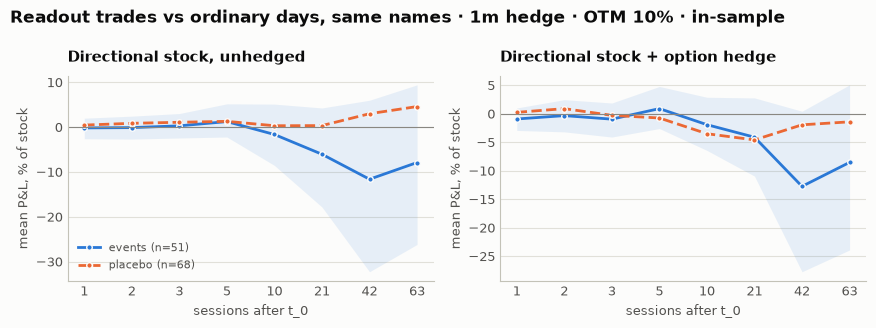


H* (in-sample peak of the hedged event-minus-placebo edge) = 5 sessions -> frozen as the time stop. Edge by horizon: h=1: -1.2%, h=2: -1.2%, h=3: -0.7%, h=5: +1.6%, h=10: +1.6%, h=21: +0.5%, h=42: -10.8%, h=63: -7.1%


In [14]:
def scoreboard(df: pd.DataFrame, strategies: list[str], horizons=None) -> pd.DataFrame:
    """Rows: strategy x horizon. Mean P&L per $1 of stock with n, a 95% bootstrap CI, the median and the hit rate."""
    horizons = horizons or [h for h in HORIZONS + ["exp"] if h in set(df.horizon)]
    rows = []
    for s in strategies:
        for h in horizons:
            x = df.loc[df.horizon == h, s].dropna()
            lo, hi = bootstrap_ci(x)
            rows.append({"strategy": s, "horizon": h, "n": len(x), "mean": x.mean(), "ci_lo": lo, "ci_hi": hi,
                         "median": x.median(), "hit_rate": (x > 0).mean()})
    return pd.DataFrame(rows)


def difference_board(a: pd.DataFrame, b: pd.DataFrame, strategies: list[str], seed: int = 1) -> pd.DataFrame:
    """Mean P&L of group a minus group b, per strategy and horizon, with a bootstrap CI on the difference."""
    rng, rows = np.random.default_rng(seed), []
    for s in strategies:
        for h in [h for h in HORIZONS + ["exp"] if h in set(a.horizon) & set(b.horizon)]:
            xa, xb = a.loc[a.horizon == h, s].dropna().to_numpy(), b.loc[b.horizon == h, s].dropna().to_numpy()
            row = {"strategy": s, "horizon": h, "n_a": len(xa), "n_b": len(xb)}
            if len(xa) >= 5 and len(xb) >= 5:
                d = rng.choice(xa, (2000, len(xa))).mean(1) - rng.choice(xb, (2000, len(xb))).mean(1)
                row.update(mean_a=xa.mean(), mean_b=xb.mean(), difference=xa.mean() - xb.mean(),
                           ci_lo=np.percentile(d, 2.5), ci_hi=np.percentile(d, 97.5))
            rows.append(row)
    return pd.DataFrame(rows)


def fmt_board(board: pd.DataFrame, value: str = "mean", order: list[str] | None = None, with_n: bool = False) -> pd.DataFrame:
    """Wide display table: strategies x horizons, values in % of spot, * where the 95% CI excludes zero."""
    def cell(row):
        v = row[value]
        if pd.isna(v):
            return ""
        star = "*" if pd.notna(row.get("ci_lo")) and (row["ci_lo"] > 0 or row["ci_hi"] < 0) else ""
        n = f" (n={int(row['n'])})" if with_n and "n" in row else ""
        return f"{v * 100:+.1f}%{star}{n}"
    wide = board.assign(cell=board.apply(cell, axis=1)).pivot(index="strategy", columns="horizon", values="cell")
    wide = wide.reindex([s for s in (order or list(dict.fromkeys(board.strategy))) if s in wide.index]).rename(index=lambda s: STRATEGY_LABEL.get(s, s))
    wide.columns = [f"h={c}" if c != "exp" else "expiry" for c in wide.columns]
    return wide.rename_axis("P&L per $1 stock", axis=0)


def plot_boards(boards: dict[str, pd.DataFrame], strategies: list[str], title: str, name: str | None = None, ncols: int = 3):
    """Small multiples: one panel per strategy, one line per group, band = 95% bootstrap CI of the first group."""
    horizons = [h for h in HORIZONS if any(h in set(b.horizon) for b in boards.values())]
    x = np.arange(len(horizons))
    nrows = int(np.ceil(len(strategies) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.3 * nrows), sharex=True, squeeze=False)
    for ax, s in zip(axes.ravel(), strategies):
        for i, (name_, b) in enumerate(boards.items()):
            t = b[b.strategy == s].set_index("horizon").reindex(horizons)
            c = SERIES.get(name_, INK2)
            if i == 0:
                ax.fill_between(x, t.ci_lo.to_numpy(float) * 100, t.ci_hi.to_numpy(float) * 100, color=c, alpha=0.10, linewidth=0)
            ax.plot(x, t["mean"].to_numpy(float) * 100, color=c, linewidth=2, marker="o", markersize=4, markeredgecolor=SURFACE,
                    linestyle="-" if i == 0 else "--", label=f"{name_} (n={int(t.n.max()) if t.n.notna().any() else 0})")
        ax.axhline(0, color=MUTED, linewidth=0.8)
        ax.set_xticks(x, [str(h) for h in horizons])
        style(ax, STRATEGY_LABEL.get(s, s), "sessions after t_0", "mean P&L, % of stock")
    for ax in axes.ravel()[len(strategies):]:
        ax.axis("off")
    axes[0, 0].legend(frameon=False, labelcolor=INK2, fontsize=8, loc="best")
    fig.suptitle(title, x=0.01, ha="left", color=INK, fontsize=12, fontweight="bold")
    finish(fig, name)


# ---- Signal layer: the bare stock, every gated event, with and without options --------------------------
def stock_book(sig: pd.DataFrame, direction: pd.Series | None = None, borrow_fee: float = BORROW_FEE) -> pd.DataFrame:
    """Long table of signed stock returns per (event, horizon) for the signal layer. `direction` defaults to the signal's."""
    d = sig.copy()
    if direction is not None:
        d["direction"] = d["event_id"].map(direction).fillna(0).astype(int)
    d = d[d.direction != 0]
    rows = []
    for h in HORIZONS:
        col = f"r_{h}"
        if col not in d:
            continue
        sub = d.dropna(subset=[col])
        days = [(shift_session(t, h) - t).days for t in sub.t_0]
        signed = sub.direction * sub[col] - np.where(sub.direction < 0, borrow_fee * np.array(days) / 365, 0)
        rows.append(pd.DataFrame({"event_id": sub.event_id, "ticker": sub.ticker, "t_0": sub.t_0, "horizon": h, "direction": sub.direction,
                                  "book": np.where(sub.direction > 0, "long", "short"), "size": sub["size"], "sentiment": sub.sentiment,
                                  "stock": sub[col], "signed": signed}))
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def sample_placebo(ev: pd.DataFrame, n: int, start: str, end: str, gap_days: int = PLACEBO_GAP_DAYS, seed: int = 7,
                   exclude: pd.DataFrame | None = None) -> pd.DataFrame:
    """Ordinary sessions for the same tickers, drawn in proportion to how often each ticker trades, at least `gap_days`
    from any of that filer's tagged 8-Ks (`exclude`, default: every event in `ev`). Each placebo 'event' is given a random
    direction with the book's long/short mix."""
    rng = np.random.default_rng(seed)
    sessions = CAL[(CAL >= pd.Timestamp(start)) & (CAL <= min(pd.Timestamp(end), LAST_SESSION))]
    by_ticker = (exclude if exclude is not None else ev).groupby("ticker")["filing_date"].apply(list)
    p_long = (ev.direction > 0).mean() if "direction" in ev else 0.5
    rows = []
    for i, t in enumerate(rng.choice(ev["ticker"].to_numpy(), size=n, replace=True)):
        for _ in range(40):
            d = sessions[rng.integers(len(sessions))]
            if all(abs((d - a).days) > gap_days for a in by_ticker.get(t, [])):
                rows.append({"event_id": f"placebo-{i}-{t}-{d:%Y%m%d}", "cik": "", "ticker": t, "filing_date": d, "event_date": d, "t_0": d,
                             "t_pre": session_before(d), "direction": 1 if rng.random() < p_long else -1, "sentiment": np.nan, "size": "placebo"})
                break
    return pd.DataFrame(rows)


SIGNAL_STRATS = ["signed"]
STRATEGY_LABEL["signed"] = "Signal layer: directional stock (unhedged)"
sig_book_is = stock_book(signal_is)
placebo_sig = sample_placebo(signal_is[signal_is.direction != 0], max(N_PLACEBO, 3 * int((signal_is.direction != 0).sum())), STUDY_START, STUDY_END, exclude=ev_is)
load_stock_bars(placebo_sig, "placebo")
placebo_sig = placebo_sig.merge(stock_returns(placebo_sig).drop(columns=["ticker", "t_pre", "t_0"]), on="event_id")
placebo_sig_book = stock_book(placebo_sig)

print(f"SIGNAL LAYER (stock only) · in-sample · {sig_book_is.event_id.nunique()} trades vs {placebo_sig_book.event_id.nunique()} placebo days with random direction. "
      f"Mean signed return per $1 stock; * = 95% bootstrap CI excludes zero.")
sig_boards = {"combined": scoreboard(sig_book_is, SIGNAL_STRATS), "long": scoreboard(sig_book_is[sig_book_is.book == "long"], SIGNAL_STRATS),
              "short": scoreboard(sig_book_is[sig_book_is.book == "short"], SIGNAL_STRATS), "placebo": scoreboard(placebo_sig_book, SIGNAL_STRATS)}
display(pd.concat({k: fmt_board(v, with_n=(k == "combined")) for k, v in sig_boards.items()}, names=["book"]).droplevel(1))
sig_diff = difference_board(sig_book_is, placebo_sig_book, SIGNAL_STRATS)
print("Events minus placebo (signal layer):")
display(fmt_board(sig_diff, "difference"))

# ---- Trade layer: stock + option hedge, events with a priced hedge ---------------------------------------
BOOK_STRATS = ["unhedged", "hedged"]
trade_is = hz.copy()
placebo_tr = placebo_sig.head(N_PLACEBO).copy()
placebo_priced, placebo_dropped = price_events(placebo_tr, label="placebo")
placebo_results = evaluate(placebo_priced)
placebo_book = book_pnl(placebo_results, placebo_tr.set_index("event_id")["direction"])
placebo_hz = placebo_book[(placebo_book.bucket == BASELINE_BUCKET) & (placebo_book.entry == ENTRY) & (placebo_book.otm == OTM_PCT)]
PRICED_BY_EVENT.update({(pe.event_id, pe.bucket): pe for pe in placebo_priced})

print(f"\nTRADE LAYER (stock + {BASELINE_BUCKET} hedge, OTM {OTM_PCT:.0%}) · in-sample · {trade_is.event_id.nunique()} trades vs "
      f"{placebo_hz.event_id.nunique()} placebo. Mean P&L per $1 stock; * = 95% CI excludes zero.")
tr_boards = {"combined": scoreboard(trade_is, BOOK_STRATS), "long": scoreboard(trade_is[trade_is.book == "long"], BOOK_STRATS),
             "short": scoreboard(trade_is[trade_is.book == "short"], BOOK_STRATS), "placebo": scoreboard(placebo_hz, BOOK_STRATS)}
display(pd.concat({k: fmt_board(v, with_n=(k == "combined")) for k, v in tr_boards.items()}, names=["book"]))
tr_diff = difference_board(trade_is, placebo_hz, BOOK_STRATS)
print("Events minus placebo (trade layer):")
display(fmt_board(tr_diff, "difference"))
plot_boards({"events": tr_boards["combined"], "placebo": tr_boards["placebo"]}, BOOK_STRATS,
            f"Readout trades vs ordinary days, same names · {BASELINE_BUCKET} hedge · OTM {OTM_PCT:.0%} · in-sample", "trade_layer_vs_placebo", ncols=2)

# ---- H*: the pre-registered time stop = horizon where the in-sample event-minus-placebo edge of the hedged book peaks
_edge = tr_diff[(tr_diff.strategy == "hedged") & tr_diff.horizon.isin(HORIZONS)].set_index("horizon")["difference"]
H_STAR = int(_edge.idxmax()) if _edge.notna().any() else 21
print(f"\nH* (in-sample peak of the hedged event-minus-placebo edge) = {H_STAR} sessions -> frozen as the time stop. "
      f"Edge by horizon: " + ", ".join(f"h={h}: {v * 100:+.1f}%" for h, v in _edge.items()))

### Controls, ranking, tails, the worst trades and the exit rules

- **Sign-shuffle**: the same events with a random direction; the actual rule's mean is placed in that distribution. If the
  direction came from Jev, the actual result should sit in the tail.
- **Momentum baseline**: follow the sign of `r0` with no Jev at all, on all directional readouts and on the traded events.
- **Stale readouts**: filings that re-present previously announced data, run through the same rule.
- **Ranking** the library strategies by their edge over placebo on each side of the book (`rank_strategies`).
- **Tails**: hedged vs unhedged mean, CI, hit rate, worst decile and worst trade, with the strike-implied max loss. The
  hedge buys the left tail, not the mean, and that is how it is judged.
- **The worst five trades**, with the passage of the filing that triggered each.
- **Exit rules**: time stop, catch-up, information, the combined rule, and hold-to-hedge-expiry, side by side.

In [15]:
# ---- Controls: the direction must come from Jev, not from the calendar or from the day-0 move ------------
def control_table(sig: pd.DataFrame, h: int, n_shuffle: int = 500, seed: int = 11) -> pd.DataFrame:
    """Signal-layer controls at horizon h: the actual rule, sign-shuffle (random direction per event), the momentum
    baseline (direction = sign of r0, no Jev), stale readouts (same rule, is_new below the gate), and the placebo."""
    rng = np.random.default_rng(seed)
    col = f"r_{h}"
    trades = sig[(sig.direction != 0)].dropna(subset=[col])
    actual = (trades.direction * trades[col]).mean()
    shuffled = np.array([(rng.choice([-1, 1], len(trades)) * trades[col].to_numpy()).mean() for _ in range(n_shuffle)])
    base = sig[sig.gate_readout & sig.gate_new & sig.gate_stock & sig.directional].dropna(subset=[col, "r0"])
    mom_dir = np.sign(base.r0).replace(0, 1)
    momentum = (mom_dir * base[col])
    mom_on_trades = (np.sign(trades.r0).replace(0, 1) * trades[col])
    stale = build_signal(sig.assign(is_new=1.0), panel, BETA, IM_PROXY)          # same rule with the is_new gate removed ...
    stale = stale[(stale.direction != 0) & (sig.is_new < NEW_GATE) & sig.gate_readout].dropna(subset=[col])   # ... keeping only the stale ones
    stale_ret = stale.direction * stale[col]
    plc = placebo_sig.dropna(subset=[col])
    plc_ret = plc.direction * plc[col]
    rows = [
        {"control": "Jev rule (actual)", "n": len(trades), "mean": actual, "ci": bootstrap_ci(trades.direction * trades[col])},
        {"control": "Sign-shuffle: random direction, same events", "n": len(trades), "mean": shuffled.mean(),
         "ci": tuple(np.percentile(shuffled, [2.5, 97.5])), "p_actual": float((shuffled >= actual).mean())},
        {"control": "Momentum baseline: follow sign(r0), no Jev (all directional readouts)", "n": len(base), "mean": momentum.mean(), "ci": bootstrap_ci(momentum)},
        {"control": "Momentum baseline on the same traded events", "n": len(trades), "mean": mom_on_trades.mean(), "ci": bootstrap_ci(mom_on_trades)},
        {"control": "Stale readouts (previously announced data), same rule", "n": len(stale), "mean": stale_ret.mean(), "ci": bootstrap_ci(stale_ret)},
        {"control": "Placebo: random non-event days, random direction", "n": len(plc), "mean": plc_ret.mean(), "ci": bootstrap_ci(plc_ret)},
    ]
    out = pd.DataFrame(rows)
    out["mean"] = out["mean"].map(lambda v: f"{v * 100:+.1f}%")
    out["95% CI"] = out["ci"].map(lambda c: f"[{c[0] * 100:+.1f}%, {c[1] * 100:+.1f}%]" if pd.notna(c[0]) else "")
    out["share of random-direction draws that beat the rule"] = out.get("p_actual", pd.Series(dtype=float)).map(lambda v: f"{v:.3f}" if pd.notna(v) else "")
    return out.drop(columns=["ci", "p_actual"], errors="ignore").set_index("control")


print(f"Controls at h={H_STAR} (signal layer, signed stock return per $1):")
display(control_table(signal_is, H_STAR))
print(f"Controls at h=21:")
display(control_table(signal_is, 21))

# ---- Ranking the library hedges: which option strategy earns the most edge over ordinary days? ------------
def rank_strategies(diff: pd.DataFrame, horizons=(5, 10, 21)) -> pd.DataFrame:
    d = diff[diff.horizon.isin(horizons)]
    out = (d.groupby("strategy").agg(edge=("difference", "mean"),
                                     horizons_ci_excludes_0=("ci_lo", lambda s: int(((s > 0) | (d.loc[s.index, "ci_hi"] < 0)).sum())),
                                     n_events=("n_a", "max")).sort_values("edge", ascending=False))
    out["edge"] = out["edge"].map(lambda v: f"{v * 100:+.2f}%")
    return out.rename(index=STRATEGY_LABEL)


long_diff = difference_board(trade_is[trade_is.book == "long"], placebo_hz[placebo_hz.book == "long"], LONG_STRATEGIES)
short_diff = difference_board(trade_is[trade_is.book == "short"], placebo_hz[placebo_hz.book == "short"], SHORT_STRATEGIES)
print("Long book: event-minus-placebo edge by library strategy, averaged over h=5,10,21:")
display(rank_strategies(long_diff))
print("Short book:")
display(rank_strategies(short_diff))
WINNER_LONG = rank_strategies(long_diff).index[0]
WINNER_SHORT = rank_strategies(short_diff).index[0]
print("Long book, every horizon (events minus placebo):")
display(fmt_board(long_diff, "difference", LONG_STRATEGIES))
print("Short book, every horizon (events minus placebo):")
display(fmt_board(short_diff, "difference", SHORT_STRATEGIES))


# ---- Hedge value: tails, not means ---------------------------------------------------------------------
def tail_table(df: pd.DataFrame, h, cols=("unhedged", "hedged")) -> pd.DataFrame:
    rows = []
    for book, g in [("combined", df), ("long", df[df.book == "long"]), ("short", df[df.book == "short"])]:
        g = g[g.horizon == h]
        for c in cols:
            x = g[c].dropna()
            if len(x) < 5:
                continue
            lo, hi = bootstrap_ci(x)
            rows.append({"book": book, "strategy": STRATEGY_LABEL[c], "n": len(x), "mean": x.mean(), "ci_lo": lo, "ci_hi": hi, "median": x.median(),
                         "hit_rate": (x > 0).mean(), "worst_decile_mean": x[x <= x.quantile(0.1)].mean(), "worst": x.min(),
                         "max_loss_by_strike (median)": g.loc[x.index, "max_loss"].median() if c == "hedged" else np.nan})
    t = pd.DataFrame(rows).set_index(["book", "strategy"])
    for c in ["mean", "ci_lo", "ci_hi", "median", "worst_decile_mean", "worst", "max_loss_by_strike (median)"]:
        t[c] = t[c].map(lambda v: f"{v * 100:+.1f}%" if pd.notna(v) else "")
    t["hit_rate"] = t["hit_rate"].map("{:.0%}".format)
    return t


print(f"Hedged vs unhedged at h={H_STAR}: the option buys the left tail, not the mean.")
display(tail_table(trade_is, H_STAR))

# ---- The worst five trades, with the filing behind each -------------------------------------------------
worst = (trade_is[trade_is.horizon == H_STAR].nsmallest(5, "hedged")
         .merge(ev_is[["event_id", "supporting_text", "size", "outcome_score", "program_action", "safety_signal"]], on="event_id"))
print(f"Worst five hedged trades at h={H_STAR}:")
with pd.option_context("display.max_colwidth", 160):
    display(worst.assign(**{c: lambda d, c=c: d[c].map("{:+.1%}".format) for c in ["realized", "hedged", "unhedged", "hedge_cost"]})
            [["ticker", "t_0", "book", "size", "outcome_score", "program_action", "realized", "unhedged", "hedged", "hedge_cost", "supporting_text"]])

# ---- Exit rules: time stop vs the pre-registered rule (catch-up / information / time) vs hold to hedge expiry --
trades_full = trades_is.merge(signal_is[["event_id"]], on="event_id")
exit_rows = {}
for rule in ("time", "catchup", "info", "rule"):
    rp = rule_pnl(PRICED_BY_EVENT, trades_is, rule, H_STAR)
    if len(rp):
        exit_rows[rule] = rp
exp_rows = trade_is[trade_is.horizon == "exp"].copy()
exit_cmp = pd.DataFrame({
    **{f"{rule} exit": {"n": len(rp), "mean hedged": rp.hedged.mean(), "ci": bootstrap_ci(rp.hedged), "median hedged": rp.hedged.median(),
                        "hit rate": (rp.hedged > 0).mean(), "mean sessions held": rp.sessions_held.mean(), "mean unhedged": rp.unhedged.mean()}
       for rule, rp in exit_rows.items()},
    "hold to hedge expiry": {"n": len(exp_rows), "mean hedged": exp_rows.hedged.mean(), "ci": bootstrap_ci(exp_rows.hedged), "median hedged": exp_rows.hedged.median(),
                             "hit rate": (exp_rows.hedged > 0).mean(), "mean sessions held": exp_rows.sessions_held.mean(), "mean unhedged": exp_rows.unhedged.mean()},
}).T
for c in ["mean hedged", "median hedged", "mean unhedged"]:
    exit_cmp[c] = exit_cmp[c].map(lambda v: f"{v * 100:+.1f}%")
exit_cmp["ci"] = exit_cmp["ci"].map(lambda c: f"[{c[0] * 100:+.1f}%, {c[1] * 100:+.1f}%]" if pd.notna(c[0]) else "")
exit_cmp["hit rate"] = exit_cmp["hit rate"].map("{:.0%}".format)
exit_cmp["mean sessions held"] = exit_cmp["mean sessions held"].map("{:.1f}".format)
print(f"Exit rules (time stop H*={H_STAR}; 'rule' = earliest of time stop, catch-up exit when the gap has closed, and the next 8-K from the same filer):")
display(exit_cmp)

Controls at h=5 (signal layer, signed stock return per $1):


,n,mean,95% CI,share of random-direction draws that beat the rule
control,,,,
Jev rule (actual),94,-1.1%,"[-4.1%, +1.9%]",
"Sign-shuffle: random direction, same events",94,+0.0%,"[-2.7%, +3.2%]",0.770
"Momentum baseline: follow sign(r0), no Jev (all directional readouts)",214,+1.6%,"[-0.6%, +3.9%]",
Momentum baseline on the same traded events,94,+0.9%,"[-2.0%, +3.9%]",
"Stale readouts (previously announced data), same rule",70,+1.5%,"[-4.3%, +8.2%]",
"Placebo: random non-event days, random direction",269,+0.0%,"[-1.2%, +1.2%]",


Controls at h=21:


,n,mean,95% CI,share of random-direction draws that beat the rule
control,,,,
Jev rule (actual),94,-4.9%,"[-12.0%, +1.7%]",
"Sign-shuffle: random direction, same events",94,-0.1%,"[-6.4%, +6.6%]",0.890
"Momentum baseline: follow sign(r0), no Jev (all directional readouts)",214,+1.8%,"[-2.3%, +5.7%]",
Momentum baseline on the same traded events,94,-1.1%,"[-8.2%, +5.1%]",
"Stale readouts (previously announced data), same rule",70,-0.1%,"[-9.9%, +8.8%]",
"Placebo: random non-event days, random direction",269,+1.0%,"[-1.7%, +3.7%]",


Long book: event-minus-placebo edge by library strategy, averaged over h=5,10,21:


...

n   mean   ci_lo  ci_hi median  \
book     strategy                                                            
combined Directional stock, unhedged       51  +1.2%   -2.2%  +5.2%  -1.2%   
         Directional stock + option hedge  40  +0.9%   -2.6%  +4.8%  -1.8%   
long     Directional stock, unhedged       44  +1.8%   -2.2%  +5.9%  -1.1%   
         Directional stock + option hedge  33  +1.8%   -1.6%  +5.6%  -1.6%   
short    Directional stock, unhedged        7  -2.0%   -9.3%  +7.8%  -5.8%   
         Directional stock + option hedge   7  -3.4%  -12.2%  +7.9%  -9.1%   

                                          hit_rate worst_decile_mean   worst  \
book     strategy                                                              
combined Directional stock, unhedged           41%            -15.7%  -28.7%   
         Directional stock + option hedge      40%            -13.6%  -17.8%   
long     Directional stock, unhedged           43%            -16.2%  -28.7%   
         Directional stock + option hedge      42%             -8.5%  -10.2%   
short    Directional stock, unhedged           29%            -13.5%  -13.5%   
         Directional stock + option hedge      29%            -17.8%  -17.8%   

                                          max_loss_by_strike (median)  
book     strategy                                                      
combined Directional stock, unhedged                                   
         Directional stock + option hedge                      +18.2%  
long     Directional stock, unhedged                                   
         Directional stock + option hedge                      +15.3%  
short    Directional stock, unhedged                                   
         Directional stock + option hedge                      +24.5%

Worst five hedged trades at h=5:


,ticker,t_0,book,size,outcome_score,program_action,realized,unhedged,hedged,hedge_cost,supporting_text
0,CTNM,2025-11-21,short,small,0.05,continue,+0.4%,-1.1%,-17.8%,+24.2%,"On November 20, 2025, Contineum Therapeutics, Inc. issued a press release in which it reported topline data from its Phase 2 PIPE-307 VISTA trial for the tr..."
1,SAGE,2024-11-20,short,small,0.00,discontinue,+13.0%,-13.5%,-13.5%,+3.6%,"Sage Therapeutics, Inc. issued a press release titled ""Sage Therapeutics Announces Topline Results from the Phase 2 DIMENSION Study of Dalzanemdor (SAGE-718..."
2,GTHX,2024-06-24,short,micro,0.09,discontinue,+11.3%,-11.7%,-12.9%,+13.5%,"the pivotal Phase 3 trial (PRESERVE 2), evaluating trilaciclib in combination with gemcitabine and carboplatin for the first line treatment of metastatic tr..."
3,RVPH,2024-12-16,long,micro,3.58,advance,-28.7%,-28.7%,-10.2%,+12.0%,"On December 16, 2024, the Company announced positive preliminary topline data from its OLE evaluating the long-term safety and tolerability of brilaroxazine..."
4,SAGE,2024-10-08,short,small,0.00,discontinue,+6.7%,-7.2%,-9.1%,+7.4%,Sage Therapeutics Announces Topline Results from the Phase 2 LIGHTWAVE Study of Dalzanemdor (SAGE-718) in the Treatment of Mild Cognitive Impairment and Mil...


Exit rules (time stop H*=5; 'rule' = earliest of time stop, catch-up exit when the gap has closed, and the next 8-K from the same filer):


,n,mean hedged,ci,median hedged,hit rate,mean sessions held,mean unhedged
time exit,51,+0.9%,"[-2.6%, +4.8%]",-1.8%,31%,5.0,+1.2%
catchup exit,51,+0.9%,"[-2.6%, +4.8%]",-1.8%,31%,4.9,+1.3%
info exit,51,+0.1%,"[-3.6%, +4.3%]",-1.7%,29%,4.4,+0.3%
rule exit,51,+0.1%,"[-3.6%, +4.3%]",-1.7%,29%,4.4,+0.4%
hold to hedge expiry,51,-5.1%,"[-10.7%, +0.8%]",-10.0%,29%,20.2,-6.1%


### Calendar-time portfolio

Every trade holds $1 of stock (plus its hedge) from the `t_0` close to its exit, marked daily; the book's daily P&L is
summed and divided by the capital needed to carry the busiest day unlevered. Annualised return, volatility, Sharpe with a
21-day block-bootstrap interval (readouts cluster around ASCO, ASH and the like), max drawdown, concurrency.

Calendar-time portfolio, trade layer, $1 of stock per trade, 1m hedge, exit at H*=5:


,time stop,rule exit
label,in-sample,"in-sample, rule exit"
trades,44,44
days,482,479
avg concurrent positions,0.46,0.41
max concurrent positions,3,2
capital (units of $1 trades),3,2
avg gross exposure (share of capital),15.2%,20.4%
annualised return on capital,2.2%,-4.1%
annualised vol,21.1%,30.3%
Sharpe,0.11,-0.14


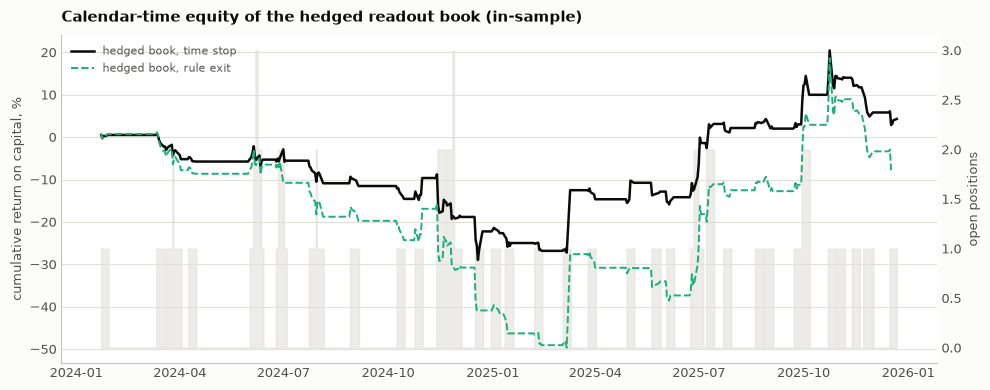

In [16]:
def trade_path(pe: PricedEvent, direction: int, exit_day, otm: float = OTM_PCT, borrow_fee: float = BORROW_FEE) -> pd.Series:
    """Daily cumulative P&L per $1 of stock from t_0 to `exit_day` for one hedged trade (stock + option, marks carried forward)."""
    days = CAL[(CAL > pe.t_0) & (CAL <= min(exit_day, LAST_SESSION))]
    pk, ck = f"P_L{otm}", f"C_U{otm}"
    S_e = pe.stock(pe.t_0)
    key = pk if direction > 0 else ck
    m_e = pe.mark(key, pe.t_0)
    if not (S_e > 0) or np.isnan(m_e):
        return pd.Series(dtype=float)
    out, last_m = {}, m_e
    for d in days:
        m = pe.mark(key, d)
        last_m = m if not np.isnan(m) else last_m
        stock = direction * (pe.stock(d) / S_e - 1) - (borrow_fee * (d - pe.t_0).days / 365 if direction < 0 else 0)
        out[d] = stock + (last_m - m_e) / S_e
    return pd.Series(out)


def portfolio(trades: pd.DataFrame, h_star: int, rule: str = "time", label: str = "in-sample") -> dict:
    """Calendar-time book: $1 of stock per trade, every trade held from the t_0 close to its exit, daily mark-to-market."""
    paths = []
    for r in trades.itertuples(index=False):
        pe = PRICED_BY_EVENT.get((r.event_id, BASELINE_BUCKET))
        if pe is None:
            continue
        p = trade_path(pe, r.direction, exit_session(r, rule, h_star))
        if len(p):
            paths.append(p.diff().fillna(p.iloc[0]).rename(r.event_id))
    if not paths:
        return {}
    daily = pd.concat(paths, axis=1)
    pnl = daily.sum(axis=1)
    open_pos = daily.notna().sum(axis=1)
    full = CAL[(CAL >= pnl.index.min()) & (CAL <= pnl.index.max())]
    pnl, open_pos = pnl.reindex(full, fill_value=0.0), open_pos.reindex(full, fill_value=0)
    gross = open_pos.mean()
    capital = max(int(open_pos.max()), 1)           # enough capital to carry the busiest day unlevered
    ret = pnl / capital
    sharpe = ret.mean() / ret.std() * np.sqrt(252) if ret.std() > 0 else np.nan
    eq = ret.cumsum()
    dd = (eq - eq.cummax()).min()
    rng, block, boots = np.random.default_rng(3), 21, []
    for _ in range(1000):
        idx = np.concatenate([np.arange(s, s + block) for s in rng.integers(0, len(ret) - block, len(ret) // block + 1)])[: len(ret)]
        b = ret.to_numpy()[idx]
        boots.append(b.mean() / b.std() * np.sqrt(252) if b.std() > 0 else np.nan)
    return {"label": label, "trades": len(paths), "days": len(ret), "avg concurrent positions": gross, "max concurrent positions": int(open_pos.max()),
            "capital (units of $1 trades)": capital, "avg gross exposure (share of capital)": gross / capital,
            "annualised return on capital": ret.mean() * 252, "annualised vol": ret.std() * np.sqrt(252), "Sharpe": sharpe,
            "Sharpe 95% CI (21-day block bootstrap)": tuple(np.nanpercentile(boots, [2.5, 97.5])), "max drawdown (of capital)": dd,
            "share of days with a position": (open_pos > 0).mean(), "equity": eq, "open": open_pos}


port_is = portfolio(trades_is, H_STAR, "time", "in-sample")
port_is_rule = portfolio(trades_is, H_STAR, "rule", "in-sample, rule exit")
summ = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk not in ("equity", "open")} for k, v in [("time stop", port_is), ("rule exit", port_is_rule)]})
for c in summ.columns:
    for k in ["annualised return on capital", "annualised vol", "max drawdown (of capital)", "share of days with a position", "avg gross exposure (share of capital)"]:
        summ.loc[k, c] = f"{summ.loc[k, c] * 100:.1f}%"
    summ.loc["Sharpe", c] = f"{summ.loc['Sharpe', c]:.2f}"
    summ.loc["Sharpe 95% CI (21-day block bootstrap)", c] = f"[{summ.loc['Sharpe 95% CI (21-day block bootstrap)', c][0]:.2f}, {summ.loc['Sharpe 95% CI (21-day block bootstrap)', c][1]:.2f}]"
    summ.loc["avg concurrent positions", c] = f"{summ.loc['avg concurrent positions', c]:.2f}"
print(f"Calendar-time portfolio, trade layer, $1 of stock per trade, {BASELINE_BUCKET} hedge, exit at H*={H_STAR}:")
display(summ)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(port_is["equity"].index, port_is["equity"].to_numpy() * 100, color=SERIES["combined"], linewidth=1.8, label="hedged book, time stop")
ax.plot(port_is_rule["equity"].index, port_is_rule["equity"].to_numpy() * 100, color=SERIES["oos"], linewidth=1.4, linestyle="--", label="hedged book, rule exit")
ax2 = ax.twinx()
ax2.fill_between(port_is["open"].index, 0, port_is["open"].to_numpy(), color=GRID, alpha=0.6, step="mid", label="open positions")
ax2.set_ylabel("open positions", color=INK2, fontsize=9)
ax2.tick_params(colors=INK2, labelsize=9, length=0)
for s in ("top", "right", "left", "bottom"):
    ax2.spines[s].set_visible(False)
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)
style(ax, "Calendar-time equity of the hedged readout book (in-sample)", "", "cumulative return on capital, %")
ax.legend(frameon=False, labelcolor=INK2, fontsize=8, loc="upper left")
finish(fig, "portfolio_equity")

## 10 · Does the 8-K lead the market?

Three pieces of evidence from the minute bars. **When** the 8-K is accepted (pre-market, intraday, after the close) and
whether the press release came out on an earlier session. **The stock path around the acceptance minute**, from two hours
before to the close, relative to the pre-news close, for positive and negative readouts: a jump *before* acceptance means
the press release beat the 8-K; a jump *at* acceptance means the 8-K is the news. Each event is classified by how much of
its `t_pre → t_0` move had happened before acceptance. And the **tradeable share**: how much of the `t_pre → t_h` move
came after the `t_0` close, which is all an 8-K trader can take.

Acceptance slot of the 8-K x how many sessions before the 8-K session the news session (press-release date) was. An after-close 8-K whose press release came out the same day has a one-session lag by construction (t_0 is the next session):


pr_lag_sessions,news session 1 before,news session 2+ before,news session = 8-K session,All
accept_slot,,,,
after-close,278,32,0,310
intraday,1,4,39,44
pre-market,40,7,739,786
All,319,43,778,1140


  minute bars: 100/164, 0s



164 directional new readouts accepted pre-market or intraday with minute bars:


,events,share
who_moved_first,,
"<25% of the move printed before acceptance (8-K first, or a PR minutes earlier with no pre-market prints)",68,41%
>75% before acceptance (press release first),54,33%
25-75% before acceptance,36,22%
no move (|r0| <= 1%),6,4%


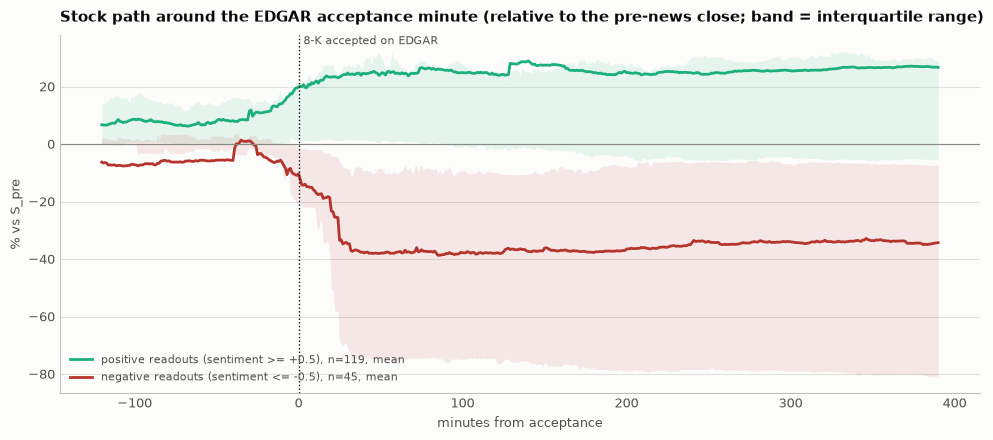

,n (|total move| > 5%),median share of the t_pre->t_h move that came after the t_0 close,share of events where the post-entry move continued in the same direction
h=5,481,27%,73%
h=21,510,53%,80%


In [17]:
# ---- Acceptance time: when does the 8-K hit EDGAR? -------------------------------------------------------
slot = pd.crosstab(ev_is.accept_slot, ev_is.pr_lag_sessions.clip(upper=2).map({0: "news session = 8-K session", 1: "news session 1 before", 2: "news session 2+ before"}), margins=True)
print("Acceptance slot of the 8-K x how many sessions before the 8-K session the news session (press-release date) was. "
      "An after-close 8-K whose press release came out the same day has a one-session lag by construction (t_0 is the next session):")
display(slot)

# ---- Minute event study around the acceptance minute ----------------------------------------------------
def minute_path(row, before: int = 120, after: int = 390) -> pd.Series | None:
    """Stock price relative to S_pre, minute by minute around the EDGAR acceptance minute (pre-market trades included)."""
    if pd.isna(row.accepted_at) or not (row.S_pre_adj > 0):
        return None
    acc = row.accepted_at.floor("min")
    bars = minute_bars(row.ticker, acc.normalize())
    if bars.empty:
        return None
    idx = pd.date_range(acc - pd.Timedelta(minutes=before), acc + pd.Timedelta(minutes=after), freq="min")
    px = bars["close"].reindex(bars.index.union(idx)).ffill().reindex(idx)
    if px.notna().sum() < 30:
        return None
    rel = px / row.S_pre_adj - 1
    rel.index = ((idx - acc).total_seconds() // 60).astype(int)
    return rel


study = ev_is[(ev_is.is_readout >= READOUT_GATE) & (ev_is.is_new >= NEW_GATE) & ev_is.has_stock & (ev_is.sentiment.abs() >= SENT_THRESHOLD)
              & ev_is.accept_slot.isin(["pre-market", "intraday"])].copy()
paths = parallel_map(lambda r: minute_path(r), list(study.itertuples(index=False)), label="minute bars", every=100)
study["minute_path"] = paths
study = study[study.minute_path.notna()]
before_acc = study.minute_path.map(lambda p: p.loc[:-1].dropna().iloc[-1] if p.loc[:-1].notna().any() else 0.0)
study["move_before_8k"] = before_acc.to_numpy()
study["move_total"] = study.r0
share = (study.move_before_8k / study.move_total.where(study.move_total.abs() > 0.01)).clip(-1, 2)
study["who_moved_first"] = pd.cut(share.abs(), [-0.01, 0.25, 0.75, np.inf], labels=["<25% of the move printed before acceptance (8-K first, or a PR minutes earlier with no pre-market prints)",
                                                                                     "25-75% before acceptance", ">75% before acceptance (press release first)"]).astype(object)
study.loc[study.move_total.abs() <= 0.01, "who_moved_first"] = "no move (|r0| <= 1%)"
print(f"\n{len(study)} directional new readouts accepted pre-market or intraday with minute bars:")
display(study.who_moved_first.value_counts().rename("events").to_frame().assign(share=lambda d: (d.events / d.events.sum()).map("{:.0%}".format)))

fig, ax = plt.subplots(figsize=(10, 4.5))
for lab, grp, c in [("positive readouts (sentiment >= +0.5)", study[study.sentiment >= SENT_THRESHOLD], SERIES["positive"]),
                    ("negative readouts (sentiment <= -0.5)", study[study.sentiment <= -SENT_THRESHOLD], SERIES["negative"])]:
    if len(grp) < 5:
        continue
    M = pd.concat(list(grp.minute_path), axis=1)
    mean, lo, hi = M.mean(axis=1), M.quantile(0.25, axis=1), M.quantile(0.75, axis=1)
    ax.plot(mean.index, mean * 100, color=c, linewidth=2, label=f"{lab}, n={len(grp)}, mean")
    ax.fill_between(mean.index, lo * 100, hi * 100, color=c, alpha=0.10, linewidth=0)
ax.axvline(0, color=INK, linewidth=1, linestyle=":")
ax.text(3, ax.get_ylim()[1] * 0.92, "8-K accepted on EDGAR", color=INK2, fontsize=8)
ax.axhline(0, color=MUTED, linewidth=0.8)
style(ax, "Stock path around the EDGAR acceptance minute (relative to the pre-news close; band = interquartile range)", "minutes from acceptance", "% vs S_pre")
ax.legend(frameon=False, labelcolor=INK2, fontsize=8, loc="lower left")
finish(fig, "minute_event_study")

# ---- Tradeable share of the move: what is left after the t_0 close? -----------------------------------
tr_share = {}
for h in (5, 21):
    col = f"r_{h}"
    g = readouts_new.dropna(subset=[col, "r0"])
    S_h = (1 + g.r0) * (1 + g[col])          # S_h / S_pre
    total, after = S_h - 1, S_h - (1 + g.r0)
    big = total.abs() > 0.05
    tr_share[f"h={h}"] = {"n (|total move| > 5%)": int(big.sum()),
                          "median share of the t_pre->t_h move that came after the t_0 close": float((after[big] / total[big]).median()),
                          "share of events where the post-entry move continued in the same direction": float((np.sign(after[big]) == np.sign(total[big])).mean())}
tbl = pd.DataFrame(tr_share).T
tbl_fmt = tbl.astype(object)
for c in tbl.columns[1:]:
    tbl_fmt[c] = tbl[c].map("{:.0%}".format)
tbl_fmt[tbl.columns[0]] = tbl[tbl.columns[0]].astype(int)
display(tbl_fmt)

## 11 · Classifier → market, and the concentration dose-response

The core figure: the **average cumulative stock path from the pre-news close to 63 sessions after entry, by Jev
sentiment**, with bootstrap bands, then the same for the two books the rule actually trades. Then the dose-response:
the market's day-0 response to sentiment by size bucket (the slope should fall with market cap), by phase, by lead-asset
status, and for stale readouts (the placebo arm).

Big-pharma resilience is tested two ways. **Disclosure**: how many `clinical_trial_results` 8-Ks the twelve largest US
biopharmas filed in the window (a readout is 8-K-material only to a concentrated company). **Partner reaction**: for
readouts naming a big-pharma partner, the partner's day-0 return next to the biotech's — same news, same day, two very
different exposures.

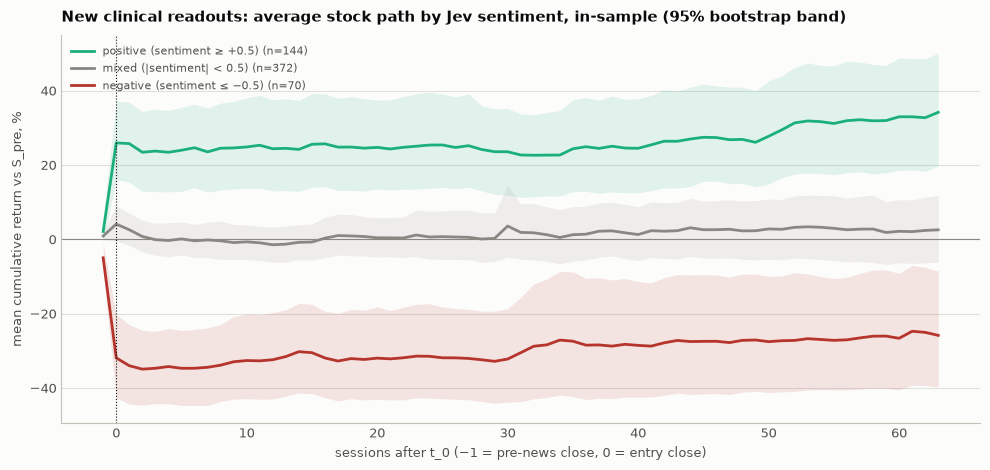

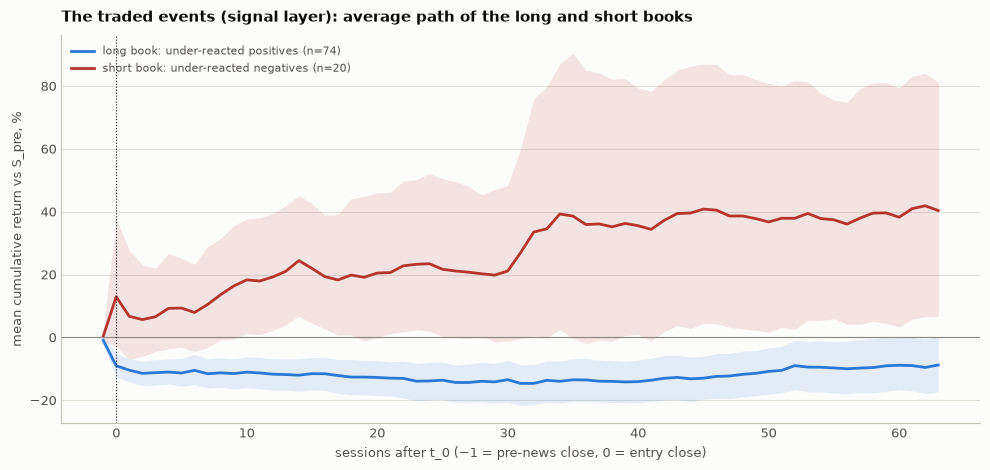

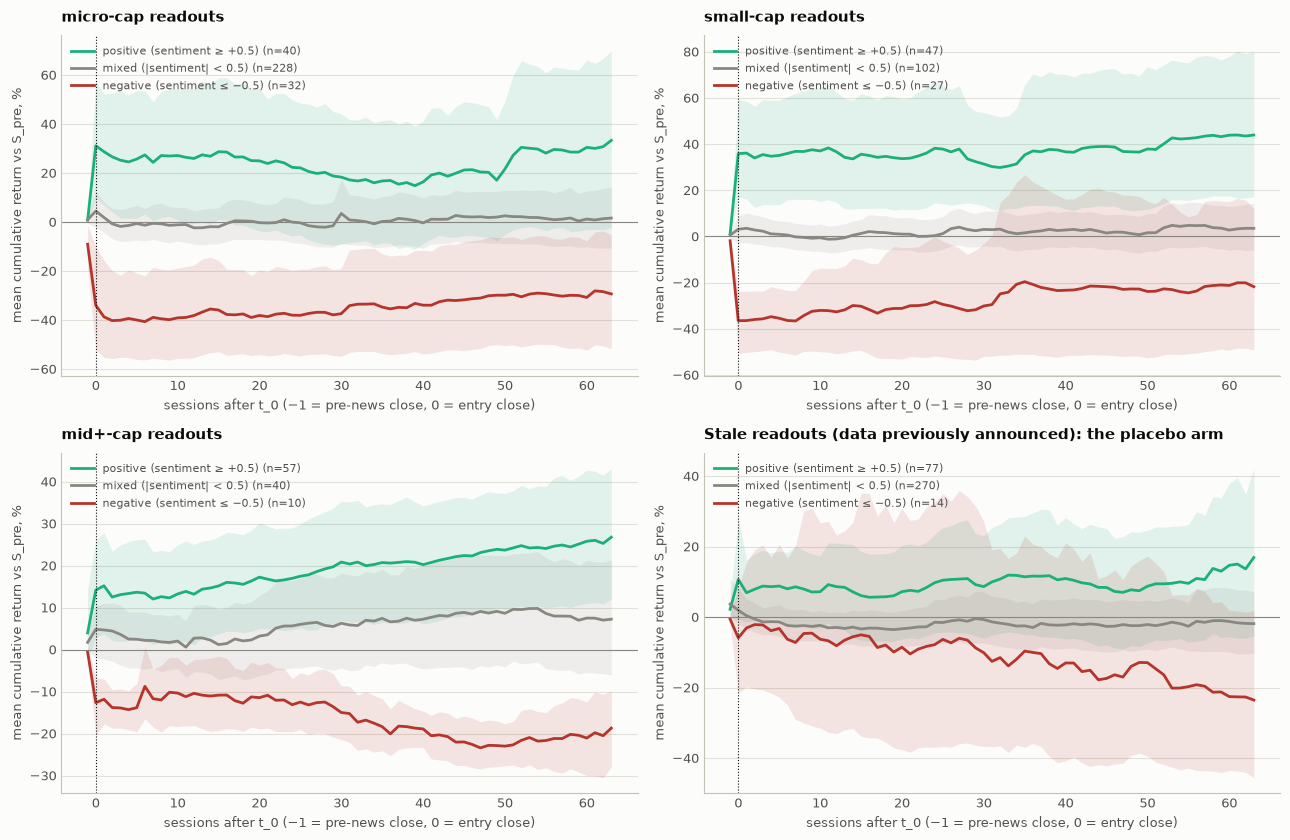

Dose-response: the market's day-0 response to Jev's sentiment, by group (slope = OLS of r0 on sentiment):


,n,slope of r0 on sentiment,slope 95% CI,Spearman,median |r0|,mean r0 | positive,mean r0 | negative,mean r_21 | positive,mean r_21 | negative
group,,,,,,,,,
micro,300,0.41,"[0.23, 0.61]",0.26,13.7%,+31.1%,-34.0%,-6.9%,-7.0%
mid+,107,0.16,"[0.08, 0.27]",0.26,9.7%,+14.2%,-12.6%,+3.5%,+2.6%
small,176,0.38,"[0.28, 0.50]",0.56,14.6%,+35.9%,-36.5%,-1.1%,+6.3%
all new readouts,586,0.34,"[0.26, 0.43]",0.38,13.0%,+26.0%,-31.9%,-0.9%,-1.7%
stale readouts,361,0.14,"[-0.04, 0.39]",0.05,6.4%,+10.7%,-5.9%,-0.9%,-6.9%
other_or_unclear,17,0.08,"[-0.14, 0.36]",0.33,9.1%,-2.0%,-10.0%,-18.0%,-14.9%
phase_1,149,0.32,"[-0.07, 0.54]",0.12,10.2%,+5.3%,-47.4%,+11.4%,-5.1%
phase_2,285,0.31,"[0.21, 0.40]",0.35,14.2%,+23.9%,-26.9%,-3.3%,+0.2%
phase_3_or_pivotal,135,0.37,"[0.23, 0.51]",0.58,18.5%,+28.6%,-36.7%,+0.8%,-3.2%


Readout 8-Ks filed in 2024-2025 by the twelve largest US biopharmas: LLY: 0, JNJ: 0, MRK: 0, PFE: 0, ABBV: 1, AMGN: 0, BMY: 0, GILD: 0, REGN: 0, VRTX: 0, BIIB: 0, MRNA: 0
Universe filers by size bucket:


,filers,filings per filer,median per filer
size,,,
micro,250,2.46,2.0
mid+,62,2.79,2.0
small,158,2.06,2.0
unknown,12,2.33,1.0



Partnered readouts with both stocks priced: 34 (directional: 13). Same news, same day:


,mean,50%,75%
biotech |r0|,29.2%,14.0%,43.6%
partner |r0|,1.8%,1.5%,2.5%


Signed, directional only: biotech mean r0 x sign(sentiment) = +40.5%, partner = +1.0%; ratio of median absolute moves = 9x.


,event_id,biotech,partner,t_0,sentiment,biotech_r0,partner_r0,size
7,0001193125-24-175915,HLVX,TAK,2024-07-08,-1.000,-88.3%,-0.2%,small
19,0001193125-25-061872,MURA,MRK,2025-03-25,-1.000,-61.6%,-4.8%,micro
10,0001193125-24-217822,FULC,GSK,2024-09-12,-1.000,-61.1%,-1.5%,small
18,0001655759-25-000057,ARVN,PFE,2025-03-11,0.320,-52.7%,-2.4%,small
1,0001193125-24-084937,IRON,RHHBY,2024-04-03,0.485,-51.0%,-1.9%,small
14,0000950170-24-129238,PYXS,MRK,2024-11-21,0.200,-49.5%,+3.4%,micro


In [18]:
# ---- The core figure: average cumulative stock path by sentiment group -----------------------------------
def cum_paths(ev: pd.DataFrame, max_h: int = 63) -> pd.DataFrame:
    """Matrix (events x sessions -1..max_h) of S_t / S_pre - 1 from adjusted closes; session -1 = t_pre."""
    mats = []
    for r in ev.itertuples(index=False):
        b = STOCK_BARS.get((r.ticker, True))
        if b is None or r.t_pre not in b.index or r.t_0 not in b.index:
            continue
        i0 = CAL.get_loc(r.t_0)
        days = CAL[i0 - 1: min(i0 + max_h + 1, len(CAL))]
        days = days[days <= LAST_SESSION]
        s = b["close"].reindex(days).ffill() / b.loc[r.t_pre, "close"] - 1
        s.index = range(-1, len(days) - 1)
        mats.append(s.rename(r.event_id))
    return pd.concat(mats, axis=1) if mats else pd.DataFrame()


def plot_paths(groups: dict[str, pd.DataFrame], title: str, name: str | None = None, ax=None, n_boot: int = 500):
    own = ax is None
    if own:
        fig, ax = plt.subplots(figsize=(10, 4.8))
    rng = np.random.default_rng(0)
    for lab, M in groups.items():
        if M.shape[1] < 5:
            continue
        mean = M.mean(axis=1)
        boots = np.array([M.iloc[:, rng.integers(0, M.shape[1], M.shape[1])].mean(axis=1).to_numpy() for _ in range(n_boot)])
        lo, hi = np.nanpercentile(boots, 2.5, axis=0), np.nanpercentile(boots, 97.5, axis=0)
        c = SERIES.get(lab.split()[0], INK2)
        ax.plot(mean.index, mean * 100, color=c, linewidth=2, label=f"{lab} (n={M.shape[1]})")
        ax.fill_between(mean.index, lo * 100, hi * 100, color=c, alpha=0.12, linewidth=0)
    ax.axhline(0, color=MUTED, linewidth=0.8)
    ax.axvline(0, color=INK, linewidth=0.8, linestyle=":")
    style(ax, title, "sessions after t_0 (−1 = pre-news close, 0 = entry close)", "mean cumulative return vs S_pre, %")
    ax.legend(frameon=False, labelcolor=INK2, fontsize=8, loc="upper left")
    if own:
        finish(ax.figure, name)


def sentiment_groups(ev: pd.DataFrame) -> dict[str, pd.DataFrame]:
    return {"positive (sentiment ≥ +0.5)": cum_paths(ev[ev.sentiment >= SENT_THRESHOLD]),
            "mixed (|sentiment| < 0.5)": cum_paths(ev[ev.sentiment.abs() < SENT_THRESHOLD]),
            "negative (sentiment ≤ −0.5)": cum_paths(ev[ev.sentiment <= -SENT_THRESHOLD])}


plot_paths(sentiment_groups(readouts_new), "New clinical readouts: average stock path by Jev sentiment, in-sample (95% bootstrap band)", "paths_by_sentiment")

# the traded subset: what the rule actually buys and shorts
tr = signal_is[signal_is.direction != 0]
plot_paths({"long book: under-reacted positives": cum_paths(tr[tr.direction > 0]), "short book: under-reacted negatives": cum_paths(tr[tr.direction < 0])},
           "The traded events (signal layer): average path of the long and short books", "paths_traded")

# ---- Dose-response: size, phase, lead asset, stale vs new -----------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))
for ax, size in zip(axes.ravel()[:3], ["micro", "small", "mid+"]):
    plot_paths(sentiment_groups(readouts_new[readouts_new["size"] == size]), f"{size}-cap readouts", ax=ax)
stale = ev_is[(ev_is.is_readout >= READOUT_GATE) & (ev_is.is_new < NEW_GATE) & ev_is.has_stock]
plot_paths(sentiment_groups(stale), "Stale readouts (data previously announced): the placebo arm", ax=axes[1, 1])
finish(fig, "paths_by_size")

rows = []
for lab, g in list(readouts_new.groupby("size")) + [("all new readouts", readouts_new), ("stale readouts", stale)] + list(readouts_new.groupby("phase")) \
        + [("lead asset (P ≥ 0.5)", readouts_new[readouts_new.lead_asset >= 0.5]), ("not lead asset", readouts_new[readouts_new.lead_asset < 0.5])]:
    d = g.dropna(subset=["r0", "sentiment"])
    if len(d) < 10:
        continue
    slope = np.polyfit(d.sentiment, d.r0, 1)[0]
    _rng = np.random.default_rng(1)
    _bs = [np.polyfit(d.sentiment.to_numpy()[i], d.r0.to_numpy()[i], 1)[0] for i in (_rng.integers(0, len(d), len(d)) for _ in range(500))]
    rho_, _, _ = spearman(d.sentiment, d.r0)
    pos, neg = d[d.sentiment >= SENT_THRESHOLD], d[d.sentiment <= -SENT_THRESHOLD]
    rows.append({"group": lab, "n": len(d), "slope of r0 on sentiment": slope, "slope 95% CI": f"[{np.percentile(_bs, 2.5):.2f}, {np.percentile(_bs, 97.5):.2f}]",
                 "Spearman": rho_, "median |r0|": d.r0.abs().median(),
                 "mean r0 | positive": pos.r0.mean(), "mean r0 | negative": neg.r0.mean(),
                 "mean r_21 | positive": pos.r_21.mean() if "r_21" in pos else np.nan, "mean r_21 | negative": neg.r_21.mean() if "r_21" in neg else np.nan})
dose = pd.DataFrame(rows).set_index("group")
print("Dose-response: the market's day-0 response to Jev's sentiment, by group (slope = OLS of r0 on sentiment):")
dose_fmt = dose.astype(object)
for c, f in {"slope of r0 on sentiment": "{:.2f}", "Spearman": "{:.2f}", "median |r0|": "{:.1%}", "mean r0 | positive": "{:+.1%}",
             "mean r0 | negative": "{:+.1%}", "mean r_21 | positive": "{:+.1%}", "mean r_21 | negative": "{:+.1%}"}.items():
    dose_fmt[c] = dose[c].map(lambda v, f=f: f.format(v) if pd.notna(v) else "")
display(dose_fmt)

# ---- Big-pharma resilience 1: who files clinical_trial_results 8-Ks at all? ------------------------------
BIG_PHARMA_TICKERS = ["LLY", "JNJ", "MRK", "PFE", "ABBV", "AMGN", "BMY", "GILD", "REGN", "VRTX", "BIIB", "MRNA"]
raw_all = pd.concat([fetch_disclosures(t, STUDY_START, STUDY_END) for t in EVENT_TAGS])
raw_all["ticker"] = raw_all.tickers.map(lambda l: normalize_ticker(l[0]) if isinstance(l, list) and l else None)
bp_counts = raw_all[raw_all.ticker.isin(BIG_PHARMA_TICKERS)].groupby("ticker").accession_number.nunique().reindex(BIG_PHARMA_TICKERS, fill_value=0)
per_filer = ev_is.groupby(["size", "cik"]).size().groupby("size").agg(["count", "mean", "median"]).rename(columns={"count": "filers", "mean": "filings per filer", "median": "median per filer"})
print(f"Readout 8-Ks filed in {STUDY_START[:4]}-{STUDY_END[:4]} by the twelve largest US biopharmas: " + ", ".join(f"{t}: {n}" for t, n in bp_counts.items()))
print("Universe filers by size bucket:")
display(per_filer.round(2))

# ---- Big-pharma resilience 2: the partner's reaction to the same news --------------------------------------
partnered = readouts_new[(readouts_new.big_pharma_partner != "none") & (readouts_new.partner_conf >= 0.5)].copy()
prow = []
for r in partnered.itertuples(index=False):
    try:
        pb = stock_bars(r.big_pharma_partner, r.t_pre - pd.Timedelta(days=5), r.t_0 + pd.Timedelta(days=5))
    except requests.HTTPError:
        continue
    if r.t_pre in pb.index and r.t_0 in pb.index:
        prow.append({"event_id": r.event_id, "biotech": r.ticker, "partner": r.big_pharma_partner, "t_0": r.t_0, "sentiment": r.sentiment,
                     "biotech_r0": r.r0, "partner_r0": pb.loc[r.t_0, "close"] / pb.loc[r.t_pre, "close"] - 1, "size": getattr(r, "size", None)})
partner_tbl = pd.DataFrame(prow)
if len(partner_tbl):
    dirn = partner_tbl[partner_tbl.sentiment.abs() >= SENT_THRESHOLD]
    print(f"\nPartnered readouts with both stocks priced: {len(partner_tbl)} (directional: {len(dirn)}). Same news, same day:")
    summ_p = pd.DataFrame({"biotech |r0|": partner_tbl.biotech_r0.abs().describe()[["mean", "50%", "75%"]], "partner |r0|": partner_tbl.partner_r0.abs().describe()[["mean", "50%", "75%"]]}).T
    display(summ_p.map("{:.1%}".format))
    print(f"Signed, directional only: biotech mean r0 x sign(sentiment) = {(np.sign(dirn.sentiment) * dirn.biotech_r0).mean():+.1%}, "
          f"partner = {(np.sign(dirn.sentiment) * dirn.partner_r0).mean():+.1%}; ratio of median absolute moves = "
          f"{partner_tbl.biotech_r0.abs().median() / max(partner_tbl.partner_r0.abs().median(), 1e-9):.0f}x.")
    with pd.option_context("display.max_colwidth", 40):
        display(partner_tbl.sort_values("biotech_r0").head(6).assign(**{c: lambda d, c=c: d[c].map("{:+.1%}".format) for c in ["biotech_r0", "partner_r0"]}))

## 12 · The volatility trap, and the cheap hedge

Before a known readout the ATM straddle is extreme; after it, implied volatility collapses. The cell measures it: the
ATM IV distribution on `t_pre`, `t_0` and `t_0 + 5`, the IV-crush distribution, and the cost of the same protection
before and after. This is the non-obvious category-to-strategy link: the hedge a directional readout trade needs is
bought the evening the event itself has marked it down. The decay table (|realized| ÷ implied move
from the pre-news close) shows how the chain priced these events; for a scheduled jump the honest benchmark is the full
straddle, not a square-root-of-time-scaled one, and both are shown.

1m ATM straddle on the pre-news session: median implied move 29% of spot (micro 44%, small 31%, mid+ 20%).
ATM implied volatility (Black-Scholes on the straddle), distribution across readouts:


,25%,50%,75%
t_pre (pre-news),83%,117%,181%
t_0 (entry),72%,100%,134%
t_0 + 5,72%,99%,138%


IV crush t_pre -> t_0: median -12%, interquartile [-30%, +3%]; IV fell in 65% of events. Same-strike straddle as % of spot: 29% before -> 26% after.
Median cost of protection before and after the readout, as % of spot, same expiry. A trader who already owns the stock pays the t_0 column;
the t_pre column is what the same protection cost the evening before the news (with 1 more day of life).


,on t_pre (pre-news),on t_0 (entry)
put 10% OTM at that day's spot (Black-Scholes at the measured ATM IV),8.6%,6.3%
call 10% OTM at that day's spot (Black-Scholes at the measured ATM IV),10.2%,7.6%
"ATM straddle, same strike, observed",28.5%,26.4%
"observed hedge leg on t_0 (put / call 10% OTM, last trade or mid)",,3.8%


Paired: the 10%-OTM put is cheaper on t_0 than on t_pre for 75% of readouts (n=335); median change -23%.


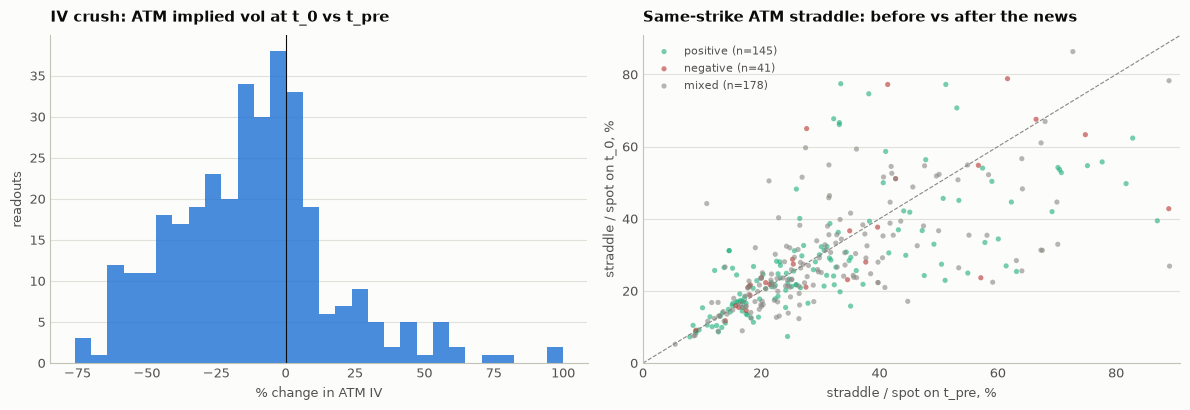

|realized| / implied move from the pre-news close. Readouts are a scheduled jump, so the honest benchmark is the full straddle (unscaled);
the square-root-of-time-scaled version flatters short horizons for a jump and is shown only for reference and for the placebo (diffusion).


n mean_ratio ci_lo ci_hi  \
group                                  horizon                               
readouts, vs the full straddle         1        243       0.83  0.72  0.95   
                                       2        243       0.82  0.72  0.93   
                                       3        243       0.85  0.74  0.97   
                                       5        243       0.88  0.77  1.00   
                                       10       243       0.95  0.84  1.09   
                                       21       243       1.11  0.97  1.26   
                                       42       243       1.39  1.21  1.58   
                                       63       243       1.49  1.29  1.71   
                                       exp      243       1.11  0.98  1.26   
readouts, sqrt-time scaled (reference) 1        243       2.64  2.28  3.05   
                                       2        243       2.16  1.88  2.47   
                                       3        243       1.94  1.68  2.21   
                                       5        243       1.66  1.45  1.89   
                                       10       243       1.33  1.17  1.52   
                                       21       243       1.10  0.97  1.25   
                                       42       243       0.98  0.86  1.12   
                                       63       243       0.86  0.75  0.99   
                                       exp      243       1.11  0.98  1.26   
placebo, sqrt-time scaled              1         68       0.80  0.62  1.00   
                                       2         68       0.71  0.55  0.88   
                                       3         68       0.63  0.49  0.78   
                                       5         68       0.67  0.53  0.82   
                                       10        68       0.62  0.51  0.74   
                                       21        68       0.60  0.49  0.72   
                                       42        68       0.65  0.53  0.79   
                                       63        68       0.75  0.62  0.90   
                                       exp       68       0.65  0.54  0.78   

                                               median_ratio share_above_1  
group                                  horizon                             
readouts, vs the full straddle         1               0.58           27%  
                                       2               0.57           26%  
                                       3               0.58           27%  
                                       5               0.64           30%  
                                       10              0.71           33%  
                                       21              0.80           37%  
                                       42              1.00           50%  
                                       63              1.05           52%  
                                       exp             0.83           38%  
readouts, sqrt-time scaled (reference) 1               1.89           71%  
                                       2               1.46           66%  
                                       3               1.31           63%  
                                       5               1.17           58%  
                                       10              1.01           51%  
                                       21              0.77           38%  
                                       42              0.70           32%  
                                       63              0.62           24%  
                                       exp             0.83           38%  
placebo, sqrt-time scaled              1               0.56           25%  
                                       2               0.47           21%  
                                       3               0.41           21%  
                                       

In [19]:
pb = panel[panel.bucket == BASELINE_BUCKET].merge(ev_is[["event_id", "sentiment", "size", "is_new"]], on="event_id")
pb["iv_crush"] = pb.iv_0 / pb.iv_pre - 1
pb["straddle_crush"] = pb.straddle_0 / pb.implied_move - 1
print(f"{BASELINE_BUCKET} ATM straddle on the pre-news session: median implied move {pb.implied_move.median():.0%} of spot "
      f"(micro {pb[pb['size'] == 'micro'].implied_move.median():.0%}, small {pb[pb['size'] == 'small'].implied_move.median():.0%}, mid+ {pb[pb['size'] == 'mid+'].implied_move.median():.0%}).")
iv_tbl = pd.DataFrame({"t_pre (pre-news)": pb.iv_pre.describe()[["25%", "50%", "75%"]], "t_0 (entry)": pb.iv_0.describe()[["25%", "50%", "75%"]],
                       "t_0 + 5": pb.iv_5.describe()[["25%", "50%", "75%"]]}).T
print("ATM implied volatility (Black-Scholes on the straddle), distribution across readouts:")
display(iv_tbl.map("{:.0%}".format))
print(f"IV crush t_pre -> t_0: median {pb.iv_crush.median():+.0%}, interquartile [{pb.iv_crush.quantile(.25):+.0%}, {pb.iv_crush.quantile(.75):+.0%}]; "
      f"IV fell in {(pb.iv_crush < 0).mean():.0%} of events. Same-strike straddle as % of spot: {pb.implied_move.median():.0%} before -> {pb.straddle_0.median():.0%} after.")

# Hedge cost before vs after, like for like: a put 10% below (call 10% above) *that day's* spot, priced by Black-Scholes at the
# measured ATM volatility and the days left to the same expiry. (The observed t_0 hedge-leg marks are reported next to it.)
pb["T_pre"] = (pb.expiry - pb.t_pre).dt.days / 365
pb["T_0"] = (pb.expiry - pb.t_0).dt.days / 365
pb["put_bs_pre"] = [bs_price(1.0, 1 - OTM_PCT, T, iv, "put") if iv > 0 else np.nan for T, iv in zip(pb.T_pre, pb.iv_pre.fillna(0))]
pb["put_bs_0"] = [bs_price(1.0, 1 - OTM_PCT, T, iv, "put") if iv > 0 else np.nan for T, iv in zip(pb.T_0, pb.iv_0.fillna(0))]
pb["call_bs_pre"] = [bs_price(1.0, 1 + OTM_PCT, T, iv, "call") if iv > 0 else np.nan for T, iv in zip(pb.T_pre, pb.iv_pre.fillna(0))]
pb["call_bs_0"] = [bs_price(1.0, 1 + OTM_PCT, T, iv, "call") if iv > 0 else np.nan for T, iv in zip(pb.T_0, pb.iv_0.fillna(0))]
cost_tbl = pd.DataFrame({
    f"put {OTM_PCT:.0%} OTM at that day's spot (Black-Scholes at the measured ATM IV)": {"on t_pre (pre-news)": pb.put_bs_pre.median(), "on t_0 (entry)": pb.put_bs_0.median()},
    f"call {OTM_PCT:.0%} OTM at that day's spot (Black-Scholes at the measured ATM IV)": {"on t_pre (pre-news)": pb.call_bs_pre.median(), "on t_0 (entry)": pb.call_bs_0.median()},
    "ATM straddle, same strike, observed": {"on t_pre (pre-news)": pb.implied_move.median(), "on t_0 (entry)": pb.straddle_0.median()},
    f"observed hedge leg on t_0 (put / call {OTM_PCT:.0%} OTM, last trade or mid)": {"on t_pre (pre-news)": np.nan, "on t_0 (entry)": pb[f"put_cost_{OTM_PCT}"].median()},
})
print("Median cost of protection before and after the readout, as % of spot, same expiry. A trader who already owns the stock pays the t_0 column;\n"
      "the t_pre column is what the same protection cost the evening before the news (with 1 more day of life).")
display(cost_tbl.map(lambda v: f"{v:.1%}" if pd.notna(v) else "").T)
_paired = pb.dropna(subset=["put_bs_pre", "put_bs_0"])
print(f"Paired: the 10%-OTM put is cheaper on t_0 than on t_pre for {(_paired.put_bs_0 < _paired.put_bs_pre).mean():.0%} of readouts (n={len(_paired)}); "
      f"median change {((_paired.put_bs_0 / _paired.put_bs_pre) - 1).median():+.0%}.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].hist(pb.iv_crush.clip(-1, 1).dropna() * 100, bins=30, color=SERIES["events"], alpha=0.85)
axes[0].axvline(0, color=INK, linewidth=0.8)
style(axes[0], "IV crush: ATM implied vol at t_0 vs t_pre", "% change in ATM IV", "readouts")
for lab, g, c in [("positive", pb[pb.sentiment >= SENT_THRESHOLD], SERIES["positive"]), ("negative", pb[pb.sentiment <= -SENT_THRESHOLD], SERIES["negative"]), ("mixed", pb[pb.sentiment.abs() < SENT_THRESHOLD], SERIES["mixed"])]:
    axes[1].scatter(g.implied_move.clip(0, 1.5) * 100, g.straddle_0.clip(0, 1.5) * 100, s=14, alpha=0.6, color=c, edgecolor="none", label=f"{lab} (n={len(g)})")
lim = [0, min(150, pb.implied_move.quantile(.98) * 100)]
axes[1].plot(lim, lim, color=MUTED, linewidth=0.8, linestyle="--")
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
style(axes[1], "Same-strike ATM straddle: before vs after the news", "straddle / spot on t_pre, %", "straddle / spot on t_0, %")
axes[1].legend(frameon=False, labelcolor=INK2, fontsize=8)
finish(fig, "iv_crush")

# Realized vs implied: the decay table (entry = pre, so the implied move is the pre-news straddle)
def decay_table(r: pd.DataFrame, scaled: bool = True) -> pd.DataFrame:
    """|realized move| / implied move. `scaled=True` shrinks the implied move with the square-root-of-time rule (right for
    ordinary diffusion, i.e. the placebo); `scaled=False` compares against the full straddle (right for a scheduled jump:
    the readout is what the pre-news straddle was pricing)."""
    r = r.copy()
    r["dte_sessions"] = [sessions_between(e, CAL[CAL.searchsorted(x, side="right") - 1]) for e, x in zip(r.entry_date, r.expiry)]
    r["ratio"] = r.realized.abs() / (r.straddle_cost * (np.sqrt(r.sessions_held / r.dte_sessions.clip(lower=1)) if scaled else 1.0))
    rows = []
    for h in [h for h in HORIZONS + ["exp"] if h in set(r.horizon)]:
        x = r.loc[r.horizon == h, "ratio"].replace([np.inf, -np.inf], np.nan).dropna()
        lo, hi = bootstrap_ci(x)
        rows.append({"horizon": h, "n": len(x), "mean_ratio": x.mean(), "ci_lo": lo, "ci_hi": hi, "median_ratio": x.median(), "share_above_1": (x > 1).mean()})
    return pd.DataFrame(rows).set_index("horizon")


def fmt_decay(tbl: pd.DataFrame) -> pd.DataFrame:
    out = tbl.copy()
    for c in ["mean_ratio", "ci_lo", "ci_hi", "median_ratio"]:
        out[c] = out[c].map(lambda v: f"{v:.2f}")
    out["share_above_1"] = out["share_above_1"].map(lambda v: f"{v:.0%}")
    return out


pre_ev = results[(results.bucket == BASELINE_BUCKET) & (results.entry == "pre") & (results.otm == OTM_PCT) & results.event_id.isin(readouts_new.event_id)]
pre_pl = placebo_results[(placebo_results.bucket == BASELINE_BUCKET) & (placebo_results.entry == "pre") & (placebo_results.otm == OTM_PCT)]
print("|realized| / implied move from the pre-news close. Readouts are a scheduled jump, so the honest benchmark is the full straddle (unscaled);\n"
      "the square-root-of-time-scaled version flatters short horizons for a jump and is shown only for reference and for the placebo (diffusion).")
display(fmt_decay(pd.concat({"readouts, vs the full straddle": decay_table(pre_ev, scaled=False), "readouts, sqrt-time scaled (reference)": decay_table(pre_ev),
                             "placebo, sqrt-time scaled": decay_table(pre_pl)}, names=["group", "horizon"])))

## 13 · Out-of-sample, and `run_study`

`run_study(start, end)` runs the **whole chain** on a fresh window: events → EDGAR text → Jev (live for any filing not in
the cache) → stock bars → chains and quotes → signal with the in-sample `BETA`, implied-move proxy and `H*` frozen → P&L →
both layers vs a placebo drawn inside the window. `report` prints the standard read-out and the in-sample → new-window
comparison with a mark for whether the sign agreed. Nothing above touched 2026; horizons that have not resolved for the
latest events are absent, not zero. The rule-variant table shows the pre-registered rule next to its neighbours
(same-sign under-reaction, follow Jev with no day-0 condition, and the exploratory continuation variant).

In-sample rule variants (signed stock return minus placebo):


,h=1,h=2,h=3,h=5,h=10,h=21,h=42,h=63,n
pre-registered: under-reacted (gap rule),-0.1%,-0.8%,-1.0%,-1.1%,-3.0%,-5.8%,-9.8%,-7.8%,94
"under-reacted, same sign as Jev",+0.2%,-0.6%,-1.0%,-0.7%,-4.6%,-9.6%,-19.6%,-15.3%,35
"follow Jev, no day-0 condition",+0.6%,-0.3%,-0.7%,+0.4%,-0.5%,-1.3%,-2.3%,-1.4%,212
over-reacted: r0 beyond expected (exploratory),+1.2%,+0.3%,-0.4%,+2.5%,+2.2%,+3.6%,+5.5%,+5.5%,87


447 tagged passages (clinical_trial_results) across all filers, 2026-01-01..2026-08-31; 370 filings
333 filings from 208 universe filers (1 dropped: no ticker on record)
  out-of-sample: EDGAR: 200/333, 0s


  out-of-sample: market cap: 300/333, 0s


  out-of-sample: stock bars: 200/416, 0s


...

horizon,h=1,h=2,h=3,h=5,h=10,h=21,h=42,h=63
strategy,,,,,,,,
Signal layer: directional stock (unhedged),+0.1% → -2.1% ✗,-0.8% → -3.4% ✓,-0.8% → -4.1% ✓,-1.2% → -3.7% ✓,-2.6% → -5.1% ✓,-5.3% → -3.4% ✓,-9.2% → +4.7% ✗,-6.3% → +3.9% ✗


in-sample → out-of-sample, trade layer:


horizon,h=1,h=2,h=3,h=5,h=10,h=21,h=42,h=63,expiry
strategy,,,,,,,,,
Directional stock + option hedge,-0.9% → -1.9% ✓,-0.3% → -2.2% ✓,-0.9% → -2.7% ✓,+0.9% → -4.9% ✗,-1.9% → -5.1% ✓,-4.1% → -3.1% ✓,-12.7% → +1.4% ✗,-8.5% → -2.5% ✓,-5.1% → -5.5% ✓
"Directional stock, unhedged",-0.2% → -2.6% ✓,-0.1% → -4.4% ✓,+0.3% → -5.5% ✗,+1.2% → -6.1% ✗,-1.6% → -7.6% ✓,-6.0% → -5.8% ✓,-11.6% → +0.7% ✗,-7.9% → -4.9% ✓,-6.1% → -7.8% ✓



Rule variants · out-of-sample · signed stock return minus placebo (signal layer):


,h=1,h=2,h=3,h=5,h=10,h=21,h=42,h=63,n
pre-registered: under-reacted (gap rule),-2.2%*,-3.7%*,-4.6%*,-4.0%,-6.2%,-4.1%,+3.3%,+5.3%,31
"under-reacted, same sign as Jev",-0.7%,-1.2%,-1.5%,+0.4%,-4.1%,-1.9%,+1.7%,-0.1%,14
"follow Jev, no day-0 condition",-1.2%,-2.1%,-2.6%,-1.8%,-4.7%,-5.8%,+2.6%,+5.5%,64
over-reacted: r0 beyond expected (exploratory),+2.8%,+1.9%,+2.2%,+3.6%,-0.3%,-5.7%,+4.8%,+6.5%,25


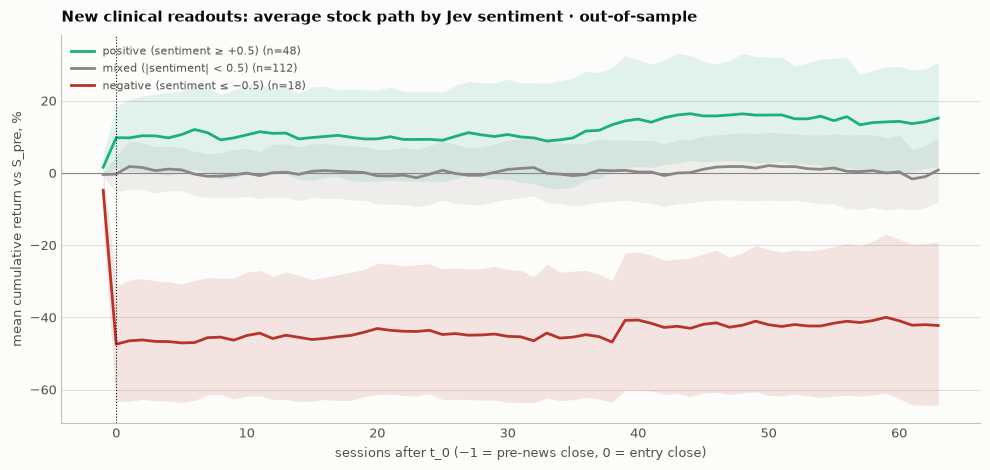


Controls out-of-sample at h=5:


,n,mean,95% CI,share of random-direction draws that beat the rule
control,,,,
Jev rule (actual),31,-3.6%,"[-8.5%, +0.9%]",
"Sign-shuffle: random direction, same events",31,+0.0%,"[-4.3%, +4.6%]",0.940
"Momentum baseline: follow sign(r0), no Jev (all directional readouts)",66,+2.6%,"[-1.6%, +6.5%]",
Momentum baseline on the same traded events,31,+4.3%,"[+0.0%, +9.1%]",
"Stale readouts (previously announced data), same rule",19,-2.3%,"[-10.6%, +4.2%]",
"Placebo: random non-event days, random direction",150,+0.4%,"[-0.9%, +1.7%]",


In [20]:
def run_study(start: str, end: str, tags: list[str] = None, label: str = None, max_events: int | None = None,
              placebo: bool = True, n_placebo: int = N_PLACEBO, seed: int = 7) -> dict:
    """The whole pipeline on a fresh window (the judges' entry point): events -> EDGAR text -> Jev labels -> stock bars ->
    option chain and quotes -> signal (with the in-sample BETA and IM proxy frozen) -> P&L -> scoreboards vs placebo.
    Jev is called live for any filing not already in jev_cache/ (TYPESAFE_API_KEY required)."""
    tags = tags or EVENT_TAGS
    label = label or f"{start}..{end}"
    ev = build_events(tags, start, end)
    if max_events:
        ev = ev.head(max_events).copy()
    if ev.empty:
        raise ValueError(f"no {tags} filings from the universe in {start}..{end}")
    ev = enrich_events(ev, label)
    load_stock_bars(ev, label)
    lab = label_events(ev, label)
    ev = align_to_press_release(ev.merge(lab.drop(columns=["ticker", "filing_date"]), on="event_id"))
    ev = ev.merge(stock_returns(ev).drop(columns=["ticker", "t_pre", "t_0"]), on="event_id")
    cand = ev[(ev.is_readout >= READOUT_GATE) & ev.has_stock & (ev.sentiment.abs() >= 0.25)]
    pr, drops = price_events(cand, label=label)
    pan = summarize_priced(pr)
    sig = build_signal(ev, pan, BETA, IM_PROXY)
    res = evaluate(pr)
    book = book_pnl(res, sig.set_index("event_id")["direction"])
    hz_ = book[(book.bucket == BASELINE_BUCKET) & (book.entry == ENTRY) & (book.otm == OTM_PCT)]
    out = {"label": label, "events": ev, "signal": sig, "funnel": funnel(sig, pan, label), "priced": pr, "panel": pan, "dropped": drops,
           "results": res, "book": book, "trade": hz_, "sig_book": stock_book(sig)}
    PRICED_BY_EVENT.update({(pe.event_id, pe.bucket): pe for pe in pr})
    if placebo and (sig.direction != 0).any():
        plc = sample_placebo(sig[sig.direction != 0], max(n_placebo, 3 * int((sig.direction != 0).sum())), start, end, seed=seed, exclude=ev)
        load_stock_bars(plc, f"{label} placebo")
        plc = plc.merge(stock_returns(plc).drop(columns=["ticker", "t_pre", "t_0"]), on="event_id")
        out["placebo_sig"], out["placebo_sig_book"] = plc, stock_book(plc)
        plc_tr = plc.head(n_placebo)
        ppr, _ = price_events(plc_tr, label=f"{label} placebo")
        pbook = book_pnl(evaluate(ppr), plc_tr.set_index("event_id")["direction"])
        out["placebo_trade"] = pbook[(pbook.bucket == BASELINE_BUCKET) & (pbook.entry == ENTRY) & (pbook.otm == OTM_PCT)]
        PRICED_BY_EVENT.update({(pe.event_id, pe.bucket): pe for pe in ppr})
    return out


def variant_table(sig: pd.DataFrame, pan: pd.DataFrame, placebo_book: pd.DataFrame | None) -> pd.DataFrame:
    """Signed stock return (signal layer) for the pre-registered rule and its neighbours, every horizon, minus placebo."""
    rows = {}
    specs = {"pre-registered: under-reacted (gap rule)": dict(mode="gap"), "under-reacted, same sign as Jev": dict(mode="same_sign"),
             "follow Jev, no day-0 condition": dict(mode="none"), "over-reacted: r0 beyond expected (exploratory)": dict(mode="over")}
    for name, kw in specs.items():
        sb = stock_book(build_signal(sig, pan, BETA, IM_PROXY, **kw))
        if sb.empty:
            continue
        if placebo_book is not None and len(placebo_book):
            d = difference_board(sb, placebo_book, ["signed"]).assign(mean=lambda x: x["difference"]).set_index("horizon")
        else:
            d = scoreboard(sb, ["signed"]).set_index("horizon")
        rows[name] = {**{f"h={h}": (f"{d.loc[h, 'mean'] * 100:+.1f}%" + ("*" if (d.loc[h, "ci_lo"] > 0 or d.loc[h, "ci_hi"] < 0) else "")) for h in HORIZONS if h in d.index},
                      "n": int(sb.event_id.nunique())}
    return pd.DataFrame(rows).T


def report(study: dict, ref: dict | None = None, ref_name: str = "in-sample"):
    """Standard read-out of a window: funnel, both layers vs placebo, the comparison with the reference window, controls, paths."""
    lab = study["label"]
    display(study["funnel"].to_frame())
    sb, tb = study["sig_book"], study["trade"]
    if sb.empty:
        print(f"{lab}: no trades passed the rule.")
        return
    ps, pt = study.get("placebo_sig_book"), study.get("placebo_trade")
    print(f"\nSIGNAL LAYER · {lab} · {sb.event_id.nunique()} trades" + (f" vs {ps.event_id.nunique()} placebo" if ps is not None else "") + ". Signed stock return per $1; * = 95% CI excludes zero.")
    boards = {"combined": scoreboard(sb, SIGNAL_STRATS), "long": scoreboard(sb[sb.book == "long"], SIGNAL_STRATS), "short": scoreboard(sb[sb.book == "short"], SIGNAL_STRATS)}
    if ps is not None:
        boards["placebo"] = scoreboard(ps, SIGNAL_STRATS)
    display(pd.concat({k: fmt_board(v, with_n=True) for k, v in boards.items()}, names=["book"]).droplevel(1))
    if ps is not None:
        print("Events minus placebo (signal layer):")
        display(fmt_board(difference_board(sb, ps, SIGNAL_STRATS), "difference"))
    if len(tb):
        print(f"\nTRADE LAYER · {lab} · {tb.event_id.nunique()} trades with a priced {BASELINE_BUCKET} hedge" + (f" vs {pt.event_id.nunique()} placebo" if pt is not None else "") + ":")
        tboards = {"combined": scoreboard(tb, BOOK_STRATS), "long": scoreboard(tb[tb.book == "long"], BOOK_STRATS), "short": scoreboard(tb[tb.book == "short"], BOOK_STRATS)}
        if pt is not None and len(pt):
            tboards["placebo"] = scoreboard(pt, BOOK_STRATS)
        display(pd.concat({k: fmt_board(v, with_n=(k == "combined")) for k, v in tboards.items()}, names=["book"]))
        if pt is not None and len(pt):
            print("Events minus placebo (trade layer):")
            display(fmt_board(difference_board(tb, pt, BOOK_STRATS), "difference"))
    if ref is not None:
        a, b = scoreboard(ref["sig_book"], SIGNAL_STRATS), scoreboard(sb, SIGNAL_STRATS)
        cmp_ = a.merge(b, on=["strategy", "horizon"], suffixes=("_ref", "_new"))
        cmp_["cell"] = [f"{x * 100:+.1f}% → {y * 100:+.1f}% {'✓' if np.sign(x) == np.sign(y) else '✗'}" for x, y in zip(cmp_.mean_ref, cmp_.mean_new)]
        print(f"\n{ref_name} → {lab}, signal layer (signed stock return, mean); ✓ = same sign:")
        display(cmp_.pivot(index="strategy", columns="horizon", values="cell").rename(index=STRATEGY_LABEL).rename(columns=lambda h: f"h={h}"))
        if len(tb) and len(ref["trade"]):
            a, b = scoreboard(ref["trade"], BOOK_STRATS), scoreboard(tb, BOOK_STRATS)
            cmp_ = a.merge(b, on=["strategy", "horizon"], suffixes=("_ref", "_new"))
            cmp_["cell"] = [f"{x * 100:+.1f}% → {y * 100:+.1f}% {'✓' if np.sign(x) == np.sign(y) else '✗'}" for x, y in zip(cmp_.mean_ref, cmp_.mean_new)]
            print(f"{ref_name} → {lab}, trade layer:")
            display(cmp_.pivot(index="strategy", columns="horizon", values="cell").rename(index=STRATEGY_LABEL).rename(columns=lambda h: f"h={h}" if h != "exp" else "expiry"))
    print(f"\nRule variants · {lab} · signed stock return minus placebo (signal layer):")
    display(variant_table(study["signal"], study["panel"], ps))
    rn = study["events"][(study["events"].is_readout >= READOUT_GATE) & (study["events"].is_new >= NEW_GATE) & study["events"].has_stock]
    plot_paths(sentiment_groups(rn), f"New clinical readouts: average stock path by Jev sentiment · {lab}", f"paths_by_sentiment_{re.sub(r'[^0-9a-zA-Z]+', '_', lab)}")


IS = {"label": "in-sample", "events": ev_is, "signal": signal_is, "funnel": funnel_is, "priced": priced, "panel": panel, "results": results,
      "book": book_is, "trade": trade_is, "sig_book": sig_book_is, "placebo_sig": placebo_sig, "placebo_sig_book": placebo_sig_book, "placebo_trade": placebo_hz}
print(f"In-sample rule variants (signed stock return minus placebo):")
display(variant_table(signal_is, panel, placebo_sig_book))

OOS = run_study(OOS_START, OOS_END, label="out-of-sample")
report(OOS, IS)
print(f"\nControls out-of-sample at h={H_STAR}:")
placebo_sig_saved = placebo_sig
placebo_sig = OOS["placebo_sig"]
display(control_table(OOS["signal"], H_STAR))
placebo_sig = placebo_sig_saved

## 14 · Parameter sensitivity

A finding that lives at one setting is not a finding, and a null that lives at one setting is not a null either. Signal
layer: sentiment threshold, the under-reaction gate (0.25 / 0.5 / 0.75 / off, same-sign only, and the exploratory
over-reaction variant), Jev confidence, the safety veto, size bucket, entry session (`t_0` close, the hypothetical
pre-news close, 30 minutes after acceptance from minute bars), borrow fee, and the combined category. Trade layer: OTM
distance, hedge expiry bucket, entry, borrow. Every cell is the edge over placebo at every fixed horizon with a CI star;
the heatmap is the summary. With a few hundred cells, a handful of stars are expected by chance, and the rows are
overlapping subsets of the same events, so the grid is read for the sign pattern, not for single stars.

  entry +30 min: 100/414, 0s


  entry +30 min: 200/414, 0s


  entry +30 min: 300/414, 0s


  entry +30 min: 400/414, 1s


994 tagged passages (regulatory_decision) across all filers, 2024-01-01..2025-12-31; 954 filings
630 filings from 290 universe filers (1 dropped: no ticker on record)
  regulatory_decision: EDGAR: 200/630, 0s


...

Combined category: 524 additional regulatory_decision filings; 36 of them read as a clinical readout by Jev (the rest are approvals, CRLs and other decisions without new trial data and fail the is_readout gate by design).


Signal layer: mean signed stock return minus placebo, per $1, by specification and horizon (* = 95% CI on the difference excludes zero).
The grid has 224 cells, so about 11 stars are expected by chance alone; read the sign pattern, not single stars. The rows are heavily overlapping subsets of the same events, not independent tests.


,n,h=1,h=2,h=3,h=5,h=10,h=21,h=42,h=63
headline: threshold 0.5 · gap rule 0.5 · post entry · all sizes,94,-0.1%,-0.8%,-1.0%,-1.1%,-3.0%,-5.8%,-9.8%,-7.8%
sentiment threshold 0.25,219,+0.4%,-0.6%,-1.1%,-0.8%,-2.3%,-5.1%,-6.3%,-4.3%
sentiment threshold 0.75,51,-0.2%,-0.4%,-1.0%,-0.8%,-4.7%,-6.9%,-10.7%,-11.4%
ALREADY_MOVED 0.25,82,-0.1%,-0.8%,-0.8%,-1.0%,-3.4%,-6.7%,-11.8%,-8.7%
ALREADY_MOVED 0.75,109,-0.1%,-1.1%,-1.4%,-1.5%,-3.5%,-6.2%,-10.0%*,-7.4%
ALREADY_MOVED off (follow Jev's sign),212,+0.6%,-0.3%,-0.7%,+0.4%,-0.5%,-1.3%,-2.3%,-1.4%
"under-reacted, same sign only",35,+0.2%,-0.6%,-1.0%,-0.7%,-4.6%,-9.6%,-19.6%,-15.3%
over-reacted (r0 beyond expected) — exploratory,87,+1.2%,+0.3%,-0.4%,+2.5%,+2.2%,+3.6%,+5.5%,+5.5%
Jev confidence > median,67,+0.7%,-0.2%,-0.7%,-0.8%,-4.1%,-7.4%,-12.7%,-10.9%
no safety veto,95,-0.1%,-0.7%,-1.0%,-1.1%,-3.0%,-5.9%,-10.0%,-7.9%


Trade layer: mean hedged P&L minus placebo:


,n,h=1,h=2,h=3,h=5,h=10,h=21,h=42,h=63
hedged · 1m · OTM 10% · post (headline),51,-1.2%,-1.2%,-0.7%,+1.6%,+1.6%,+0.5%,-10.8%,-7.1%
hedged · 1m · OTM 5%,51,+0.1%,-0.5%,+0.0%,+1.9%,+1.2%,+2.0%,-9.6%,-5.1%
hedged · 1m · OTM 20%,51,-2.0%,-2.0%,-1.6%,+2.4%,-3.5%,-2.1%,-14.3%,-11.0%
hedged · 2m · OTM 10%,47,+1.2%,+0.6%,-0.6%,+1.6%,-1.2%,-0.4%,-1.0%,+2.5%
hedged · 3-6m · OTM 10%,60,-0.8%,-0.8%,-0.6%,+1.0%,-3.5%,+2.0%,+0.1%,+0.0%
hedged · 1m · entry pre (hypothetical),51,-13.8%*,-13.9%*,-13.3%*,-10.5%*,-12.2%*,-14.4%*,-24.0%*,-24.7%*
hedged · 1m · borrow 5%,51,-1.2%,-1.3%,-0.7%,+1.6%,+1.4%,+0.2%,-11.4%,-7.9%
hedged · 1m · borrow 75%,51,-1.1%,-1.2%,-0.6%,+1.8%,+2.0%,+1.2%,-9.4%,-5.1%


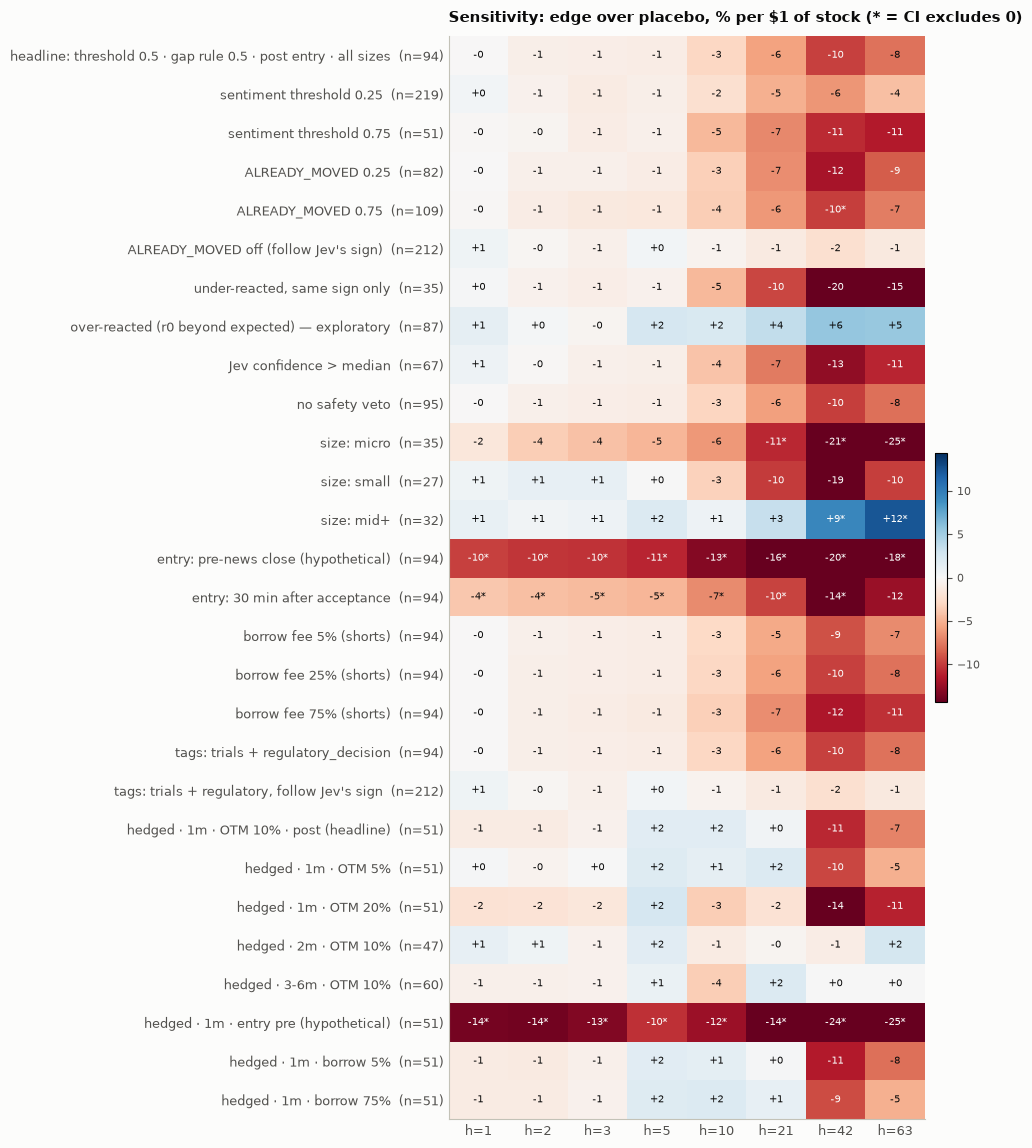

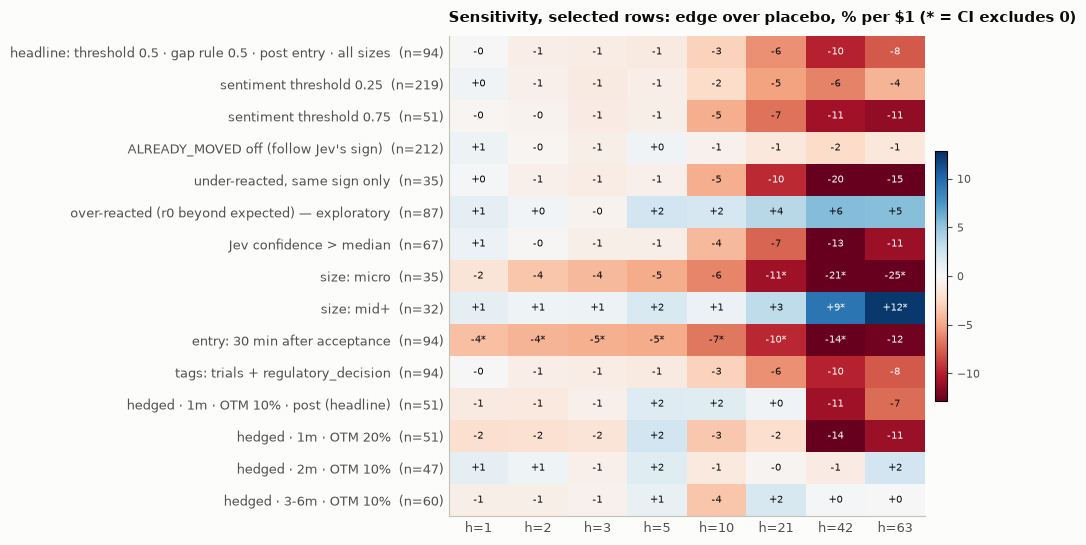

In [21]:
# ---- Extra ingredients for the grid: the combined-category event set and the "entry 30 minutes after acceptance" price ----
def entry_30min(row) -> float:
    """Adjusted stock price 30 minutes after the 8-K was accepted (10:00 ET for pre-market acceptances; next session 10:00 for after-close)."""
    if pd.isna(row.accepted_at):
        return np.nan
    acc = row.accepted_at
    if acc.hour >= 16:
        day, t = session_after(acc.normalize()), pd.Timestamp("10:00").time()
    elif acc.hour < 9 or (acc.hour == 9 and acc.minute < 30):
        day, t = session_on_or_after(acc.normalize()), pd.Timestamp("10:00").time()
    else:
        day, t = session_on_or_after(acc.normalize()), (acc + pd.Timedelta(minutes=30)).time()
    bars = minute_bars(row.ticker, day)
    if bars.empty:
        return np.nan
    px = bars["close"].loc[:pd.Timestamp.combine(day, t)]
    return float(px.iloc[-1]) if len(px) else np.nan


dir_is = signal_is[signal_is.gate_readout & signal_is.gate_new & signal_is.gate_stock & (signal_is.sentiment.abs() >= 0.25)].copy()
dir_is["S_30"] = parallel_map(entry_30min, list(dir_is.itertuples(index=False)), label="entry +30 min", every=100)
S30 = dir_is.set_index("event_id")["S_30"]

if "regulatory_decision" in SENSITIVITY_TAGS:
    reg_events = enrich_events(build_events(["regulatory_decision"], STUDY_START, STUDY_END), "regulatory_decision")
    reg_events = reg_events[~reg_events.event_id.isin(ev_is.event_id)]
    load_stock_bars(reg_events, "regulatory_decision")
    reg_lab = label_events(reg_events, "regulatory_decision")
    reg_ev = align_to_press_release(reg_events.merge(reg_lab.drop(columns=["ticker", "filing_date"]), on="event_id"))
    reg_ev = reg_ev.merge(stock_returns(reg_ev).drop(columns=["ticker", "t_pre", "t_0"]), on="event_id")
    combined_ev = pd.concat([ev_is, reg_ev], ignore_index=True)
    print(f"Combined category: {len(reg_ev)} additional regulatory_decision filings; {(reg_ev.is_readout >= READOUT_GATE).sum()} of them read as a clinical readout by Jev "
          f"(the rest are approvals, CRLs and other decisions without new trial data and fail the is_readout gate by design).")


def grid_row(sig: pd.DataFrame, placebo_book: pd.DataFrame, entry: str = "post", borrow: float = BORROW_FEE) -> dict:
    """Signed stock return minus placebo at every horizon for one signal-layer specification."""
    d = sig[sig.direction != 0].copy()
    if entry == "pre":                                     # hypothetical: enter at the pre-news close
        for h in HORIZONS:
            d[f"r_{h}"] = (1 + d.r0) * (1 + d[f"r_{h}"]) - 1
    elif entry == "+30min":
        s30 = d.event_id.map(S30)
        for h in HORIZONS:
            d[f"r_{h}"] = (1 + d[f"r_{h}"]) * d.S_0_adj / s30 - 1
    sb = stock_book(d, borrow_fee=borrow)
    out = {"n": int(sb.event_id.nunique()) if len(sb) else 0}
    if len(sb) < 5:
        return out
    diff = difference_board(sb, placebo_book, ["signed"]).set_index("horizon")
    for h in HORIZONS:
        if h in diff.index and pd.notna(diff.loc[h, "difference"]):
            out[h] = diff.loc[h, "difference"]
            out[f"star_{h}"] = bool(diff.loc[h, "ci_lo"] > 0 or diff.loc[h, "ci_hi"] < 0)
    return out


rows = {}
base = dict(beta=BETA, im_proxy=IM_PROXY)
rows["headline: threshold 0.5 · gap rule 0.5 · post entry · all sizes"] = grid_row(signal_is, placebo_sig_book)
for th in (0.25, 0.75):
    rows[f"sentiment threshold {th}"] = grid_row(build_signal(ev_is, panel, sent_threshold=th, **base), placebo_sig_book)
for am in (0.25, 0.75):
    rows[f"ALREADY_MOVED {am}"] = grid_row(build_signal(ev_is, panel, already_moved=am, **base), placebo_sig_book)
rows["ALREADY_MOVED off (follow Jev's sign)"] = grid_row(build_signal(ev_is, panel, mode="none", **base), placebo_sig_book)
rows["under-reacted, same sign only"] = grid_row(build_signal(ev_is, panel, mode="same_sign", **base), placebo_sig_book)
rows["over-reacted (r0 beyond expected) — exploratory"] = grid_row(build_signal(ev_is, panel, mode="over", **base), placebo_sig_book)
rows["Jev confidence > median"] = grid_row(build_signal(ev_is, panel, conf_gate=float(ev_is.outcome_conf.median()), **base), placebo_sig_book)
rows["no safety veto"] = grid_row(build_signal(ev_is, panel, safety_veto=1.01, **base), placebo_sig_book)
for sz in ("micro", "small", "mid+"):
    rows[f"size: {sz}"] = grid_row(signal_is[signal_is["size"] == sz], placebo_sig_book)
rows["entry: pre-news close (hypothetical)"] = grid_row(signal_is, placebo_sig_book, entry="pre")
rows["entry: 30 min after acceptance"] = grid_row(signal_is, placebo_sig_book, entry="+30min")
for bf in BORROW_GRID:
    rows[f"borrow fee {bf:.0%} (shorts)"] = grid_row(signal_is, placebo_sig_book, borrow=bf)
if "regulatory_decision" in SENSITIVITY_TAGS:
    rows["tags: trials + regulatory_decision"] = grid_row(build_signal(combined_ev, panel, **base), placebo_sig_book)
    rows["tags: trials + regulatory, follow Jev's sign"] = grid_row(build_signal(combined_ev, panel, mode="none", **base), placebo_sig_book)

# trade layer: hedge bucket, OTM, entry, borrow
def trade_grid_row(bucket: str, otm: float, entry: str, borrow: float = BORROW_FEE) -> dict:
    ev_rows = book_pnl(results[(results.bucket == bucket) & (results.entry == entry) & (results.otm == otm)], signal_is.set_index("event_id")["direction"], borrow)
    pl_rows = book_pnl(placebo_results[(placebo_results.bucket == bucket) & (placebo_results.entry == entry) & (placebo_results.otm == otm)],
                       placebo_tr.set_index("event_id")["direction"], borrow)
    out = {"n": int(ev_rows.event_id.nunique())}
    if len(ev_rows) < 5 or len(pl_rows) < 5:
        return out
    diff = difference_board(ev_rows, pl_rows, ["hedged"]).set_index("horizon")
    for h in HORIZONS:
        if h in diff.index and pd.notna(diff.loc[h, "difference"]):
            out[h] = diff.loc[h, "difference"]
            out[f"star_{h}"] = bool(diff.loc[h, "ci_lo"] > 0 or diff.loc[h, "ci_hi"] < 0)
    return out


trows = {f"hedged · {BASELINE_BUCKET} · OTM {OTM_PCT:.0%} · post (headline)": trade_grid_row(BASELINE_BUCKET, OTM_PCT, "post")}
for o in OTM_GRID:
    if o != OTM_PCT:
        trows[f"hedged · {BASELINE_BUCKET} · OTM {o:.0%}"] = trade_grid_row(BASELINE_BUCKET, o, "post")
for b in EXPIRY_BUCKETS:
    if b != BASELINE_BUCKET:
        trows[f"hedged · {b} · OTM {OTM_PCT:.0%}"] = trade_grid_row(b, OTM_PCT, "post")
trows[f"hedged · {BASELINE_BUCKET} · entry pre (hypothetical)"] = trade_grid_row(BASELINE_BUCKET, OTM_PCT, "pre")
for bf in BORROW_GRID:
    if bf != BORROW_FEE:
        trows[f"hedged · {BASELINE_BUCKET} · borrow {bf:.0%}"] = trade_grid_row(BASELINE_BUCKET, OTM_PCT, "post", bf)


def grid_frame(rows: dict) -> pd.DataFrame:
    g = pd.DataFrame(rows).T
    cells = pd.DataFrame(index=g.index)
    cells["n"] = g["n"].astype(int)
    for h in HORIZONS:
        if h in g:
            cells[f"h={h}"] = [f"{v * 100:+.1f}%{'*' if s else ''}" if pd.notna(v) else "" for v, s in zip(g[h], g.get(f"star_{h}", pd.Series(False, index=g.index)).fillna(False))]
    return cells, g


grid_cells, grid_vals = grid_frame(rows)
tgrid_cells, tgrid_vals = grid_frame(trows)
print(f"Signal layer: mean signed stock return minus placebo, per $1, by specification and horizon (* = 95% CI on the difference excludes zero).\n"
      f"The grid has {8 * (len(rows) + len(trows))} cells, so about {0.05 * 8 * (len(rows) + len(trows)):.0f} stars are expected by chance alone; "
      "read the sign pattern, not single stars. The rows are heavily overlapping subsets of the same events, not independent tests.")
display(grid_cells)
print("Trade layer: mean hedged P&L minus placebo:")
display(tgrid_cells)

# heatmap (full grid, and a compact one with the rows the write-up discusses)
def sens_heatmap(allv: pd.DataFrame, title: str, name: str, row_h: float = 0.36):
    M = allv[[h for h in HORIZONS if h in allv]].astype(float)
    fig, ax = plt.subplots(figsize=(10, row_h * len(M) + 1.5))
    vmax = np.nanpercentile(np.abs(M.to_numpy()), 95)
    im = ax.imshow(M.to_numpy() * 100, cmap="RdBu", vmin=-vmax * 100, vmax=vmax * 100, aspect="auto")
    ax.set_xticks(range(M.shape[1]), [f"h={h}" for h in M.columns])
    ax.set_yticks(range(len(M)), [f"{i}  (n={int(n)})" for i, n in zip(M.index, allv["n"])], fontsize=8)
    for i in range(len(M)):
        for j, h in enumerate(M.columns):
            v, s = M.iloc[i, j], allv.iloc[i].get(f"star_{h}", False)
            if pd.notna(v):
                ax.text(j, i, f"{v * 100:+.0f}{'*' if s else ''}", ha="center", va="center", fontsize=7, color=INK if abs(v) < vmax * 0.6 else SURFACE)
    style(ax, title)
    ax.grid(False)
    ax.tick_params(length=0)
    cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cb.ax.tick_params(labelsize=8, colors=INK2)
    finish(fig, name)


allv = pd.concat([grid_vals, tgrid_vals])
sens_heatmap(allv, "Sensitivity: edge over placebo, % per $1 of stock (* = CI excludes 0)", "sensitivity_heatmap")
_compact = [r for r in ["headline: threshold 0.5 · gap rule 0.5 · post entry · all sizes", "sentiment threshold 0.25", "sentiment threshold 0.75",
                        "ALREADY_MOVED off (follow Jev's sign)", "under-reacted, same sign only", "over-reacted (r0 beyond expected) — exploratory",
                        "Jev confidence > median", "size: micro", "size: mid+", "entry: 30 min after acceptance", "tags: trials + regulatory_decision",
                        f"hedged · {BASELINE_BUCKET} · OTM {OTM_PCT:.0%} · post (headline)", f"hedged · {BASELINE_BUCKET} · OTM 20%", f"hedged · 2m · OTM {OTM_PCT:.0%}",
                        f"hedged · 3-6m · OTM {OTM_PCT:.0%}"] if r in allv.index]
sens_heatmap(allv.loc[_compact], "Sensitivity, selected rows: edge over placebo, % per $1 (* = CI excludes 0)", "sensitivity_heatmap_compact", row_h=0.27)

## 15 · Specifying the trade: costs, liquidity, capacity

A **cost waterfall** from the real quotes: gross hedged P&L at `H*` and at 21 sessions, minus the hedge leg's half-spread
at entry (the closing quote on `t_0`) and at exit (the exit-day quote, or the entry's relative spread; zero if the option
settled at expiry), minus a 10 bp stock half-spread each way, with the borrow grid for the short side. **Liquidity
tiers**: the pre-registered strict gate, a relaxed gate and the plain "optionable" set, with the edge in each. A
**selection check** compares the signal-layer returns of events that reached the trade layer with those that did not.
**Capacity** at 10% of day-0 volume in the hedge leg and the stock. The trade specification a desk would need closes the section.

In [22]:
def cost_waterfall(trades: pd.DataFrame, h: int, stock_half_spread_bp: float = 10.0) -> pd.DataFrame:
    """Gross -> net at horizon h for the hedged book: option half-spreads from the real quotes (entry at the ask or bid side,
    exit at the other), a stock half-spread assumption, and the borrow grid for the short side."""
    t = trades[trades.horizon == h].copy()
    rows = []
    for r in t.itertuples(index=False):
        pe = PRICED_BY_EVENT.get((r.event_id, BASELINE_BUCKET))
        if pe is None:
            continue
        key = f"P_L{OTM_PCT}" if r.direction > 0 else f"C_U{OTM_PCT}"
        q_e, q_x = pe.quote(key, pe.t_0), pe.quote(key, r.exit_date)
        half_e = (q_e["spread"] / 2 if q_e and pd.notna(q_e["spread"]) else np.nan) / r.S_entry
        if q_x and pd.notna(q_x["spread"]):
            half_x = q_x["spread"] / 2 / r.S_entry
        elif q_e and pd.notna(q_e["rel_spread"]):
            half_x = q_e["rel_spread"] / 2 * max(pe.mark(key, r.exit_date), 0) / r.S_entry
        else:
            half_x = np.nan
        if r.exit_date >= pe.expiry_session:
            half_x = 0.0                                  # settled at expiry: no exit spread
        rows.append({"event_id": r.event_id, "book": r.book, "gross": r.hedged, "opt_half_spread_entry": half_e, "opt_half_spread_exit": half_x,
                     "stock_spread": 2 * stock_half_spread_bp / 1e4, "borrow_days": r.days_held if r.direction < 0 else 0})
    w = pd.DataFrame(rows)
    out = {"trades": len(w), "gross mean hedged P&L": w.gross.mean(),
           "− option half-spread at entry (real quote)": -w.opt_half_spread_entry.mean(), "− option half-spread at exit (quote, or entry rel. spread)": -w.opt_half_spread_exit.mean(),
           f"− stock spread ({stock_half_spread_bp:.0f} bp each way)": -w.stock_spread.mean()}
    net = w.gross - w.opt_half_spread_entry.fillna(w.opt_half_spread_entry.median()) - w.opt_half_spread_exit.fillna(0) - w.stock_spread
    out["= net mean P&L (headline borrow already charged)"] = net.mean()
    for bf in BORROW_GRID:
        extra = (bf - BORROW_FEE) * w.borrow_days / 365
        out[f"net with borrow {bf:.0%} (shorts only)"] = (net - extra).mean()
    out["break-even round-trip cost per trade"] = w.gross.mean() if w.gross.mean() > 0 else 0.0
    out["share of trades net positive"] = (net > 0).mean()
    out["median quoted relative spread of the hedge leg at entry"] = float(np.nanmedian([(PRICED_BY_EVENT[(e, BASELINE_BUCKET)].quote(f"P_L{OTM_PCT}" if b == "long" else f"C_U{OTM_PCT}", PRICED_BY_EVENT[(e, BASELINE_BUCKET)].t_0) or {"rel_spread": np.nan})["rel_spread"] for e, b in zip(w.event_id, w.book)]))
    return pd.Series(out).to_frame(f"h={h}")


wf = pd.concat([cost_waterfall(trade_is, H_STAR), cost_waterfall(trade_is, 21)], axis=1)
fmt = wf.copy()
for c in fmt.columns:
    fmt[c] = [f"{v:.0f}" if k == "trades" else (f"{v:.0%}" if "share" in k or "spread of" in k else f"{v * 100:+.2f}%") for k, v in wf[c].items()]
print(f"Cost waterfall, hedged book, {BASELINE_BUCKET} hedge, OTM {OTM_PCT:.0%} (per $1 of stock):")
display(fmt)

# ---- Liquidity tiers: how many trades survive each gate, and does the edge depend on it? ---------------------------
pb_ = panel[panel.bucket == BASELINE_BUCKET].set_index("event_id")
tiers = []
for name, fn in [("optionable: hedge leg quoted (ask > 0) on t_0", lambda p, side: True),
                 ("relaxed: spread ≤ 50% of mid or ≤ $0.25; any hedge volume on t_0; stock $ vol ≥ $1M",
                  lambda p, side: ((p.get(f"{'put' if side == 'long' else 'call'}_rel_spread_{OTM_PCT}", np.nan) <= 0.5) or (p.get(f"{'put' if side == 'long' else 'call'}_abs_spread_{OTM_PCT}", np.nan) <= 0.25))
                  and p.get(f"{'put' if side == 'long' else 'call'}_volume_{OTM_PCT}", 0) >= 1 and p.get("stock_dollar_volume_0", 0) >= MIN_STOCK_DOLLAR_VOL),
                 (f"strict (pre-registered): spread ≤ {MAX_REL_SPREAD:.0%} or ≤ ${MAX_ABS_SPREAD:.2f}; hedge volume ≥ {MIN_HEDGE_VOLUME}; stock $ vol ≥ ${MIN_STOCK_DOLLAR_VOL / 1e6:.0f}M", liquid)]:
    keep = [e for e, b in zip(trade_is.event_id.unique(), trade_is.drop_duplicates("event_id").book) if e in pb_.index and fn(pb_.loc[e], b)]
    sub = trade_is[trade_is.event_id.isin(keep) & (trade_is.horizon == H_STAR)]
    tiers.append({"tier": name, "trades": len(keep), f"mean hedged P&L h={H_STAR}": sub.hedged.mean(), "CI": bootstrap_ci(sub.hedged), "mean unhedged": sub.unhedged.mean()})
tiers = pd.DataFrame(tiers).set_index("tier")
tiers[f"mean hedged P&L h={H_STAR}"] = tiers[f"mean hedged P&L h={H_STAR}"].map(lambda v: f"{v * 100:+.1f}%")
tiers["mean unhedged"] = tiers["mean unhedged"].map(lambda v: f"{v * 100:+.1f}%")
tiers["CI"] = tiers["CI"].map(lambda c: f"[{c[0] * 100:+.1f}%, {c[1] * 100:+.1f}%]" if pd.notna(c[0]) else "n < 5")
display(tiers)

# ---- Is the trade layer a biased subset of the signal layer? ---------------------------------------------------------
in_trade = signal_is.event_id.isin(trade_is.event_id)
cmp_rows = []
for lab, g in [("traded events with a priced hedge", sig_book_is[sig_book_is.event_id.isin(trade_is.event_id)]), ("traded events without one", sig_book_is[~sig_book_is.event_id.isin(trade_is.event_id)])]:
    r_ = {"n": g.event_id.nunique()}
    for h in (5, 21, 63):
        x = g.loc[g.horizon == h, "signed"]
        r_[f"signed stock h={h}"] = f"{x.mean() * 100:+.1f}%"
    cmp_rows.append(pd.Series(r_, name=lab))
print("Selection check: signal-layer returns of the events that made it into the trade layer vs those that did not:")
display(pd.DataFrame(cmp_rows))

# ---- Capacity --------------------------------------------------------------------------------------------------------
cap_rows = []
for r in trade_is.drop_duplicates("event_id").itertuples(index=False):
    if r.event_id not in pb_.index:
        continue
    p = pb_.loc[r.event_id]
    leg_vol = p.get(f"{'put' if r.book == 'long' else 'call'}_volume_{OTM_PCT}", 0)
    cap_rows.append({"event_id": r.event_id, "year": r.t_0.year, "hedge_leg_capacity_$": 0.10 * leg_vol * 100 * p.S_0,
                     "stock_capacity_$": 0.10 * p.stock_dollar_volume_0})
cap = pd.DataFrame(cap_rows)
cap["per_trade_$"] = cap[["hedge_leg_capacity_$", "stock_capacity_$"]].min(axis=1)
cap_med, hedge_binds = cap["per_trade_$"].median(), (cap["hedge_leg_capacity_$"] < cap["stock_capacity_$"]).mean()
print(f"Capacity at 10% of t_0 volume: median per trade ${cap_med:,.0f} (hedge leg binds in {hedge_binds:.0%} of trades; "
      f"median hedge-leg capacity ${cap['hedge_leg_capacity_$'].median():,.0f}, median stock capacity ${cap['stock_capacity_$'].median():,.0f}). "
      f"Deployable per year: " + ", ".join(f"{y}: ${v / 1e6:.1f}M" for y, v in cap.groupby("year")["per_trade_$"].sum().items()))

spec = pd.Series({
    "Events": f"8-K tagged {' + '.join(EVENT_TAGS)} from a SIC 2834/2836 filer; Jev: P(new human readout) ≥ {READOUT_GATE} and P(first disclosure) ≥ {NEW_GATE}; |sentiment| ≥ {SENT_THRESHOLD}",
    "Direction": f"long if sentiment ≥ +{SENT_THRESHOLD} and P(safety signal) < {SAFETY_VETO}; short if sentiment ≤ −{SENT_THRESHOLD}; only when r0 is short of {ALREADY_MOVED} × expected (expected = {BETA:.2f} × sentiment × implied move)",
    "Entry": "close of t_0 = first session at whose close the 8-K was on EDGAR (acceptance before 16:00 ET: same day; after: next session)",
    "Instruments": f"long book: 100 shares + 1 put {OTM_PCT:.0%} OTM, {BASELINE_BUCKET} expiry; short book: short 100 shares + 1 call {OTM_PCT:.0%} OTM, {BASELINE_BUCKET} expiry (library strategies 3 and 1)",
    "Exit": f"time stop H* = {H_STAR} sessions (in-sample peak of the hedged edge; frozen); earlier if the gap closes or the filer files another 8-K; the option is the stop-loss",
    "Max loss per trade (median, by strike)": f"{trade_is[trade_is.horizon == H_STAR].max_loss.median():.0%} of the stock notional",
    "Costs": f"hedge leg: cross the quoted spread each way (median relative spread {wf.loc['median quoted relative spread of the hedge leg at entry'].iloc[0]:.0%}); stock 10 bp each way; borrow {BORROW_FEE:.0%} p.a. on shorts",
    "Capacity": f"≈ ${cap_med:,.0f} per trade at 10% of day-0 volume; the hedge leg, not the stock, binds",
    "Short-side risks": "hard-to-borrow and recall after bad news; squeezes (the long call is the hedge for exactly this); trading halts; reverse splits (flagged, dropped from the trade layer)",
})
with pd.option_context("display.max_colwidth", 200):
    display(spec.to_frame("trade specification"))

Cost waterfall, hedged book, 1m hedge, OTM 10% (per $1 of stock):


,h=5,h=21
trades,51,51
gross mean hedged P&L,+0.92%,-4.10%
− option half-spread at entry (real quote),-2.07%,-2.07%
"− option half-spread at exit (quote, or entry rel. spread)",-2.20%,-0.59%
− stock spread (10 bp each way),-0.20%,-0.20%
= net mean P&L (headline borrow already charged),-3.22%,-6.96%
net with borrow 5% (shorts only),-3.14%,-6.68%
net with borrow 25% (shorts only),-3.22%,-6.96%
net with borrow 75% (shorts only),-3.40%,-7.66%
break-even round-trip cost per trade,+0.92%,+0.00%


,trades,mean hedged P&L h=5,CI,mean unhedged
tier,,,,
optionable: hedge leg quoted (ask > 0) on t_0,51,+0.9%,"[-2.6%, +4.8%]",+1.2%
relaxed: spread ≤ 50% of mid or ≤ $0.25; any hedge volume on t_0; stock $ vol ≥ $1M,19,+3.0%,"[-2.2%, +8.4%]",+4.8%
strict (pre-registered): spread ≤ 25% or ≤ $0.10; hedge volume ≥ 10; stock $ vol ≥ $1M,9,+4.5%,"[-3.3%, +12.7%]",+9.8%


Selection check: signal-layer returns of the events that made it into the trade layer vs those that did not:


,n,signed stock h=5,signed stock h=21,signed stock h=63
traded events with a priced hedge,51,+1.2%,-6.0%,-7.9%
traded events without one,43,-4.1%,-4.5%,-4.5%


Capacity at 10% of t_0 volume: median per trade $548 (hedge leg binds in 100% of trades; median hedge-leg capacity $548, median stock capacity $7,980,178). Deployable per year: 2024: $1.7M, 2025: $1.9M


,trade specification
Events,8-K tagged clinical_trial_results from a SIC 2834/2836 filer; Jev: P(new human readout) ≥ 0.7 and P(first disclosure) ≥ 0.6; |sentiment| ≥ 0.5
Direction,long if sentiment ≥ +0.5 and P(safety signal) < 0.5; short if sentiment ≤ −0.5; only when r0 is short of 0.5 × expected (expected = 0.78 × sentiment × implied move)
Entry,close of t_0 = first session at whose close the 8-K was on EDGAR (acceptance before 16:00 ET: same day; after: next session)
Instruments,"long book: 100 shares + 1 put 10% OTM, 1m expiry; short book: short 100 shares + 1 call 10% OTM, 1m expiry (library strategies 3 and 1)"
Exit,time stop H* = 5 sessions (in-sample peak of the hedged edge; frozen); earlier if the gap closes or the filer files another 8-K; the option is the stop-loss
"Max loss per trade (median, by strike)",18% of the stock notional
Costs,hedge leg: cross the quoted spread each way (median relative spread 53%); stock 10 bp each way; borrow 25% p.a. on shorts
Capacity,"≈ $548 per trade at 10% of day-0 volume; the hedge leg, not the stock, binds"
Short-side risks,"hard-to-borrow and recall after bad news; squeezes (the long call is the hedge for exactly this); trading halts; reverse splits (flagged, dropped from the trade layer)"


## 16 · Sealed window · judges only

Set `RUN_HOLDOUT = True`, `HOLDOUT_START`, `HOLDOUT_END` and `TYPESAFE_API_KEY` in section 2 and run all cells. This cell
runs `run_study` on your window and prints the same read-out as section 13 next to the in-sample result, plus the
controls and the hedged-vs-unhedged tail table. Our prediction for the window is printed by the cell when it is not run,
so it is on record before the window is seen.

In [23]:
if RUN_HOLDOUT:
    HOLDOUT = run_study(HOLDOUT_START, HOLDOUT_END, label=f"sealed {HOLDOUT_START}..{HOLDOUT_END}")
    report(HOLDOUT, IS)
    print(f"\nControls on the sealed window at h={H_STAR}:")
    placebo_sig_saved = placebo_sig
    placebo_sig = HOLDOUT["placebo_sig"]
    display(control_table(HOLDOUT["signal"], H_STAR))
    placebo_sig = placebo_sig_saved
    if len(HOLDOUT["trade"]):
        print(f"\nHedged vs unhedged on the sealed window at h={H_STAR}:")
        display(tail_table(HOLDOUT["trade"], H_STAR))
else:
    print(f"Sealed window {HOLDOUT_START}..{HOLDOUT_END} not run. Judges: set RUN_HOLDOUT = True (and TYPESAFE_API_KEY in .env) in section 2, then run all cells.\n"
          "Prediction, written before the sealed window: the pre-registered rule should again show no edge over placebo at any horizon "
          "(a null, as in-sample and out-of-sample); the day-0 sentiment-return correlation should replicate (Spearman ≈ 0.3–0.5); "
          "the IV crush and the cheaper post-event hedge should replicate; the exploratory continuation variant is the one cell we are unsure about.")

Sealed window 2023-06-01..2023-08-31 not run. Judges: set RUN_HOLDOUT = True (and TYPESAFE_API_KEY in .env) in section 2, then run all cells.
Prediction, written before the sealed window: the pre-registered rule should again show no edge over placebo at any horizon (a null, as in-sample and out-of-sample); the day-0 sentiment-return correlation should replicate (Spearman ≈ 0.3–0.5); the IV crush and the cheaper post-event hedge should replicate; the exploratory continuation variant is the one cell we are unsure about.


## Appendix · Limitations to keep in mind

- **Option marks.** Closing NBBO mids where fetched (entry and headline exits), last trades otherwise, intrinsic at expiry.
  Mids of wide quotes flatter an illiquid leg; section 15 charges the spread. Deep-in-the-money legs are the most stale.
- **Thin chains.** Most micro-caps have no listed options, or a chain without a usable ATM pair; they are in the signal
  layer only. The trade layer is small by nature, and that is the first thing that would break the strategy at scale.
- **Borrow.** No borrow data: a 5/25/75% grid. Hard-to-borrow after bad news is the norm, not the exception.
- **Jev.** A single model version is pinned; the mask removes names and codes but not the drug's generic name, trial
  acronym or indication, which a model could in principle remember. The ablation in 6b bounds how much the mask matters.
- **Static filer list.** The universe is by CIK and includes dead companies, but the SIC assignment is as of the file's
  build; a company that changed industry code is in or out for the whole window.
- **No earnings flag; other same-day news.** A readout 8-K often arrives with a financing or a conference presentation;
  the information exit catches the next filing, not same-day co-events.
- **Dividends, early assignment**: none modelled (small-cap biotechs pay none; American exercise is ignored).
- **Coverage.** Filings & Disclosures begins January 2022 and is experimental; the taxonomy is versioned.